In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def clean():
    import gc
    import torch
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

import os
import torch
import models #type: ignore
import blosc2
import shutil
import pickle
import importlib
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import torch.nn as nn
from copy import deepcopy
from scipy.stats import mode
from scipy.stats import zscore
from astropy.stats import rayleightest
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from IPython.display import clear_output
from sklearn.preprocessing import minmax_scale # default to rescale to (0, 1)
from IntegratedGradient import IntegratedGradient
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import find_peaks, hilbert, butter, filtfilt, convolve
# units = pd.read_csv('/content/units.csv')
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', None)

In [ ]:
# spiketimes = pickle.load(open('/content/drive/MyDrive/spike_times_1119946360.pkl', 'rb'))
rf = np.load("/content/drive/MyDrive/RF_1119946360.npz") # receptive fields
df = pd.read_csv("/content/drive/MyDrive/units_info.csv",index_col=0) # units info
sp = pd.read_csv("/content/drive/MyDrive/sp_1119946360.csv") # stimulus presentation
units = pd.read_csv('/content/drive/MyDrive/units_1119946360.csv') # units dataframe
channels = pd.read_csv("/content/drive/MyDrive/channels_1119946360.csv") # channels
timestamps_src = "/content/drive/MyDrive/timestamps_1119946360.npy"
timestamps_dst = "/content/timestamps_1119946360.npy"
shutil.copy(timestamps_src, timestamps_dst)
timestamps = np.load(timestamps_dst)

attrs_raw_src = "/content/drive/MyDrive/attrs_scores_1119946360_channel5_band0_stack1.b2"
attrs_raw_dst = "/content/attrs_raw.b2"
shutil.copy(attrs_raw_src, attrs_raw_dst)
attrs = blosc2.load_tensor(attrs_raw_dst) # attrs scores, not normalized by firing rate

# attrs_normalized_src = "/content/drive/MyDrive/attrs_normalized_by_fr_1119946360.b2"
# attrs_normalized_dst = "/content/attrs_normalized_by_fr_1119946360.b2"
# shutil.copy(attrs_normalized_src, attrs_normalized_dst)
# attrs_normalized = blosc2.load_tensor(attrs_normalized_dst)

source_path = "/content/drive/MyDrive/lfp_1119946360.b2"
target_path = "/content/lfp.b2"
shutil.copy(source_path, target_path)
lfp = blosc2.load_tensor(target_path)

source_path = "/content/drive/MyDrive/spike_1119946360_raw.b2"
target_path = "/content/spk.b2"
shutil.copy(source_path, target_path)
spikes = blosc2.load_tensor(target_path) # raw spikes, not min maxed
fr = spikes[:attrs.shape[0],:]

In [ ]:
from scipy.sparse import coo_matrix, save_npz, load_npz
attrs_src = r"/content/drive/MyDrive/attribution_scores_transformer_chan5_band0.npz"
attrs_dst = "/content/attrs.npz"
shutil.copy(attrs_src, attrs_dst)
attrs = load_npz(attrs_dst).toarray()
attrs_normalized = attrs/(fr+1e-12) # normalize by firing rate

correlation: 0.9997697822894188


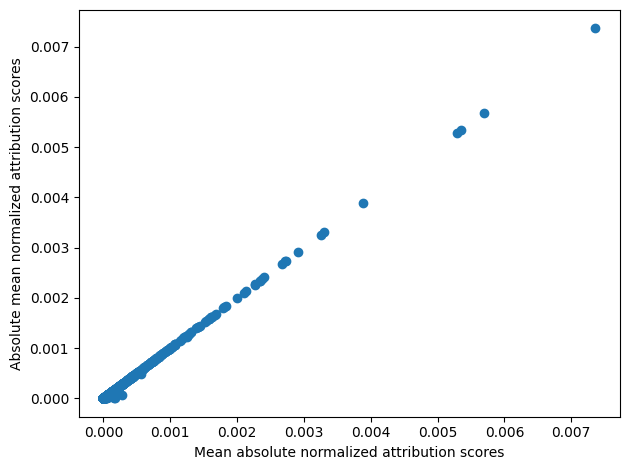

In [ ]:
# Just a quick check
mean_abs_attrs_normalized = torch.mean(torch.abs(attrs_normalized),axis=0)
abs_mean_attrs_normalized = torch.abs(torch.mean(attrs_normalized,axis=0))
plt.scatter(mean_abs_attrs_normalized, abs_mean_attrs_normalized)
print(f"correlation: {np.corrcoef(mean_abs_attrs_normalized, abs_mean_attrs_normalized)[0,1]}")
plt.xlabel("Mean absolute normalized attribution scores")
plt.ylabel("Absolute mean normalized attribution scores")
plt.tight_layout()
plt.show();
# This is expected because polarity don't change must from LSTM models 

### [SKIP] Analysis of unit attributes

#### Handpick units and plot attrs vs fr

In [ ]:
seqlength = 750
chani = 5
bandi = 0
batch_size = 32
device = 'cuda'
hidden_size = 50
num_layers = 1
num_epochs = 15
criterion = nn.MSELoss()
dur=720 # calculating firing rate based on the first 720s because attrs are calculated only using the first 720s
bin_size = 0.004
n_bins = int(dur/bin_size)
input_size = spikes.shape[1]

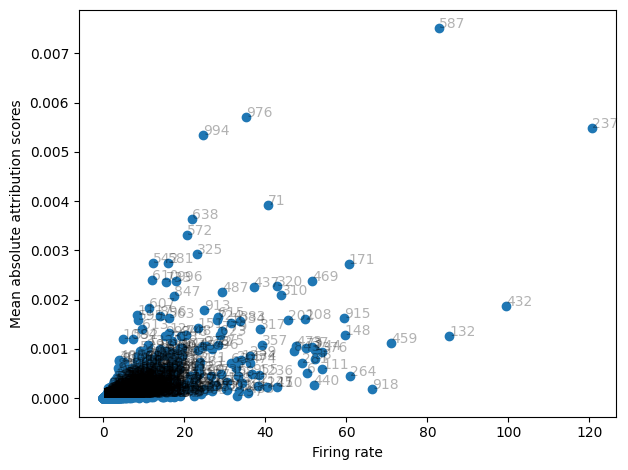

In [ ]:
attrs_mean_abs = np.array(torch.mean(torch.abs(attrs),axis=0))
plt.scatter(fr, attrs_mean_abs)
for i in range(len(fr)):
    plt.text(fr[i], attrs_mean_abs[i], i, alpha=0.3)
plt.xlabel("Firing rate")
plt.ylabel("Mean absolute attribution scores");
plt.tight_layout()
plt.show();

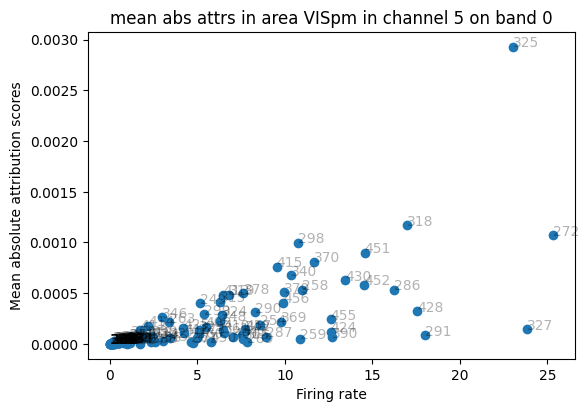

In [ ]:
from matplotlib.colors import LinearSegmentedColormap,Normalize
# input the units dataframe and an area name 
# to get the index of the units in that area
def get_area_from_units(units, area):
    area_idx = units['structure_acronym'] == area
    return area_idx

# Plot the units based on mean abs attr scores and label with unit index
fig = plt.figure(figsize=(6,4))
area = 'VISpm'
mask = get_area_from_units(units, area)
units_specific = units[mask]
plt.scatter(fr[mask], attrs_mean_abs[mask])
for i in range(len(fr)):
    if mask[i]:
        plt.text(fr[i], attrs_mean_abs[i], i, alpha=0.3)
plt.xlabel("Firing rate")
plt.ylabel("Mean absolute attribution scores");
plt.tight_layout()
plt.title(f"mean abs attrs in area {area} in channel {chani} on band {bandi}")
plt.show();

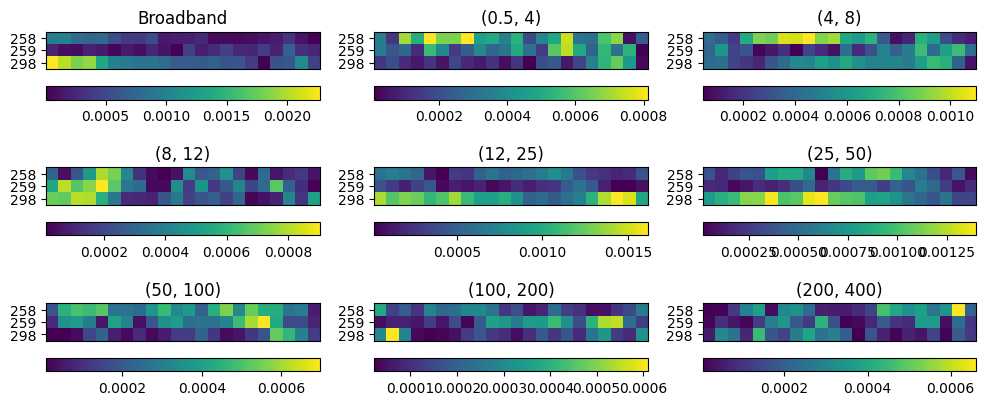

In [ ]:
# picked units 258, 259, 298
target_unit_idx = [258, 259, 298]

# load mean attribution scores for this session
src_dir = f"/content/drive/MyDrive/mean_attribution_1119946360.b2"
dst_dir = "/content/mean_attrs.b2"
shutil.copy(src_dir, dst_dir)
mean_attribution = blosc2.load_tensor(dst_dir)

# see how the mean attrs change for the target units across channels and bands
unit_attr_values = np.zeros((22,9,len(target_unit_idx)))
for channel_idx in range(22):
    for band_idx in range(9):
        attrs = mean_attribution[channel_idx, band_idx, :]
        unit_attr_values[channel_idx, band_idx] = attrs[target_unit_idx]
unit_attr_values_flat = unit_attr_values.reshape(unit_attr_values.shape[0]*unit_attr_values.shape[1], unit_attr_values.shape[2])

# Plot the mean attrs for the target units across channels and bands
min=0
max=np.max(unit_attr_values)
bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
fig, axs = plt.subplots(3,3,figsize=(12,5))
for i in range(9):
    rol = int(i/3)
    col = i%3
    c=axs[rol,col].imshow(unit_attr_values[:,i].T)
    axs[rol,col].set_yticks(np.arange(len(target_unit_idx)), target_unit_idx)
    axs[rol,col].get_xaxis().set_visible(False)
    # axs[rol,col].set_xlabel("Channel idx")
    fig.colorbar(c, ax=axs[rol,col], location='bottom', orientation='horizontal')
    if i == 0:
        axs[rol, col].set_title('Broadband')
    else:
        axs[rol, col].set_title(str(bands[i-1]))

In [ ]:
# For a given array, arr, slice out len(snippet_len) long snippets starting at indices in starts
def average_snippets(arr, starts, snippet_len):
    offsets = np.arange(snippet_len)
    indices = starts[:, np.newaxis] + offsets # create a 2D mask to get interested timepoints
    all_snippets_data = arr[indices]
    average_snippet = torch.mean(torch.abs(all_snippets_data), axis=0)
    std_snippet = torch.std(torch.abs(all_snippets_data), axis=0)
    return average_snippet, std_snippet

# Compare average attrs for the target units across stimulus presentations
def compare_avg_attrs(attrs, unit_idx, sp, timestamps):
    sp_active = sp[sp.stimulus_block == 0] # only active stimuli
    sp_active_start = sp_active.start_time.values[:900] # only taking the first 900 active stimuli
    sp_active_start_idx = np.searchsorted(timestamps,sp_active_start)-25 # -100ms prior to stimulus onset

    rtn = [] # averaged attrs snippets for each units
    rtn_std = [] # std of averaged attrs snippets
    for i in range(len(unit_idx)):
        attr = attrs[:, unit_idx[i]]
        attr_snippets_avg, attr_snippets_std = average_snippets(attr, sp_active_start_idx, 400)
        rtn.append(attr_snippets_avg)
        rtn_std.append(attr_snippets_std)
    return rtn, rtn_std

AUC for 258: 17.211111068725586
AUC for 259: 17.489999771118164
AUC for 298: 17.350000381469727


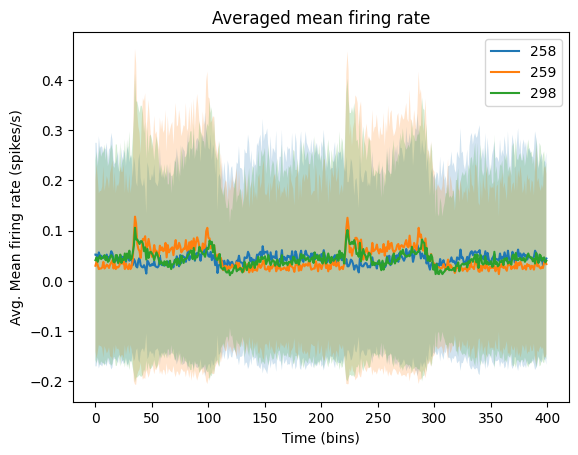

In [ ]:
idx1 = 258
idx2 = 259
idx3 = 298
arrs, stds = compare_avg_attrs(spikes[:180000,:], [idx1, idx2, idx3], sp, timestamps)

plt.plot(arrs[0])
plt.plot(arrs[1])
plt.plot(arrs[2])

plt.fill_between(np.arange(len(arrs[0])), arrs[0]-stds[0], arrs[0]+stds[0], alpha=0.2)
plt.fill_between(np.arange(len(arrs[1])), arrs[1]-stds[1], arrs[1]+stds[1], alpha=0.2)
plt.fill_between(np.arange(len(arrs[2])), arrs[2]-stds[2], arrs[2]+stds[2], alpha=0.2)

plt.legend([f"{idx1}", f"{idx2}", f"{idx3}"])
print(f"AUC for {idx1}: {torch.sum(arrs[0])}")
print(f"AUC for {idx2}: {torch.sum(arrs[1])}")
print(f"AUC for {idx3}: {torch.sum(arrs[2])}")

plt.xlabel("Time (bins)")
plt.ylabel("Avg. Mean firing rate (spikes/s)")
plt.title("Averaged mean firing rate");

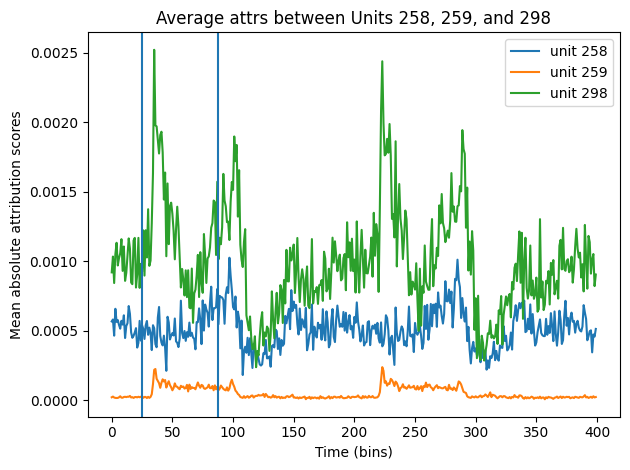

In [ ]:
arrs, stds = compare_avg_attrs(attrs, [idx1, idx2, idx3], sp, timestamps)
plt.plot(arrs[0])
plt.plot(arrs[1])
plt.plot(arrs[2])

plt.legend([f"unit {idx1}",f"unit {idx2}", f"unit {idx3}"])
plt.axvline(25)
plt.axvline(87.5)
plt.title(f"Average attrs between Units {idx1}, {idx2}, and {idx3}")
plt.xlabel("Time (bins)")
plt.ylabel("Mean absolute attribution scores")
plt.tight_layout()
plt.show();

In [ ]:
idx = np.zeros(1363, dtype=bool)
idx[idx1] = True
idx[idx2] = True
idx[idx3] = True
units[idx]

,id,PT_ratio,amplitude,amplitude_cutoff,cluster_id,cumulative_drift,d_prime,firing_rate,isi_violations,isolation_distance,l_ratio,local_index,max_drift,nn_hit_rate,nn_miss_rate,peak_channel_id,presence_ratio,quality,recovery_slope,repolarization_slope,silhouette_score,snr,spread,velocity_above,velocity_below,waveform_duration,anterior_posterior_ccf_coordinate,dorsal_ventral_ccf_coordinate,filtering,left_right_ccf_coordinate,probe_channel_number,probe_horizontal_position,probe_id,probe_vertical_position,structure_acronym
258,1126284123,0.459668,428.919757,0.001006,327,125.54,8.739784,11.050446,0.000973,159.780357,1.298546e-10,311,23.21,0.998945,0.000103,1126278044,0.99,good,-0.216360,1.202953,0.350337,6.505503,60.0,0.686767,0.480737,0.576884,8258.0,889.0,AP band: 500 Hz high-pass; LFP band: 1000 Hz l...,7589.0,250,59,1120165514,2520,VISpm
259,1126284101,0.530570,134.106278,0.067138,317,119.72,3.936866,12.446919,0.023015,87.996817,1.590515e-03,301,13.03,0.946009,0.006128,1126278044,0.99,good,-0.034262,0.243487,0.149259,1.626742,80.0,1.030151,0.294329,0.563149,8258.0,889.0,AP band: 500 Hz high-pass; LFP band: 1000 Hz l...,7589.0,250,59,1120165514,2520,VISpm
298,1126284423,0.623699,118.695915,0.080542,467,118.18,4.360920,16.167677,0.020915,89.580286,4.856264e-04,451,12.19,0.984000,0.002441,1126278049,0.99,good,-0.116834,0.522553,0.046989,2.276999,70.0,1.030151,0.206030,0.302178,8259.0,869.0,AP band: 500 Hz high-pass; LFP band: 1000 Hz l...,7589.0,252,43,1120165514,2540,VISpm


In [ ]:
features = ['PT_ratio', 'amplitude', 'amplitude_cutoff', 'cumulative_drift', 'd_prime',
                'isi_violations', 'isolation_distance', 'l_ratio', 'local_index', 'max_drift',
                'nn_hit_rate', 'nn_miss_rate', 'presence_ratio', 'recovery_slope',
                'repolarization_slope', 'silhouette_score','snr', 'spread', 'velocity_above',
                'velocity_below','waveform_duration', 'anterior_posterior_ccf_coordinate',
                'dorsal_ventral_ccf_coordinate','left_right_ccf_coordinate', 'probe_horizontal_position',
                'probe_vertical_position']

In [ ]:
# Group the units by their cluster IDs and compare the mean attrs for each cluster
# This is an old implementation, the newer version is in plots.py
def plot_mean_attr_clusters(mean_attr_clusters, channels, bands):
    fig, ax = plt.subplots(int(np.ceil((len(bands)+1)/2)),2,figsize=(10,20))
    num_channels = len(channels)
    for bandi in range(len(bands)+1):
        ax.flat[bandi].imshow( np.abs(mean_attr_clusters[:,bandi,:]) , aspect='auto',cmap='bwr')
        # set the xticks to be the channel depths
        ax.flat[bandi].set_xticks(range(num_channels))
        ax.flat[bandi].set_xticklabels(channels['dorsal_ventral_ccf_coordinate'].astype(int) , rotation=45, ha='right')
        ax.flat[bandi].set_xlabel('dorsal ventral ccf coordinate')
        ax.flat[bandi].set_ylim([.5,5.5])
        if bandi == 0:
            ax.flat[bandi].set_title('Broadband')
        else:
            ax.flat[bandi].set_title(str(bands[bandi-1]) + ' Hz')
        # set the yticks to be the cluster ids
        ax.flat[bandi].set_yticks(range(1,6,1))
        ax.flat[bandi].set_yticklabels(range(1,6,1))
        ax.flat[bandi].set_ylabel('Cluster ID')
        cbar = fig.colorbar(ax.flat[bandi].imshow(np.abs(mean_attr_clusters[:,bandi,:]), aspect='auto', cmap='bwr'), ax=ax.flat[bandi])

    # tight layout
    plt.tight_layout()
    fig.delaxes(ax.flat[-1])
    plt.show()

# Not used anymore, but kept for reference
# This function tries to find units that are similar in firing rate but really different in attr scores
def get_unit_diff(df, attr, fr, features):
    compared = np.zeros((len(attr),len(attr)),dtype=bool)
    results = np.zeros((len(attr),len(attr),len(features)))
    attr_diff = np.zeros((len(attr),len(attr)))
    attr_avg = np.median(attr)
    for idx, i in enumerate(fr):
        neighbor_left = np.where(fr >= i*0.95)[0]
        neighbor_right = np.where(fr <= i*1.05)[0]
        neighbors = np.intersect1d(neighbor_left, neighbor_right)
        for j in neighbors:
            if compared[idx,j]: continue
            compared[idx,j] = True
            compared[j,idx] = True
            if ((attr[idx] < attr_avg) and (attr[j] < attr_avg)): # both too small
                continue
            if np.abs((attr[idx]-attr[j])/attr[idx]) < 5: # difference is too small, pass
                continue
            for kdx, k in enumerate(features):
                results[idx,j,kdx] = df.iloc[idx][k]-df.iloc[j][k]
            attr_diff[idx,j] = np.abs((attr[idx]-attr[j]))
    return results,attr_diff

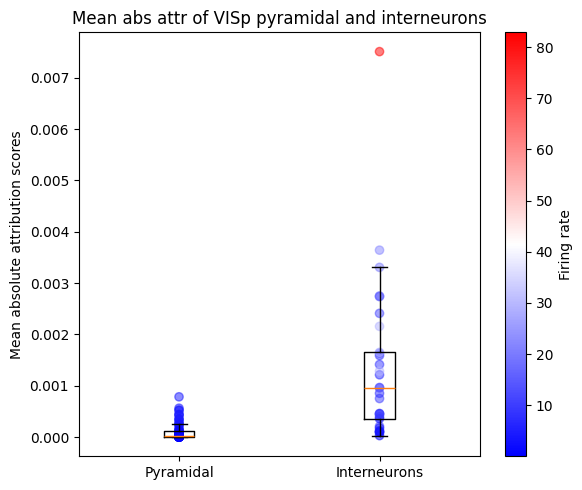

In [ ]:
# For units in VISp, group the units by cell type and compare attr scores and firing rates
results, attr_diff = get_unit_diff(units, attrs_mean_abs, fr, features)
area = 'VISp'
mask = units.structure_acronym == area
units_specific = units[mask]
df_units_specific = df[np.isin(df.unit_id.values, units_specific.id.values)]

# separate pyramidal cells and interneurons
pyr = df_units_specific[df_units_specific.pyr == 1].unit_id.values
intn = df_units_specific[df_units_specific.pyr != 1].unit_id.values
pyr_idx = np.isin(units.id.values, pyr)
intn_idx = np.isin(units.id.values, intn)
fr_pyr = fr[pyr_idx]
fr_intn = fr[intn_idx]
fr_combined = np.concatenate((fr_pyr, fr_intn))

colors = ["blue", "white", "red"]
cmap = LinearSegmentedColormap.from_list("mycmap", colors)
norm = Normalize(vmin=np.min(fr_combined), vmax=np.max(fr_combined))
colors_mapped = cmap(norm(fr_combined))
fig,ax=plt.subplots(1,1,figsize=(6,5))
ax.boxplot([attrs_mean_abs[pyr_idx], attrs_mean_abs[intn_idx]],showfliers=False);
ax.scatter(np.ones_like(attrs_mean_abs[pyr_idx]), attrs_mean_abs[pyr_idx], alpha=0.5, c=colors_mapped[:len(fr_pyr)])
ax.scatter(np.ones_like(attrs_mean_abs[intn_idx])+1, attrs_mean_abs[intn_idx], alpha=0.5, c=colors_mapped[len(fr_pyr):])
ax.set_title(f"Mean abs attr of {area} pyramidal and interneurons")
ax.set_ylabel("Mean absolute attribution scores")
ax.set_xticks([1,2],["Pyramidal", "Interneurons"])

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for older versions of matplotlib
plt.colorbar(sm, ax=ax, label='Firing rate')

plt.tight_layout()
plt.show();

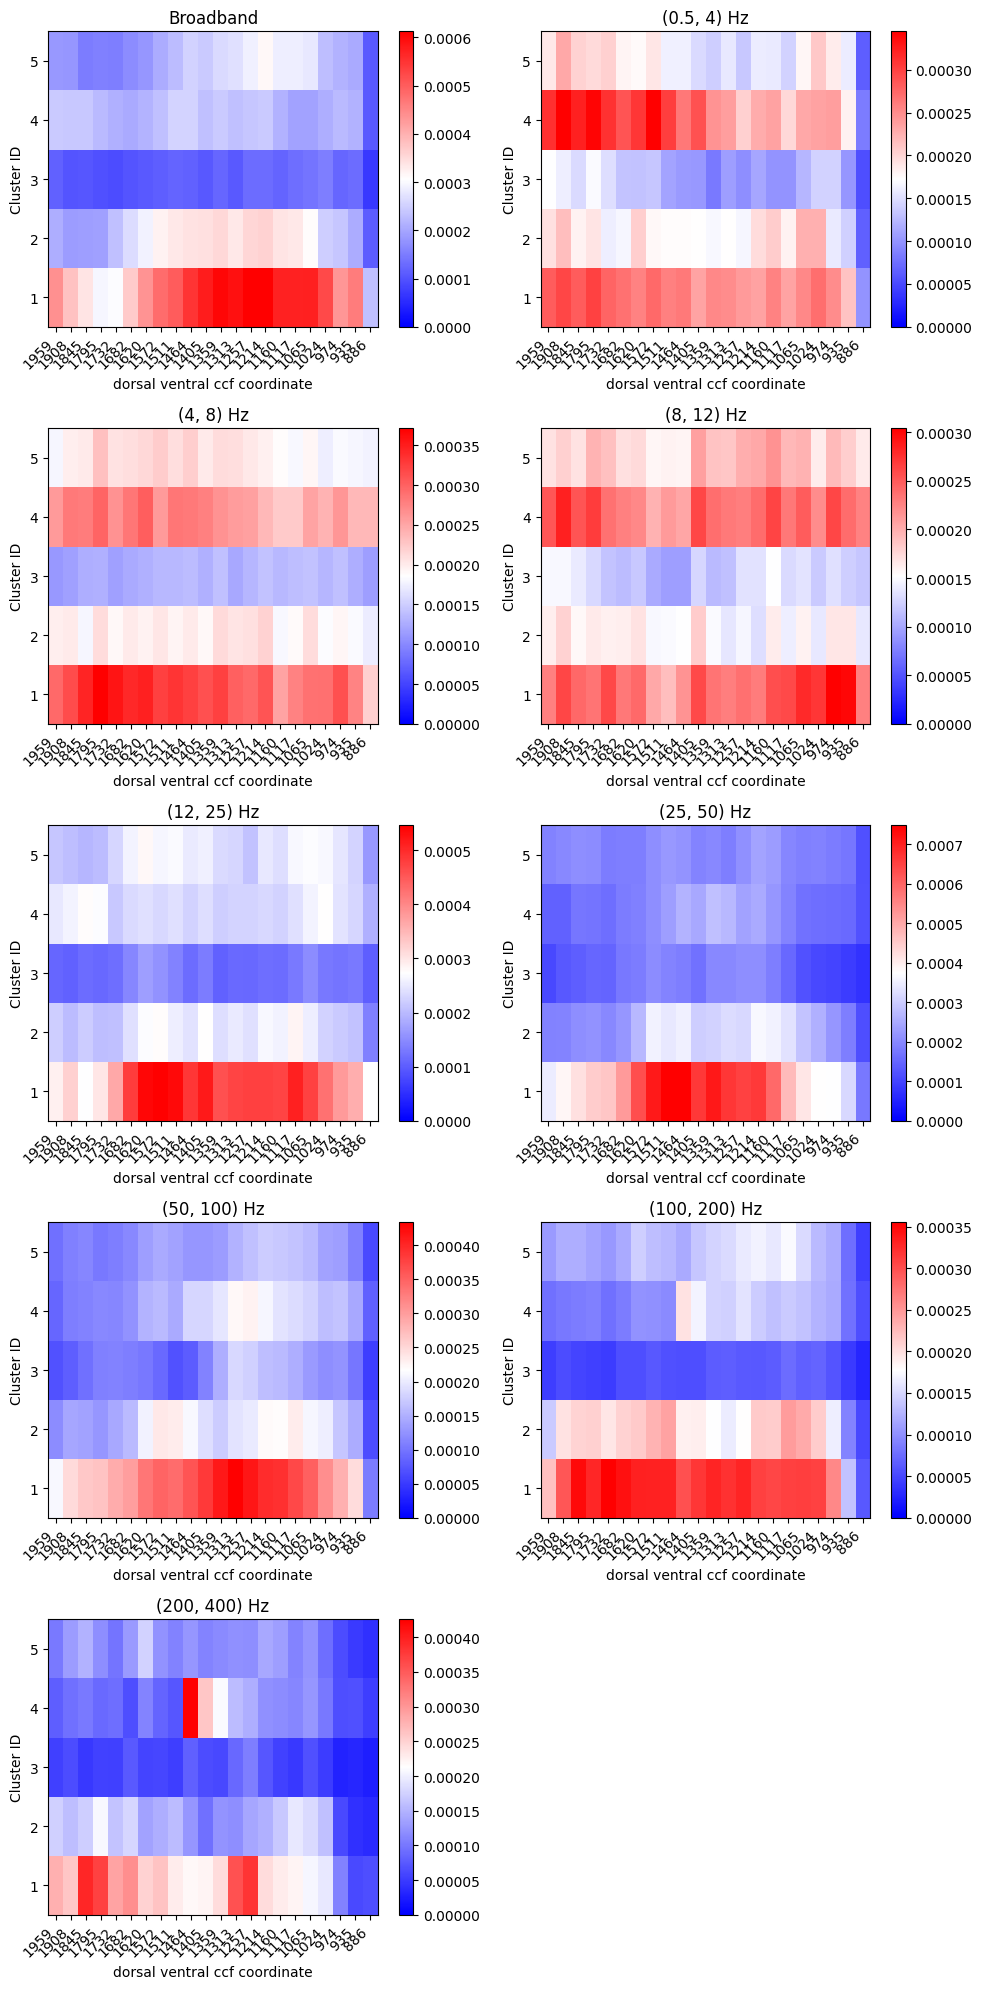

In [ ]:
# for each cluster, calculate the mean attribution across all channels and bands
len_bands = 8
num_channels = len(channels)
cluster_id = {1:[], 2:[], 3:[], 4:[], 5:[]}
df_filtered = df[np.isin(df.unit_id.values, units.id.values)]
mean_attr_clusters = np.zeros((len(df['cluster_id'].unique()), len_bands+1, num_channels))
# get unit ids for each cluster
for i in range(1,6):
    cluster_id[i] = list(df_filtered.unit_id[df_filtered['cluster_id'] == i])

for clusteri in range(1,6):
    for bandi in range(len_bands+1):
        for chani in range(num_channels):
            ind = units.id.isin(cluster_id[clusteri])
            if np.sum(ind) == 0: print(f"chluster {clusteri}, band {bandi}, chani {chani} zero counts")
            mean_attr_clusters[clusteri, bandi, chani] = np.mean(mean_attribution[chani, bandi, ind])
            
plot_mean_attr_clusters(mean_attr_clusters, channels, bands)

#### Receptive Field

In [ ]:
from scipy.ndimage import gaussian_filter
from skimage.measure import label, regionprops

def calculate_rf_size(psth_rf_receptive_field, num_fields=None, locs_length=None):
    """
    Calculates the receptive field (RF) size for neurons.

    Args:
        psth_rf_receptive_field (numpy.ndarray): A 3D numpy array representing
            the receptive field data for multiple neurons.
            Dimensions are expected to be (num_neurons, height, width).
        num_fields (numpy.ndarray or list): A 1D array or list where each
            element indicates a property for the corresponding neuron.
            NaN values indicate neurons to be skipped.
        locs_length (int): The number of locations or neurons to process.
                           This corresponds to the length of `num_fields`.

    Returns:
        numpy.ndarray: A 1D array containing the calculated receptive field size
                       for each neuron, multiplied by 100. Neurons that were
                       skipped will have their initial rfSize value (likely 0).
    """
    if num_fields is None: num_fields = np.ones(len(psth_rf_receptive_field))
    if locs_length is None: locs_length = len(psth_rf_receptive_field)
    rf_size = np.zeros(locs_length)
    for i in range(locs_length):
        if not np.isnan(num_fields[i]):
            tmp = np.squeeze(psth_rf_receptive_field[i, :, :])
            # tmp_filtered = gaussian_filter(tmp, sigma=0.5)
            tmp_filtered = tmp
            # tmp_filtered = (tmp_filtered - np.mean(tmp_filtered))/np.std(tmp_filtered)
            # bin_fr = tmp_filtered > 2
            threshold = np.max(tmp_filtered) - np.std(tmp_filtered)
            bin_fr = tmp_filtered > threshold
            bin_fr_int = bin_fr.astype(int)
            labeled_fr = label(bin_fr_int)
            stats_fr = regionprops(labeled_fr)
            if stats_fr:
                max_area = 0
                largest_blob = None
                for region in stats_fr:
                    if region.area > max_area:
                        max_area = region.area
                        largest_blob = region
                if largest_blob is not None:
                    # rfSize is the number of pixels in the largest blob
                    rf_size[i] = largest_blob.area
            else:
                rf_size[i] = 0
    rf_size = rf_size * 100
    return rf_size

rf_sizes = calculate_rf_size(rf['receptiveField'])

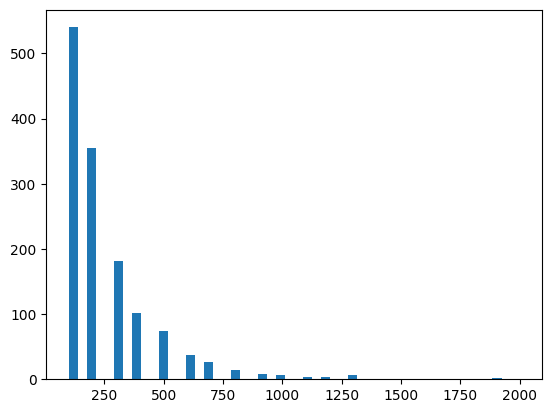

In [ ]:
plt.hist(rf_sizes, bins=50);

In [ ]:
fig, axs = plt.subplots(1,3,figsize=(15,5))

idx = 259
rfi = rf_sizes[idx]
axs[0].imshow(rfi)
# rfi_filtered = gaussian_filter(rfi, sigma=0.5)
rfi_filtered = rfi
axs[1].imshow(rfi_filtered)

threshold = np.max(rfi_filtered) - np.std(rfi_filtered)
bin_fr = rfi_filtered > threshold

# rfi_filtered_zscored = (rfi_filtered - np.mean(rfi_filtered))/np.std(rfi_filtered)
# bin_fr = rfi_filtered_zscored > 2

axs[2].imshow(bin_fr)

bin_fr_int = bin_fr.astype(int)
labeled_fr = label(bin_fr_int)
stats_fr = regionprops(labeled_fr)
if stats_fr:
    max_area = 0
    largest_blob = None
    for region in stats_fr:
        if region.area > max_area:
            max_area = region.area
            largest_blob = region
    if largest_blob is not None:
        # rfSize is the number of pixels in the largest blob
        print(largest_blob.area)
else:
    print(0)

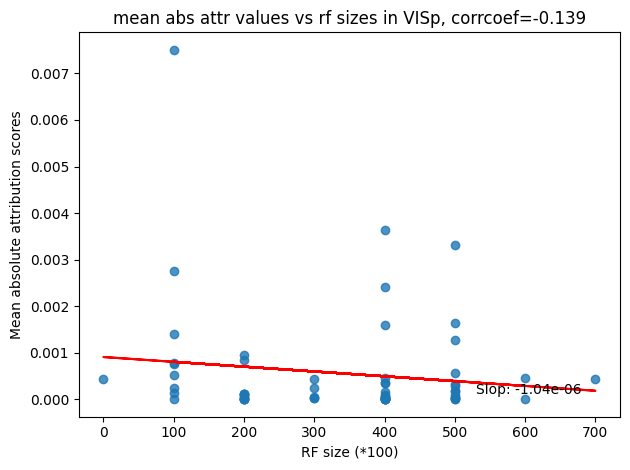

In [ ]:
# plot mean attrs vs rf sizes for VISp units
mask=units.structure_acronym == 'VISp'
non_zero_mask = rf_sizes > 100
plt.scatter(rf_sizes[mask & non_zero_mask], attrs_mean_abs[mask & non_zero_mask], alpha=0.8)
m, b = np.polyfit(rf_sizes[mask & non_zero_mask], attrs_mean_abs[mask & non_zero_mask], 1)
plt.plot(rf_sizes[mask & non_zero_mask], m * rf_sizes[mask & non_zero_mask] + b, c='r')
plt.xlabel("RF size (*100)")
plt.ylabel("Mean absolute attribution scores");
cc = np.corrcoef(rf_sizes[mask & non_zero_mask], attrs_mean_abs[mask & non_zero_mask])[0,1]
plt.title(f"mean abs attr values vs rf sizes in VISp, corrcoef={cc:.3f}")

# line fit
x_min = np.min(rf_sizes[mask & non_zero_mask])
x_max = np.max(rf_sizes[mask & non_zero_mask])
x = np.linspace(x_min, x_max, 100)[75]
y = m*x+b
plt.text(x,y,f'Slop: {m:.2e}', ha='left', va='top')
plt.tight_layout()
plt.show();

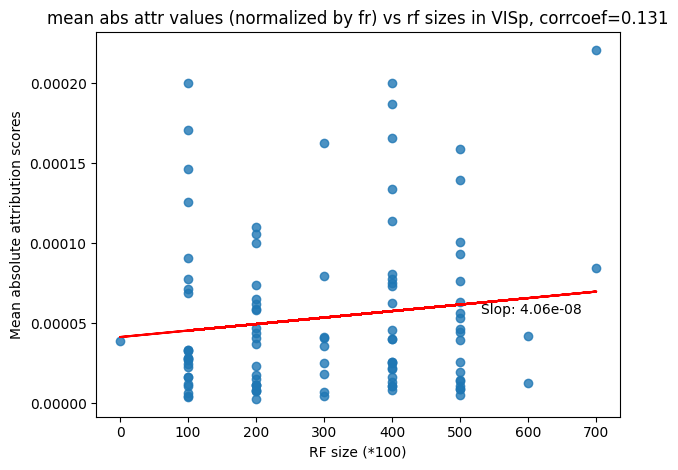

In [ ]:
# same as the previous plot, but attrs are now normalized by firing rate
plt.scatter(rf_sizes[mask], (attrs_mean_abs[mask]/(fr[mask]+1e-8)), alpha=0.8)
m, b = np.polyfit(rf_sizes[mask], attrs_mean_abs[mask]/(fr[mask]+1e-8), 1)
plt.plot(rf_sizes[mask], m * rf_sizes[mask] + b, c='r')
plt.xlabel("RF size (*100)")
plt.ylabel("Mean absolute attribution scores");
cc = np.corrcoef(rf_sizes[mask], (attrs_mean_abs[mask]/(fr[mask]+1e-8)))[0,1]
plt.title(f"mean abs attr values (normalized by fr) vs rf sizes in VISp, corrcoef={cc:.3f}")
x_min = np.min(rf_sizes[mask])
x_max = np.max(rf_sizes[mask])
x = np.linspace(x_min, x_max, 100)[75]
y = m*x+b
plt.text(x,y,f'Slop: {m:.2e}', ha='left', va='top')
plt.tight_layout()
plt.show();

#### Visual induced FR

In [ ]:
"""
Plan:
baseline: 248ms gray screen proceeding onset
induced FR: 248ms after the onset (250 not divisible so 248 is used)
"""

# get the idx of stim onsets
sp = pd.read_csv("/content/drive/MyDrive/sp_active_1119946360.csv")
sp_starts = sp.start_time.values
sp_starts = sp_starts[sp_starts < 3600]
sp_starts_idx = np.searchsorted(timestamps,sp_starts)
baseline_fr = torch.zeros((len(sp_starts), spikes.shape[-1]))
induced_fr = torch.zeros((len(sp_starts), spikes.shape[-1]))
induced_percent = torch.zeros((len(sp_starts), spikes.shape[-1]))
for i in tqdm(range(len(sp_starts))):
    start_idx = sp_starts_idx[i]
    if start_idx < 250:
        print(f"{i} skipped")
        continue
    if start_idx > spikes.shape[0]-62:
        print(f"{i} skipped")
        continue
    baseline_fr[i,:] = torch.mean(spikes[start_idx-62:start_idx,:],axis=0) / (0.004*62)
    induced_fr[i,:] = torch.mean(spikes[start_idx:start_idx+62,:],axis=0) / (0.004*62)
baseline_fr_mean = np.array(torch.mean(baseline_fr,axis=0))
induced_fr_mean = np.array(torch.mean(induced_fr,axis=0))
induced_percent = induced_fr_mean / (baseline_fr_mean + 1e-12)

100%|██████████| 4763/4763 [00:01<00:00, 3946.22it/s]


### [SKIP TO HERE] Examine features in bulk

In [ ]:
# code used to calculate visual induced firing rate
"""
# get the idx of stim onsets
sp = pd.read_csv("/content/drive/MyDrive/sp_active_1119946360.csv")
sp_starts = sp.start_time.values
sp_starts = sp_starts[sp_starts < 3600]
sp_starts_idx = np.searchsorted(timestamps,sp_starts)
baseline_fr = torch.zeros((len(sp_starts), spikes.shape[-1]))
induced_fr = torch.zeros((len(sp_starts), spikes.shape[-1]))
induced_percent = torch.zeros((len(sp_starts), spikes.shape[-1]))
for i in tqdm(range(len(sp_starts))):
    start_idx = sp_starts_idx[i]
    if start_idx < 250:
        print(f"{i} skipped")
        continue
    if start_idx > spikes.shape[0]-62:
        print(f"{i} skipped")
        continue
    baseline_fr[i,:] = torch.mean(spikes[start_idx-62:start_idx,:],axis=0) / (0.004*62)
    induced_fr[i,:] = torch.mean(spikes[start_idx:start_idx+62,:],axis=0) / (0.004*62)
baseline_fr_mean = np.array(torch.mean(baseline_fr,axis=0))
induced_fr_mean = np.array(torch.mean(induced_fr,axis=0))
induced_percent = induced_fr_mean / (baseline_fr_mean + 1e-12)
"""

In [ ]:
short_listed_units = units.id.values # get the filtered units used for the model
# extract them from the dataframe
df = pd.read_csv("/content/drive/MyDrive/units_info.csv",index_col=0)
df = df.loc[short_listed_units]
# Dataframe that contains amplitude, RF size, FR, Normalized attrs
# Amplitude is the mean amplitude of the spike waveform, not very useful, so are RF sizes
# Now most features are already included in the units_info.csv
unit_features_df = pd.read_csv(r"/content/drive/MyDrive/unit_features_1119946360.csv", index_col=0)
features_df = unit_features_df.loc[short_listed_units]

# data is from .mat files on the server
dist_from_lfp = np.load("/content/drive/MyDrive/dist_from_lfp.npy")
sparsity = np.load("/content/drive/MyDrive/sparsity_1119946360.npy")
sparsity = sparsity.squeeze()
first_spike = np.load("/content/drive/MyDrive/first_spike_1119946360.npy")

In [ ]:
features_df['cv2'] = df['cv2'].values
features_df['acg_c'] = df['acg_c'].values
features_df['acg_d'] = df['acg_d'].values
features_df['acg_tau_rise'] = df['acg_tau_rise'].values
features_df['acg_tau_decay'] = df['acg_tau_decay'].values
features_df['firingRateISI'] = df['firingRateISI'].values
features_df['coupling_index'] = df['coupling_index'].values
features_df['normalized_depth'] = df['normalized_depth'].values
features_df['thetaModulationIndex'] = df['thetaModulationIndex'].values
features_df['burstIndex_Royer2012'] = df['burstIndex_Royer2012'].values
features_df['burstIndex_Mizuseki2012'] = df['burstIndex_Mizuseki2012'].values
features_df['stLFP'] = df['stLFP'].values
features_df['mean_stPR'] = df['mean_stPR'].values
features_df['dist_from_lfp'] = dist_from_lfp
features_df['sparsity'] = sparsity
features_df['first_spike_min'] = np.min(first_spike,axis=1).squeeze()
features_df['induced_percent'] = induced_percent.squeeze()
features_df['avg_attrs_normalized'] = mean_abs_attrs_normalized
features_df['avg_attrs_normalized_log'] = np.log10(features_df['avg_attrs_normalized'])

In [ ]:
features_df['num_conn_e_to_e'] = df['num_conn_e_to_e'].values
features_df['num_conn_e_to_i'] = df['num_conn_e_to_i'].values
features_df['num_conn_e_from_e'] = df['num_conn_e_from_e'].values
features_df['num_conn_e_from_i'] = df['num_conn_e_from_i'].values
features_df['num_conn_i_to_e'] = df['num_conn_i_to_e'].values
features_df['num_conn_i_to_i'] = df['num_conn_i_to_i'].values
features_df['num_conn_i_from_e'] = df['num_conn_i_from_e'].values
features_df['num_conn_i_from_i'] = df['num_conn_i_from_i'].values

In [ ]:
features_df

,avg_amplitudes,RF size,avg_fr,avg_attrs_normalized,stLFP,mean_stPR,cv2,acg_c,acg_d,acg_tau_rise,acg_tau_decay,firingRateISI,coupling_index,normalized_depth,thetaModulationIndex,burstIndex_Royer2012,burstIndex_Mizuseki2012
unit_ids,,,,,,,,,,,,,,,,,
1126283137,0.000289,400.0,0.165278,7.447061e-07,-1.021337,1.243541,1.098094,16.974009,2.057579,1.453487,38.973702,2.926558,0.337145,0.341463,0.254545,0.990196,0.027211
1126282807,0.000362,200.0,0.075000,8.615505e-07,-0.197384,0.953522,1.160096,17.198562,4.208368,1.930231,2.269859,3.251695,0.286044,0.341463,0.464052,4.208333,0.052174
1126281936,0.000181,100.0,0.222222,2.492097e-07,NaN,NaN,1.107835,52.769276,1.184423,0.613496,99.600112,4.104267,NaN,NaN,0.111913,17.634921,0.147541
1126283082,0.000205,300.0,0.448611,2.554782e-05,-2.103679,1.955186,1.168629,61.313796,1.196635,8.048108,28.848891,0.369508,0.296427,0.463415,NaN,0.000000,0.000000
1126282717,0.000179,100.0,0.609722,4.364391e-05,0.649456,1.889165,1.148670,14.749485,0.777147,0.264793,34.462736,0.779275,0.297298,0.463415,-0.113122,2.244444,0.048780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1126286899,0.000102,200.0,0.561111,7.023067e-06,NaN,NaN,1.200773,15.116355,2.081820,1.059313,16.277094,14.627079,NaN,NaN,0.215267,1.473377,0.122800
1126287085,0.000107,300.0,6.725000,5.414056e-05,NaN,NaN,0.723829,0.423756,9.864221,7.515860,500.000000,17.261300,NaN,NaN,-0.071490,0.488578,0.053756
1126287083,0.000117,100.0,1.872222,6.273091e-05,NaN,NaN,0.833434,4.040892,2.331391,4.082172,419.308544,19.867642,NaN,NaN,-0.066599,0.458780,0.055242


In [ ]:
unit_mask = [True if i in features_df.index.values else False for i in units.id.values]
units_filtered = units[unit_mask]
unique_areas = units_filtered.structure_acronym.unique()
unique_areas = np.sort(unique_areas)
print(unique_areas)

['APN' 'CA1' 'CA3' 'DG' 'LG' 'LP' 'MB' 'MG' 'PIL' 'POL' 'PP' 'ProS' 'SUB'
 'TH' 'VISal' 'VISam' 'VISl' 'VISp' 'VISpm' 'VISrl']


In [ ]:
fig_storage_dir = '/content/feature_corr_by_area_lower_threshold/'
if not os.path.exists(fig_storage_dir):
    os.makedirs(fig_storage_dir)

#### Plot and decide if each features should be log-normalized

In [ ]:
to_log_normalize = {}

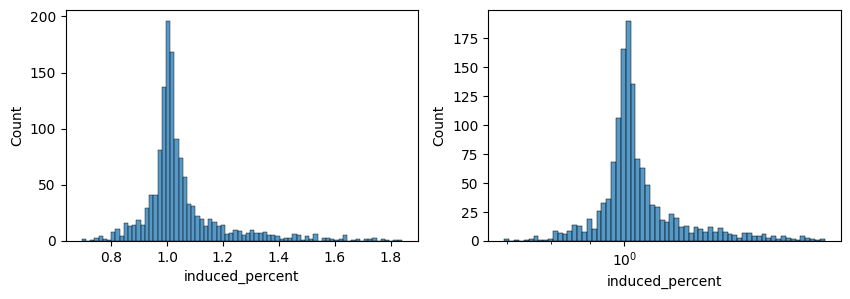

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='induced_percent',ax=axs[0]);
sns.histplot(data=features_df, x='induced_percent',log_scale=True,ax=axs[1]);
to_log_normalize['induced_percent'] = True

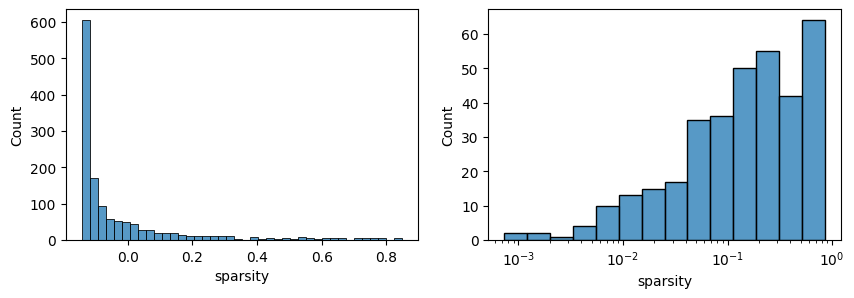

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='sparsity',ax=axs[0]);
sns.histplot(data=features_df, x='sparsity',log_scale=True,ax=axs[1]);
to_log_normalize['sparsity'] = False

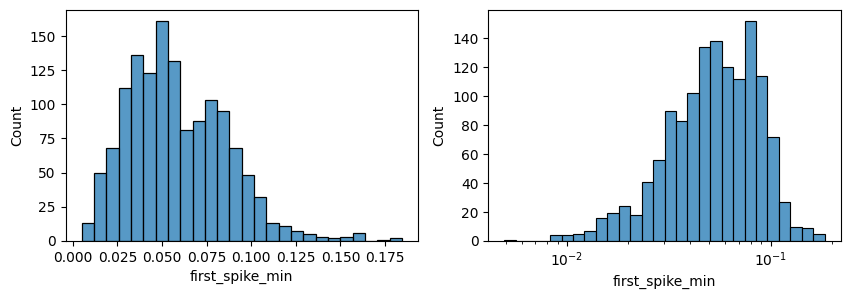

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='first_spike_min',ax=axs[0]);
sns.histplot(data=features_df, x='first_spike_min',log_scale=True,ax=axs[1]);
to_log_normalize['first_spike_min'] = True

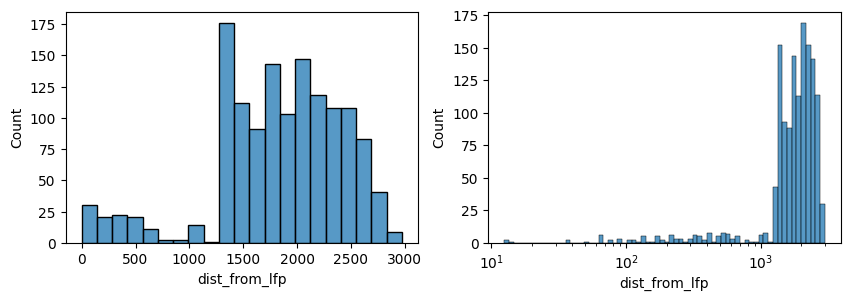

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='dist_from_lfp',ax=axs[0]);
sns.histplot(data=features_df, x='dist_from_lfp',log_scale=True,ax=axs[1]);
to_log_normalize['dist_from_lfp'] = False

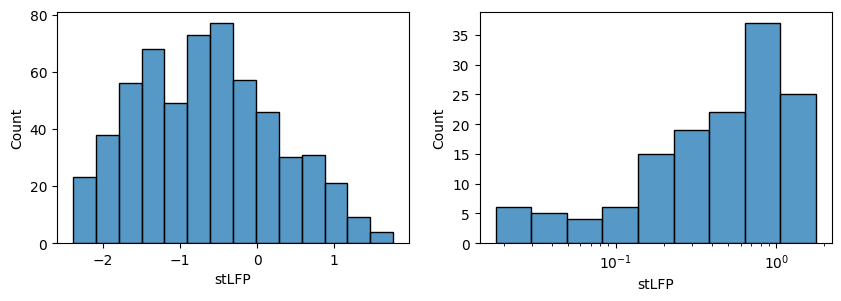

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='stLFP',ax=axs[0]);
sns.histplot(data=features_df, x='stLFP',log_scale=True,ax=axs[1]);
to_log_normalize['stLFP'] = False

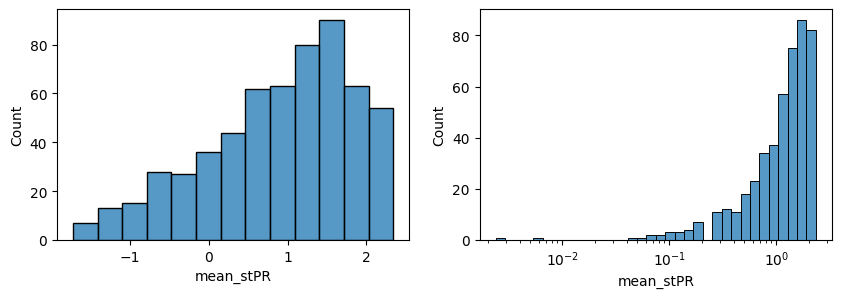

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='mean_stPR',ax=axs[0]);
sns.histplot(data=features_df, x='mean_stPR',log_scale=True,ax=axs[1]);
to_log_normalize['mean_stPR'] = False

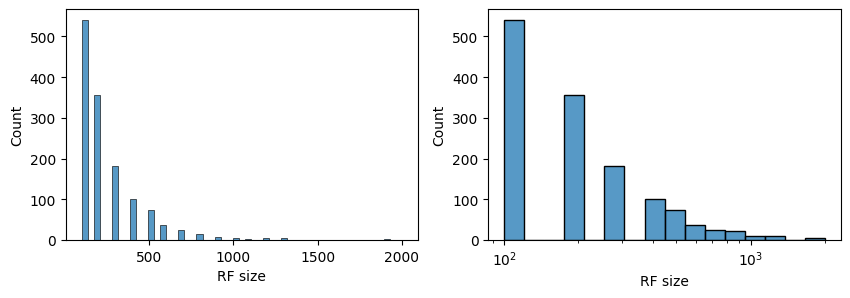

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='RF size',ax=axs[0]);
sns.histplot(data=features_df, x='RF size',log_scale=True,ax=axs[1]);
to_log_normalize['RF size'] = False

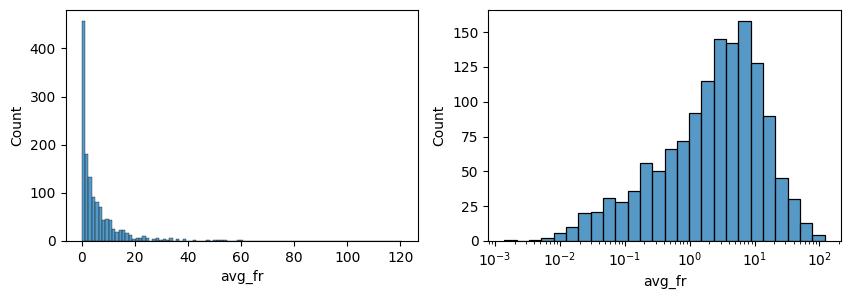

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='avg_fr',ax=axs[0]);
sns.histplot(data=features_df, x='avg_fr',log_scale=True,ax=axs[1]);
to_log_normalize['avg_fr'] = True

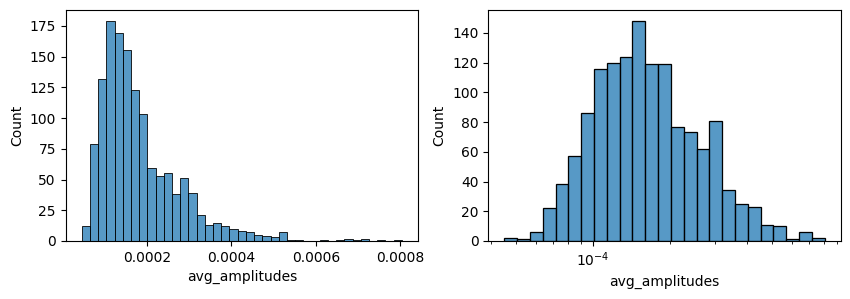

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='avg_amplitudes',ax=axs[0]);
sns.histplot(data=features_df, x='avg_amplitudes',log_scale=True,ax=axs[1]);
to_log_normalize['avg_amplitudes'] = True

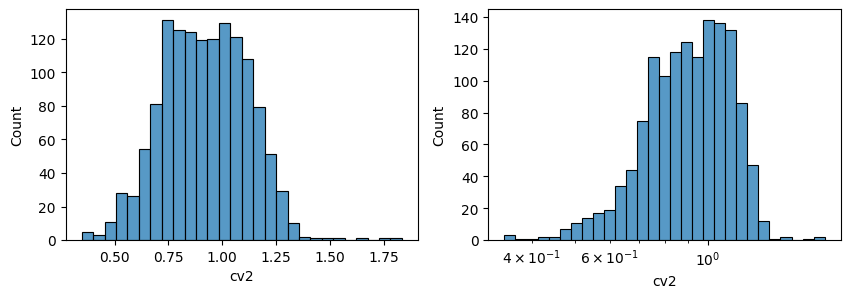

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='cv2',ax=axs[0]);
sns.histplot(data=features_df, x='cv2',log_scale=True, ax=axs[1]);
to_log_normalize['cv2'] = False

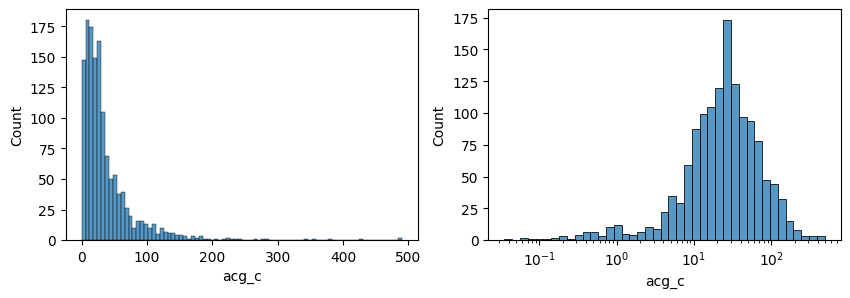

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='acg_c',ax=axs[0]);
sns.histplot(data=features_df, x='acg_c',log_scale=True, ax=axs[1]);
to_log_normalize['acg_c'] = True

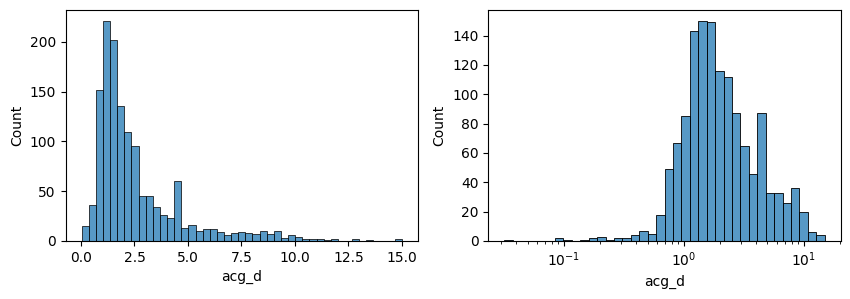

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='acg_d',ax=axs[0]);
sns.histplot(data=features_df, x='acg_d',log_scale=True, ax=axs[1]);
to_log_normalize['acg_d'] = True

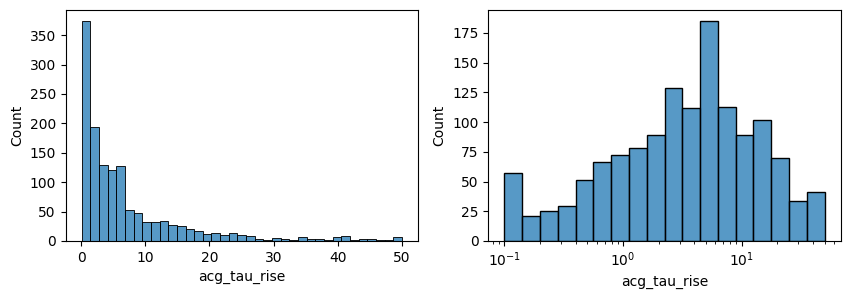

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='acg_tau_rise',ax=axs[0]);
sns.histplot(data=features_df, x='acg_tau_rise',log_scale=True, ax=axs[1]);
to_log_normalize['acg_tau_rise'] = True

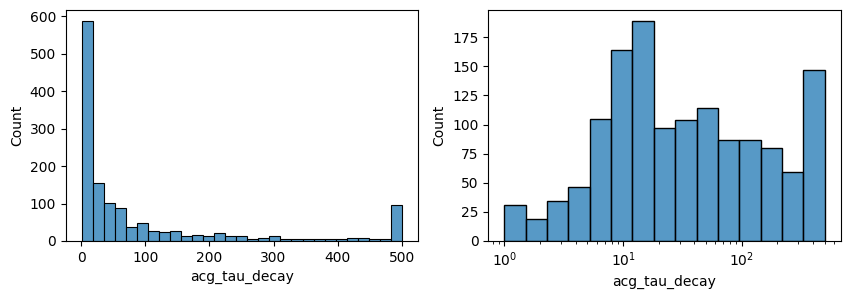

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='acg_tau_decay',ax=axs[0]);
sns.histplot(data=features_df, x='acg_tau_decay',log_scale=True, ax=axs[1]);
to_log_normalize['acg_tau_decay'] = True

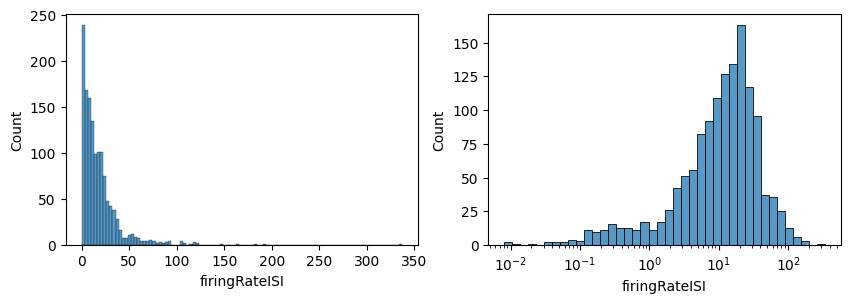

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='firingRateISI',ax=axs[0]);
sns.histplot(data=features_df, x='firingRateISI',log_scale=True, ax=axs[1]);
to_log_normalize['firingRateISI'] = True

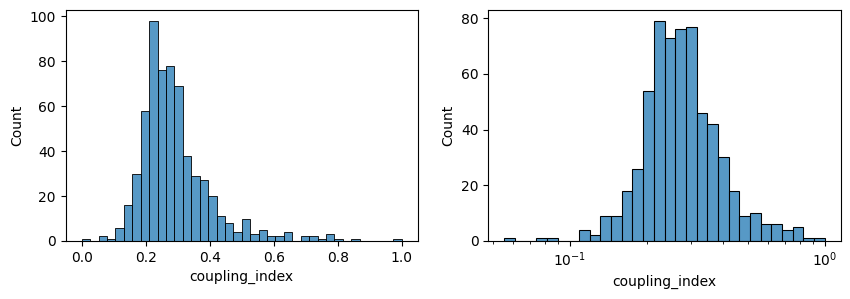

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='coupling_index',ax=axs[0]);
sns.histplot(data=features_df, x='coupling_index',log_scale=True, ax=axs[1]);
to_log_normalize['coupling_index'] = True

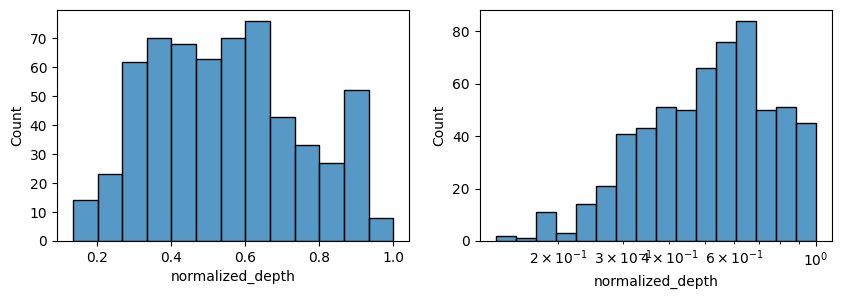

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='normalized_depth',ax=axs[0]);
sns.histplot(data=features_df, x='normalized_depth',log_scale=True, ax=axs[1]);
to_log_normalize['normalized_depth'] = False

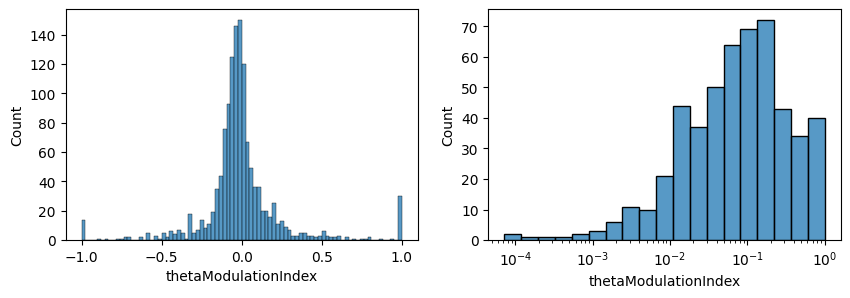

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='thetaModulationIndex',ax=axs[0]);
sns.histplot(data=features_df, x='thetaModulationIndex',log_scale=True, ax=axs[1]);
to_log_normalize['thetaModulationIndex'] = False

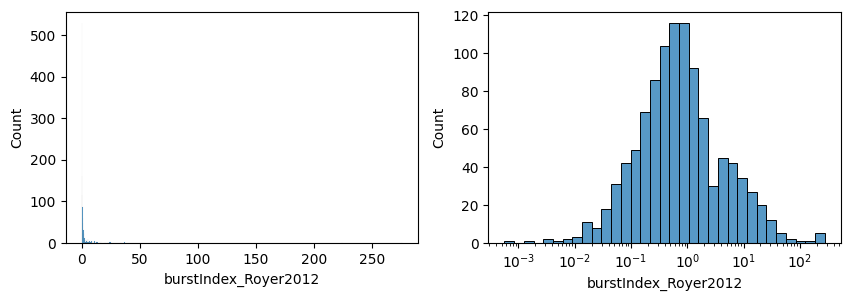

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='burstIndex_Royer2012',ax=axs[0]);
sns.histplot(data=features_df, x='burstIndex_Royer2012',log_scale=True, ax=axs[1]);
to_log_normalize['burstIndex_Royer2012'] = True

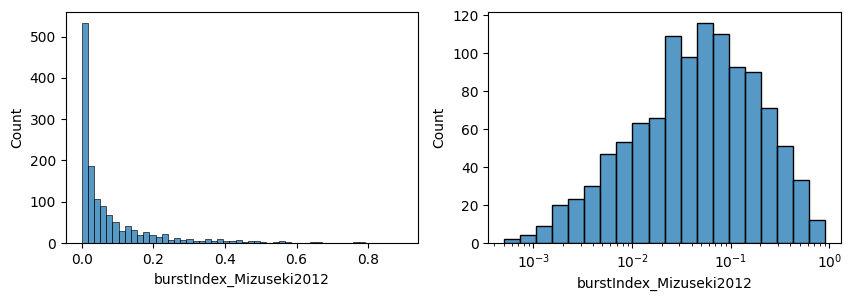

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='burstIndex_Mizuseki2012',ax=axs[0]);
sns.histplot(data=features_df, x='burstIndex_Mizuseki2012',log_scale=True, ax=axs[1]);
to_log_normalize['burstIndex_Mizuseki2012'] = True

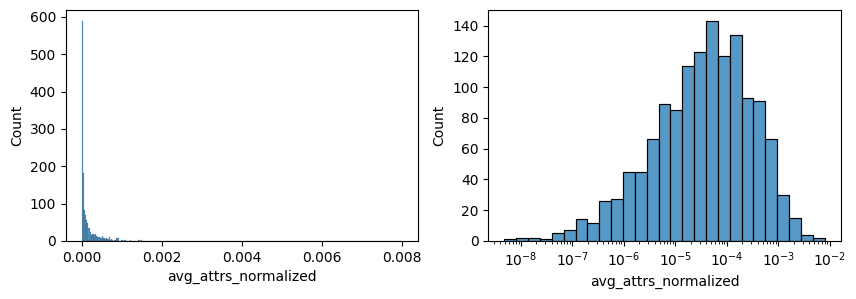

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,3))
sns.histplot(data=features_df, x='avg_attrs_normalized',ax=axs[0]);
sns.histplot(data=features_df, x='avg_attrs_normalized',log_scale=True, ax=axs[1]);
to_log_normalize['avg_attrs_normalized'] = True

#### Plot all features

avg_amplitudes


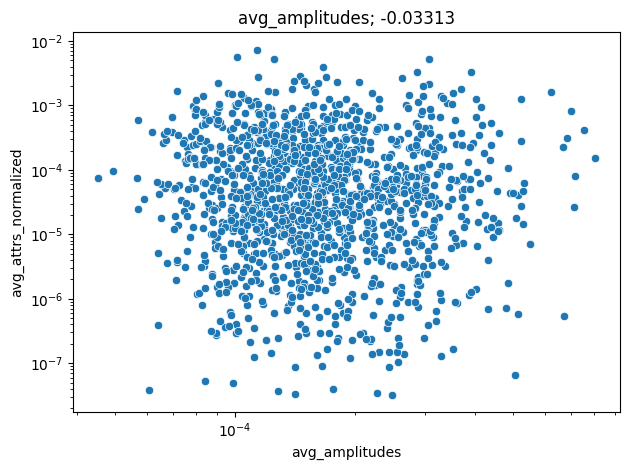

RF size


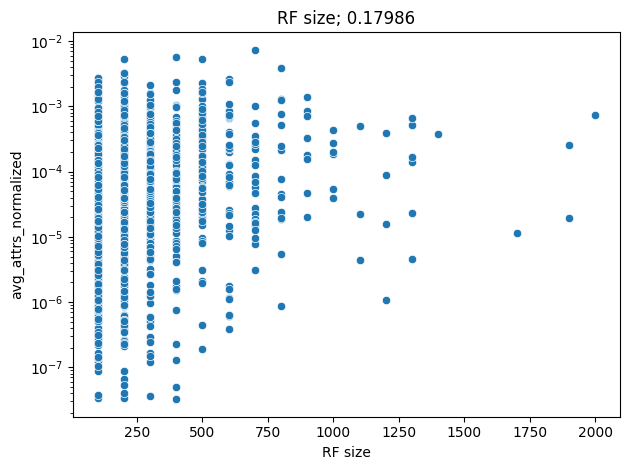

avg_fr


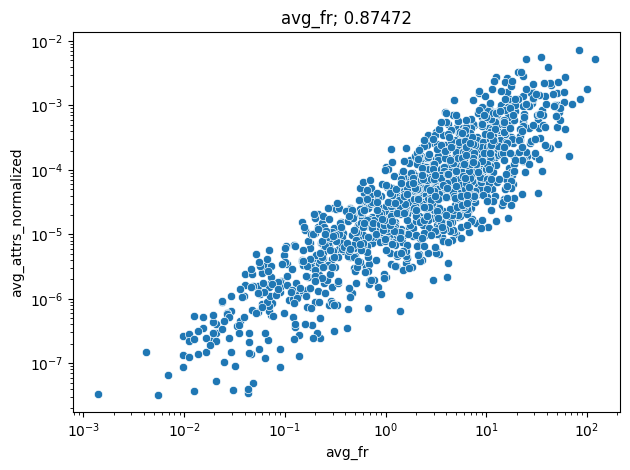

avg_attrs_normalized
cv2


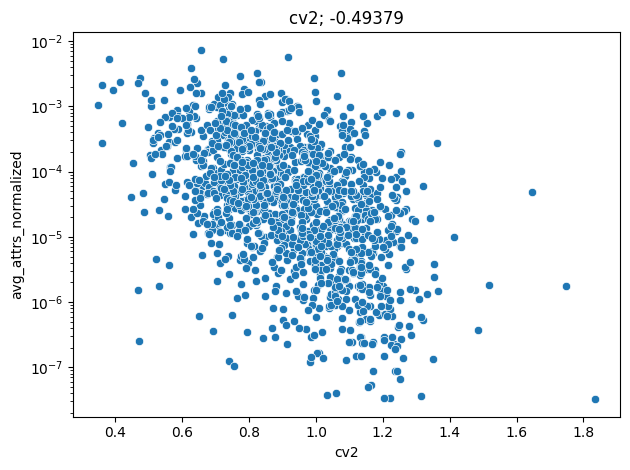

acg_c


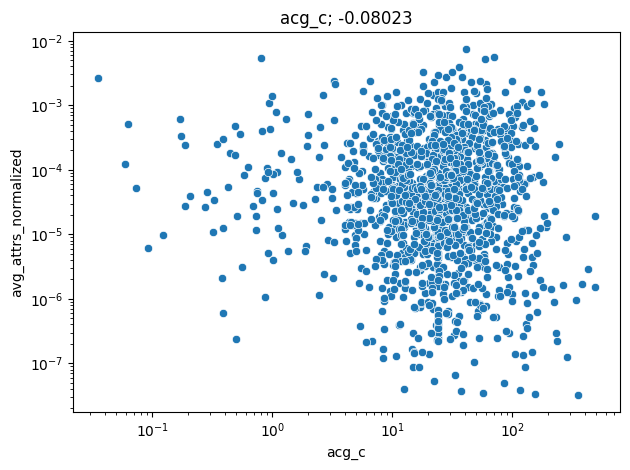

acg_d


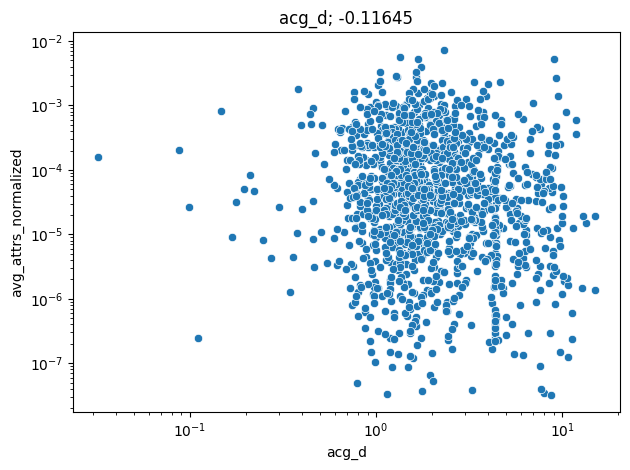

acg_tau_rise


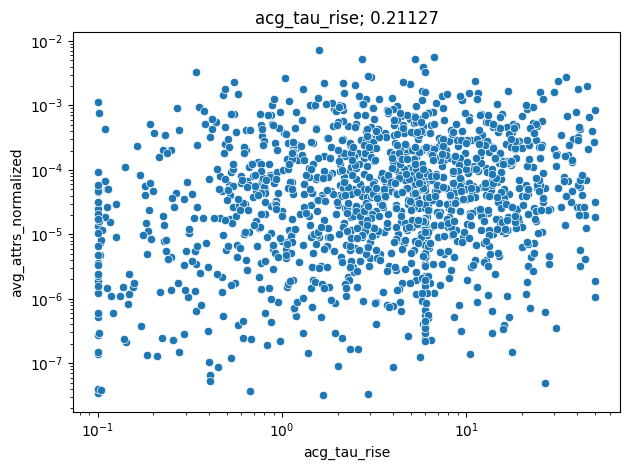

acg_tau_decay


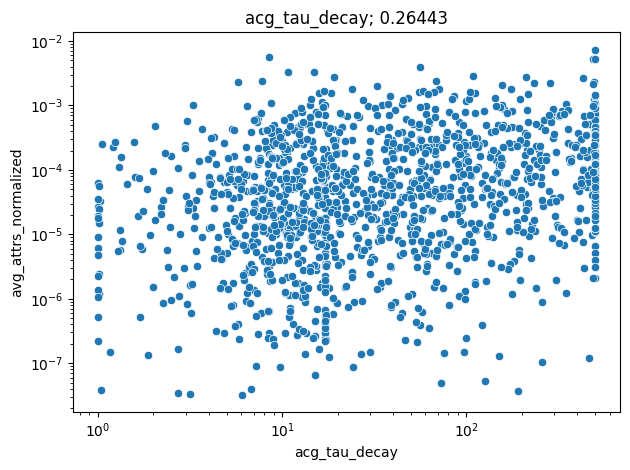

firingRateISI


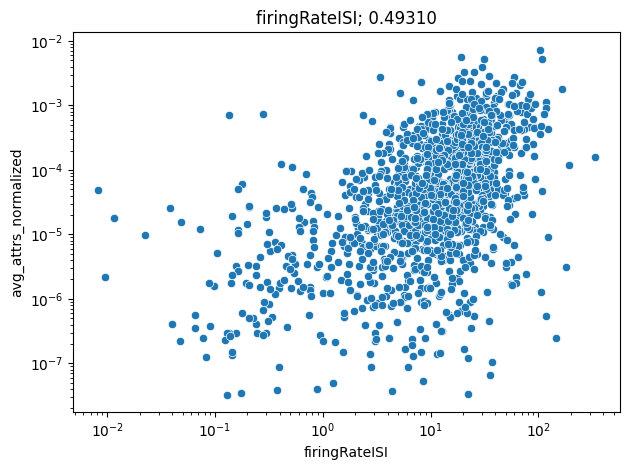

coupling_index


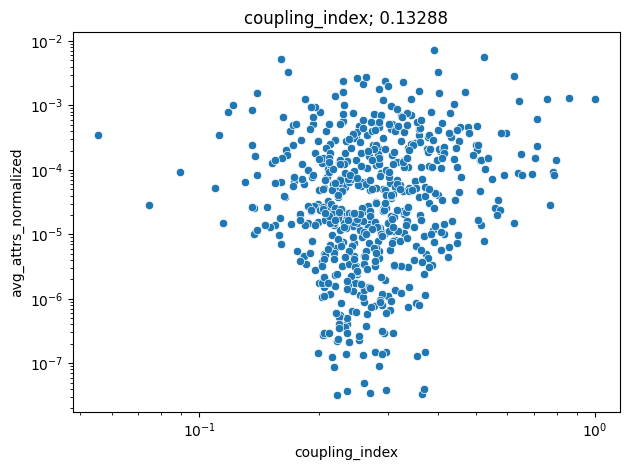

normalized_depth


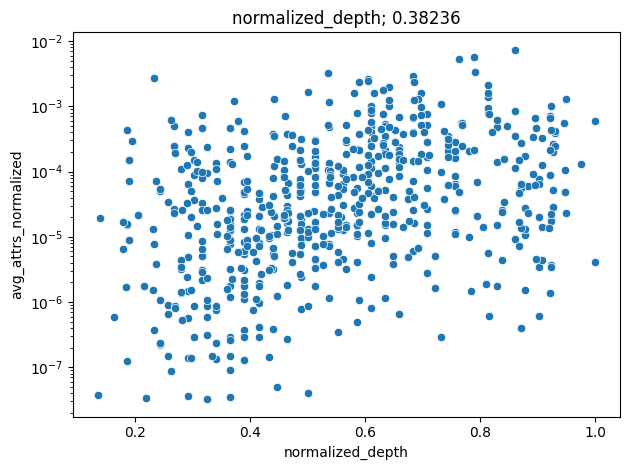

thetaModulationIndex


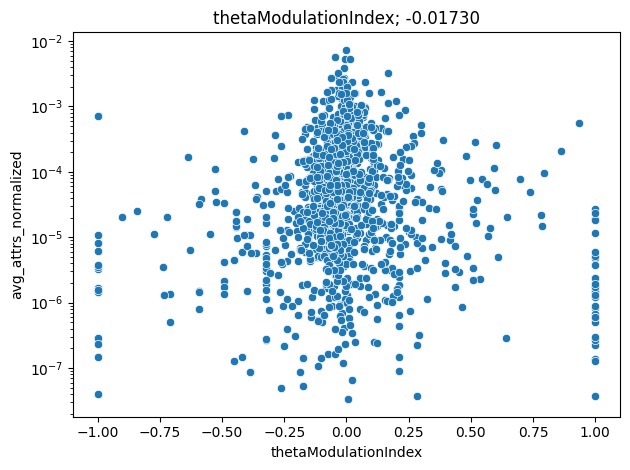

burstIndex_Royer2012


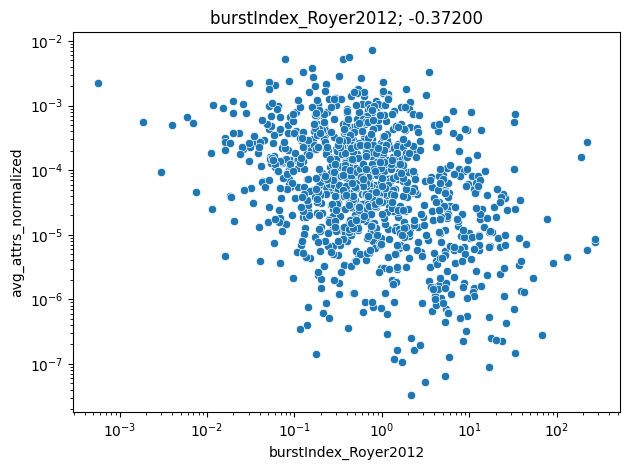

burstIndex_Mizuseki2012


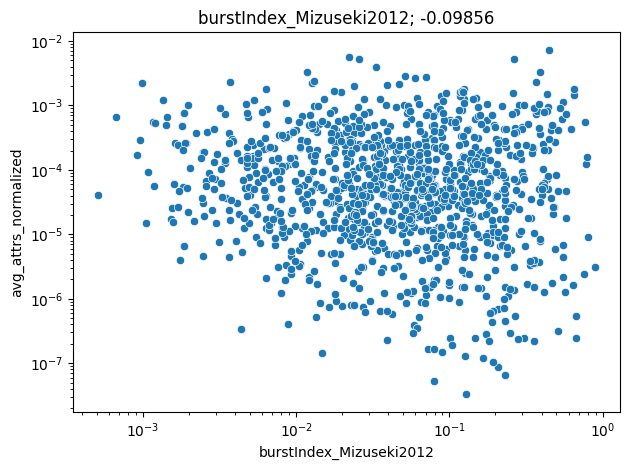

stLFP


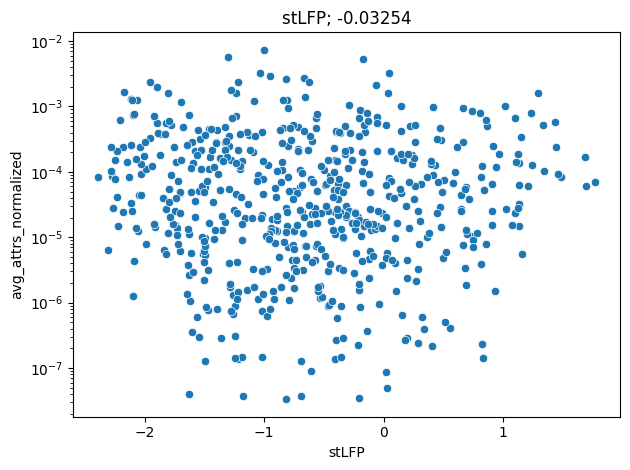

mean_stPR


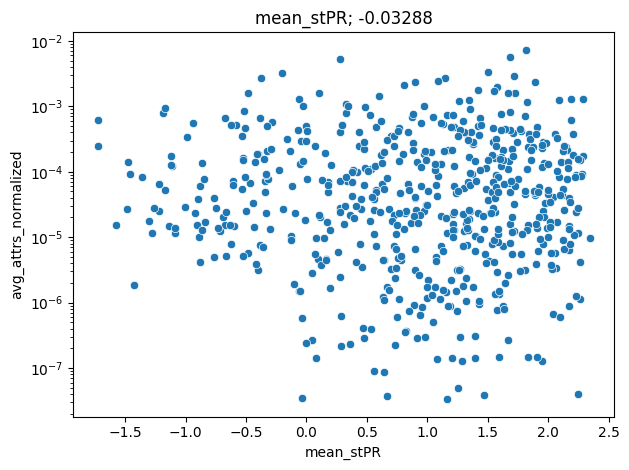

dist_from_lfp


KeyError: 'dist_from_lfp'

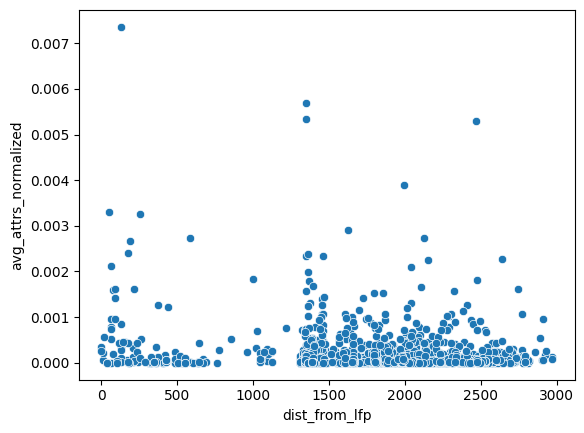

In [ ]:
# value filters to make sure nothing wrong with log normalization
nan_filter = ~np.isnan(features_df['avg_attrs_normalized'].values)
inf_filter = ~np.isinf(features_df['avg_attrs_normalized'].values)
zero_filter = features_df['avg_attrs_normalized'].values != 0
attr_filter = nan_filter & inf_filter & zero_filter
cols = features_df.columns
for col in cols: # for each feature, we plot the correlation graph with avg_attrs_normalized
    print(col)
    if col == 'avg_attrs_normalized': continue
    if col == 'avg_attrs_normalized_log': continue
    plot = sns.scatterplot(data=features_df, x=col, y='avg_attrs_normalized')
    # filter for both axes
    nan_filter = ~np.isnan(features_df[col].values)
    inf_filter = ~np.isinf(features_df[col].values)
    zero_filter = features_df[col].values != 0
    value_filter = nan_filter & inf_filter & zero_filter & attr_filter
    if to_log_normalize[col]:
        plt.xscale('log')
    plt.yscale('log') # avg attrs normalized is always log normalized
    if to_log_normalize[col]:
        plot.set_title(f"{col}; {np.corrcoef(np.log10(features_df[col].values[value_filter]), np.log10(features_df['avg_attrs_normalized'].values[value_filter]))[0,1]:.5f}")
    else:
        plot.set_title(f"{col}; {np.corrcoef(features_df[col].values[value_filter], np.log10(features_df['avg_attrs_normalized'].values[value_filter]))[0,1]:.5f}")
    plt.tight_layout()
    # plt.savefig(f"{fig_storage_dir}{col}.png") # save the figure
    # plt.close() # close the figure to save memory and to speed up the process
    plt.show()

avg_amplitudes


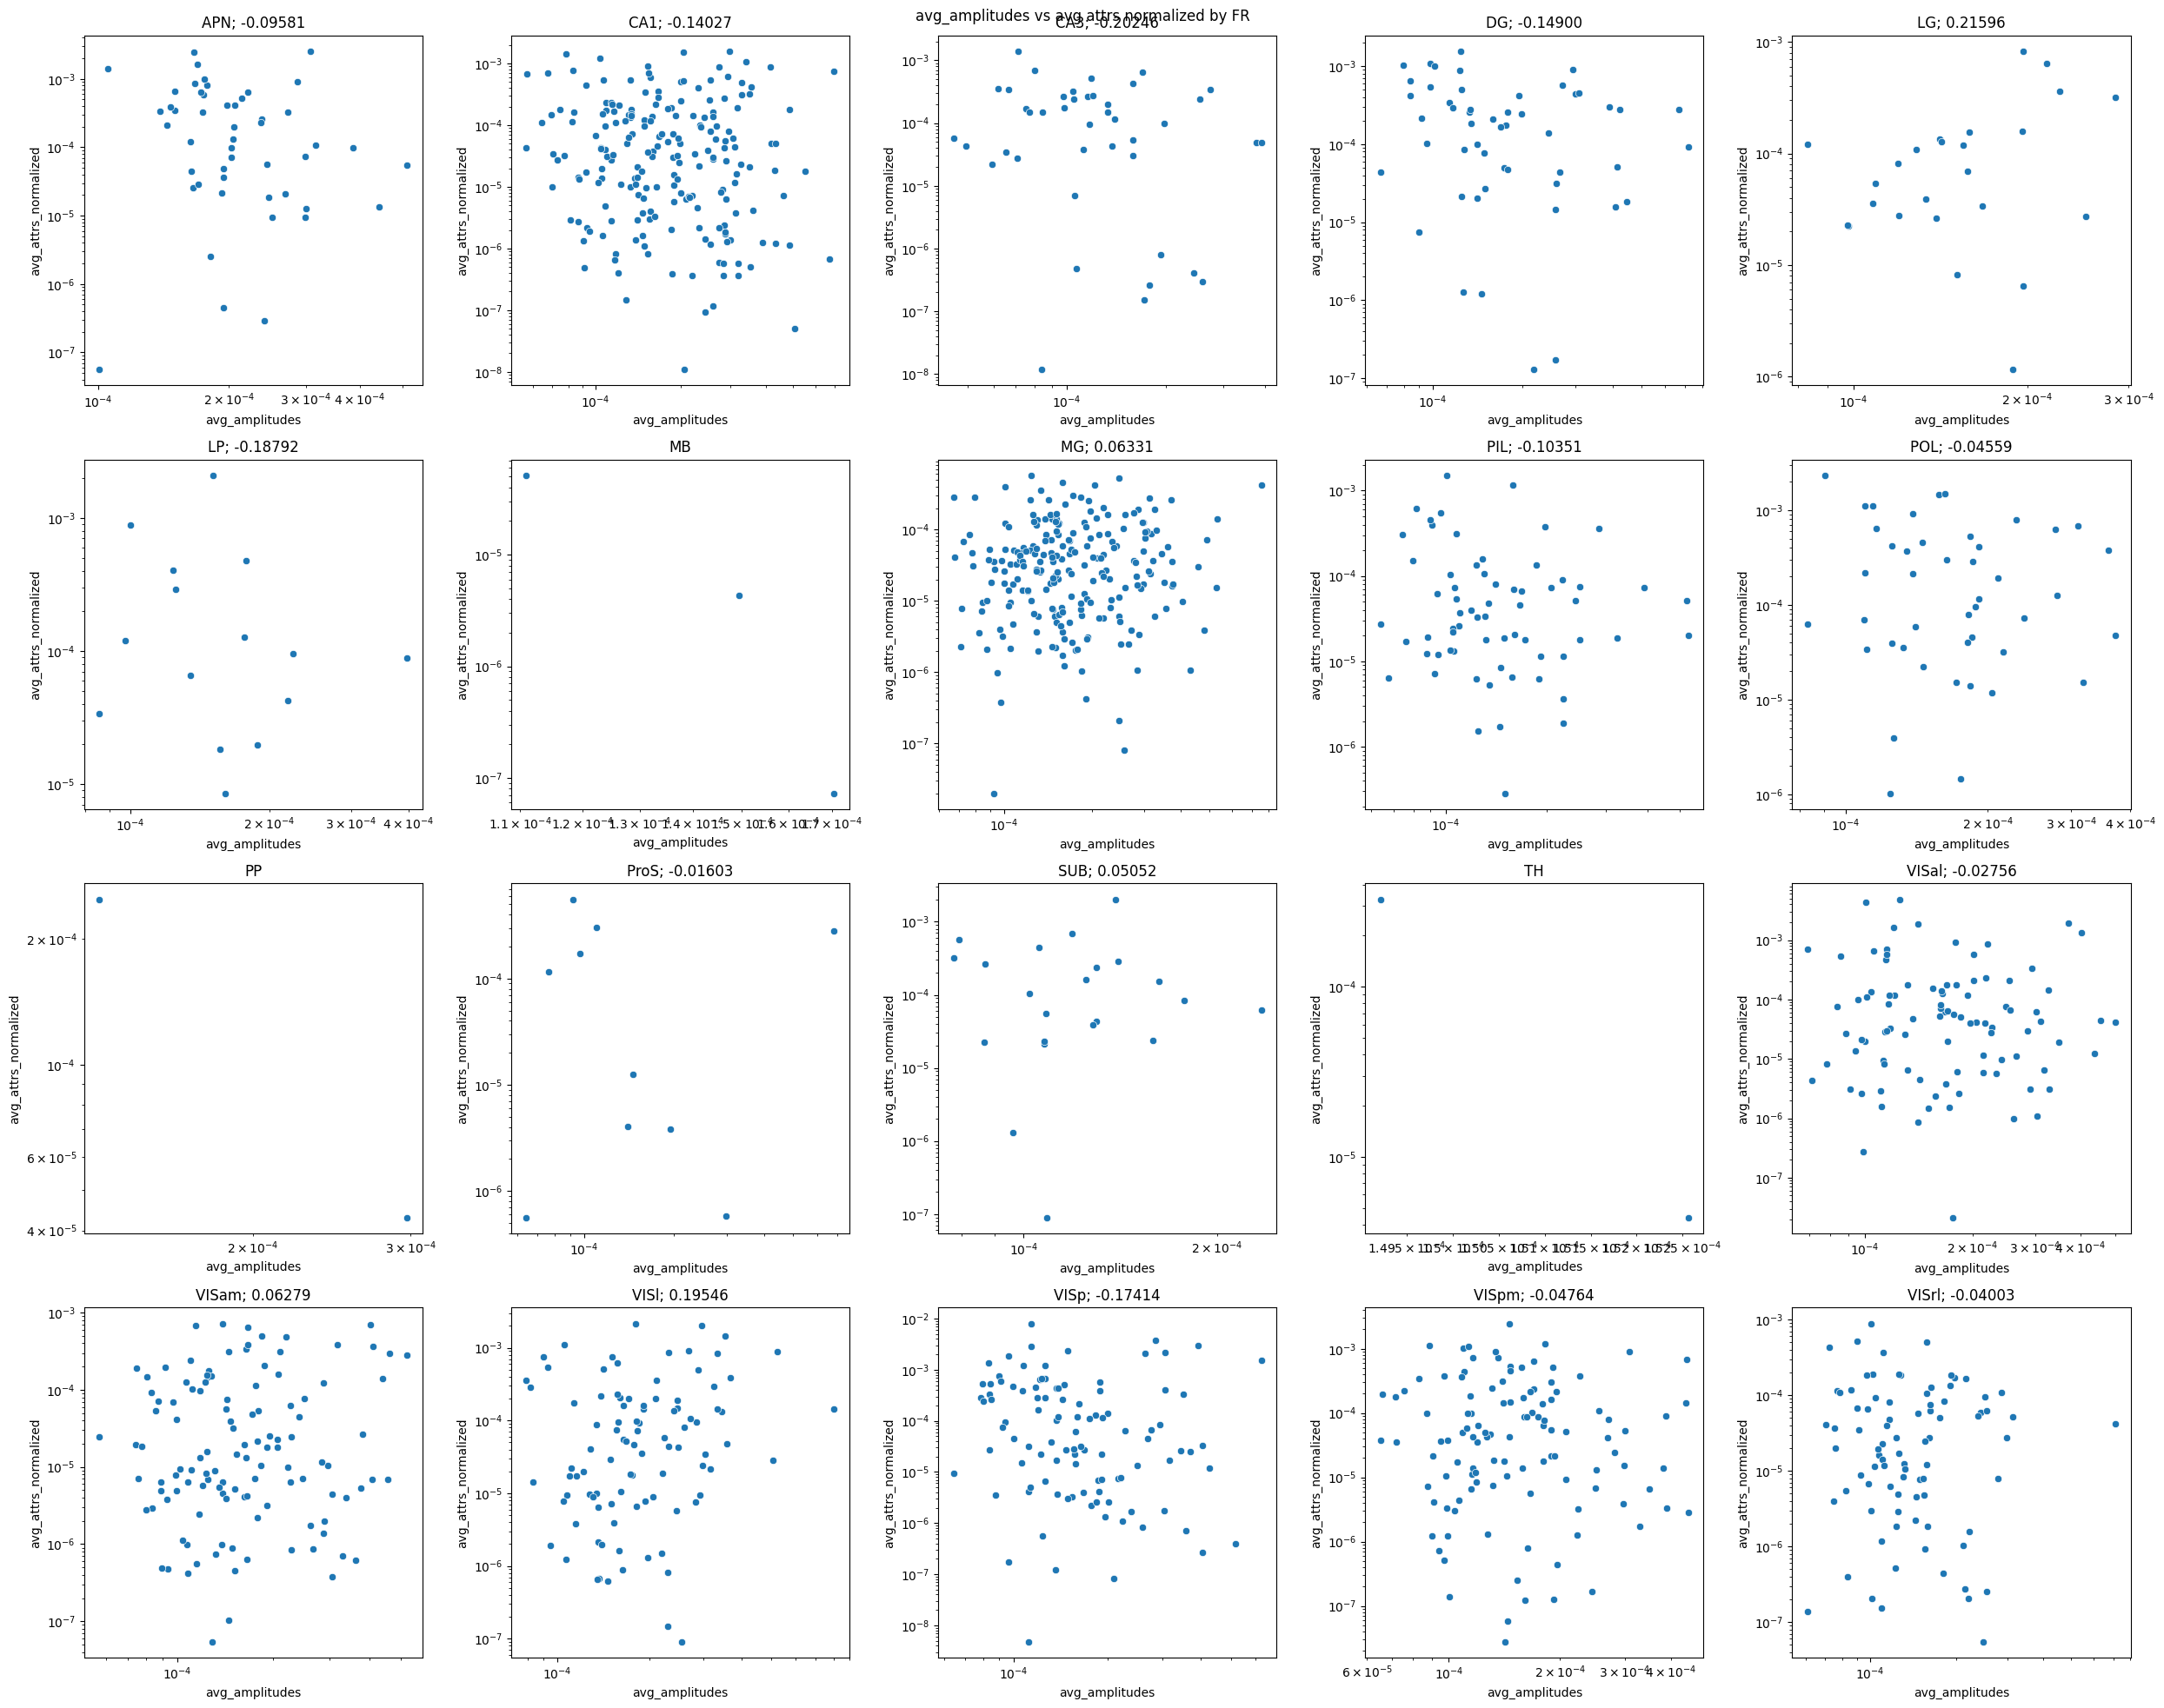

RF size


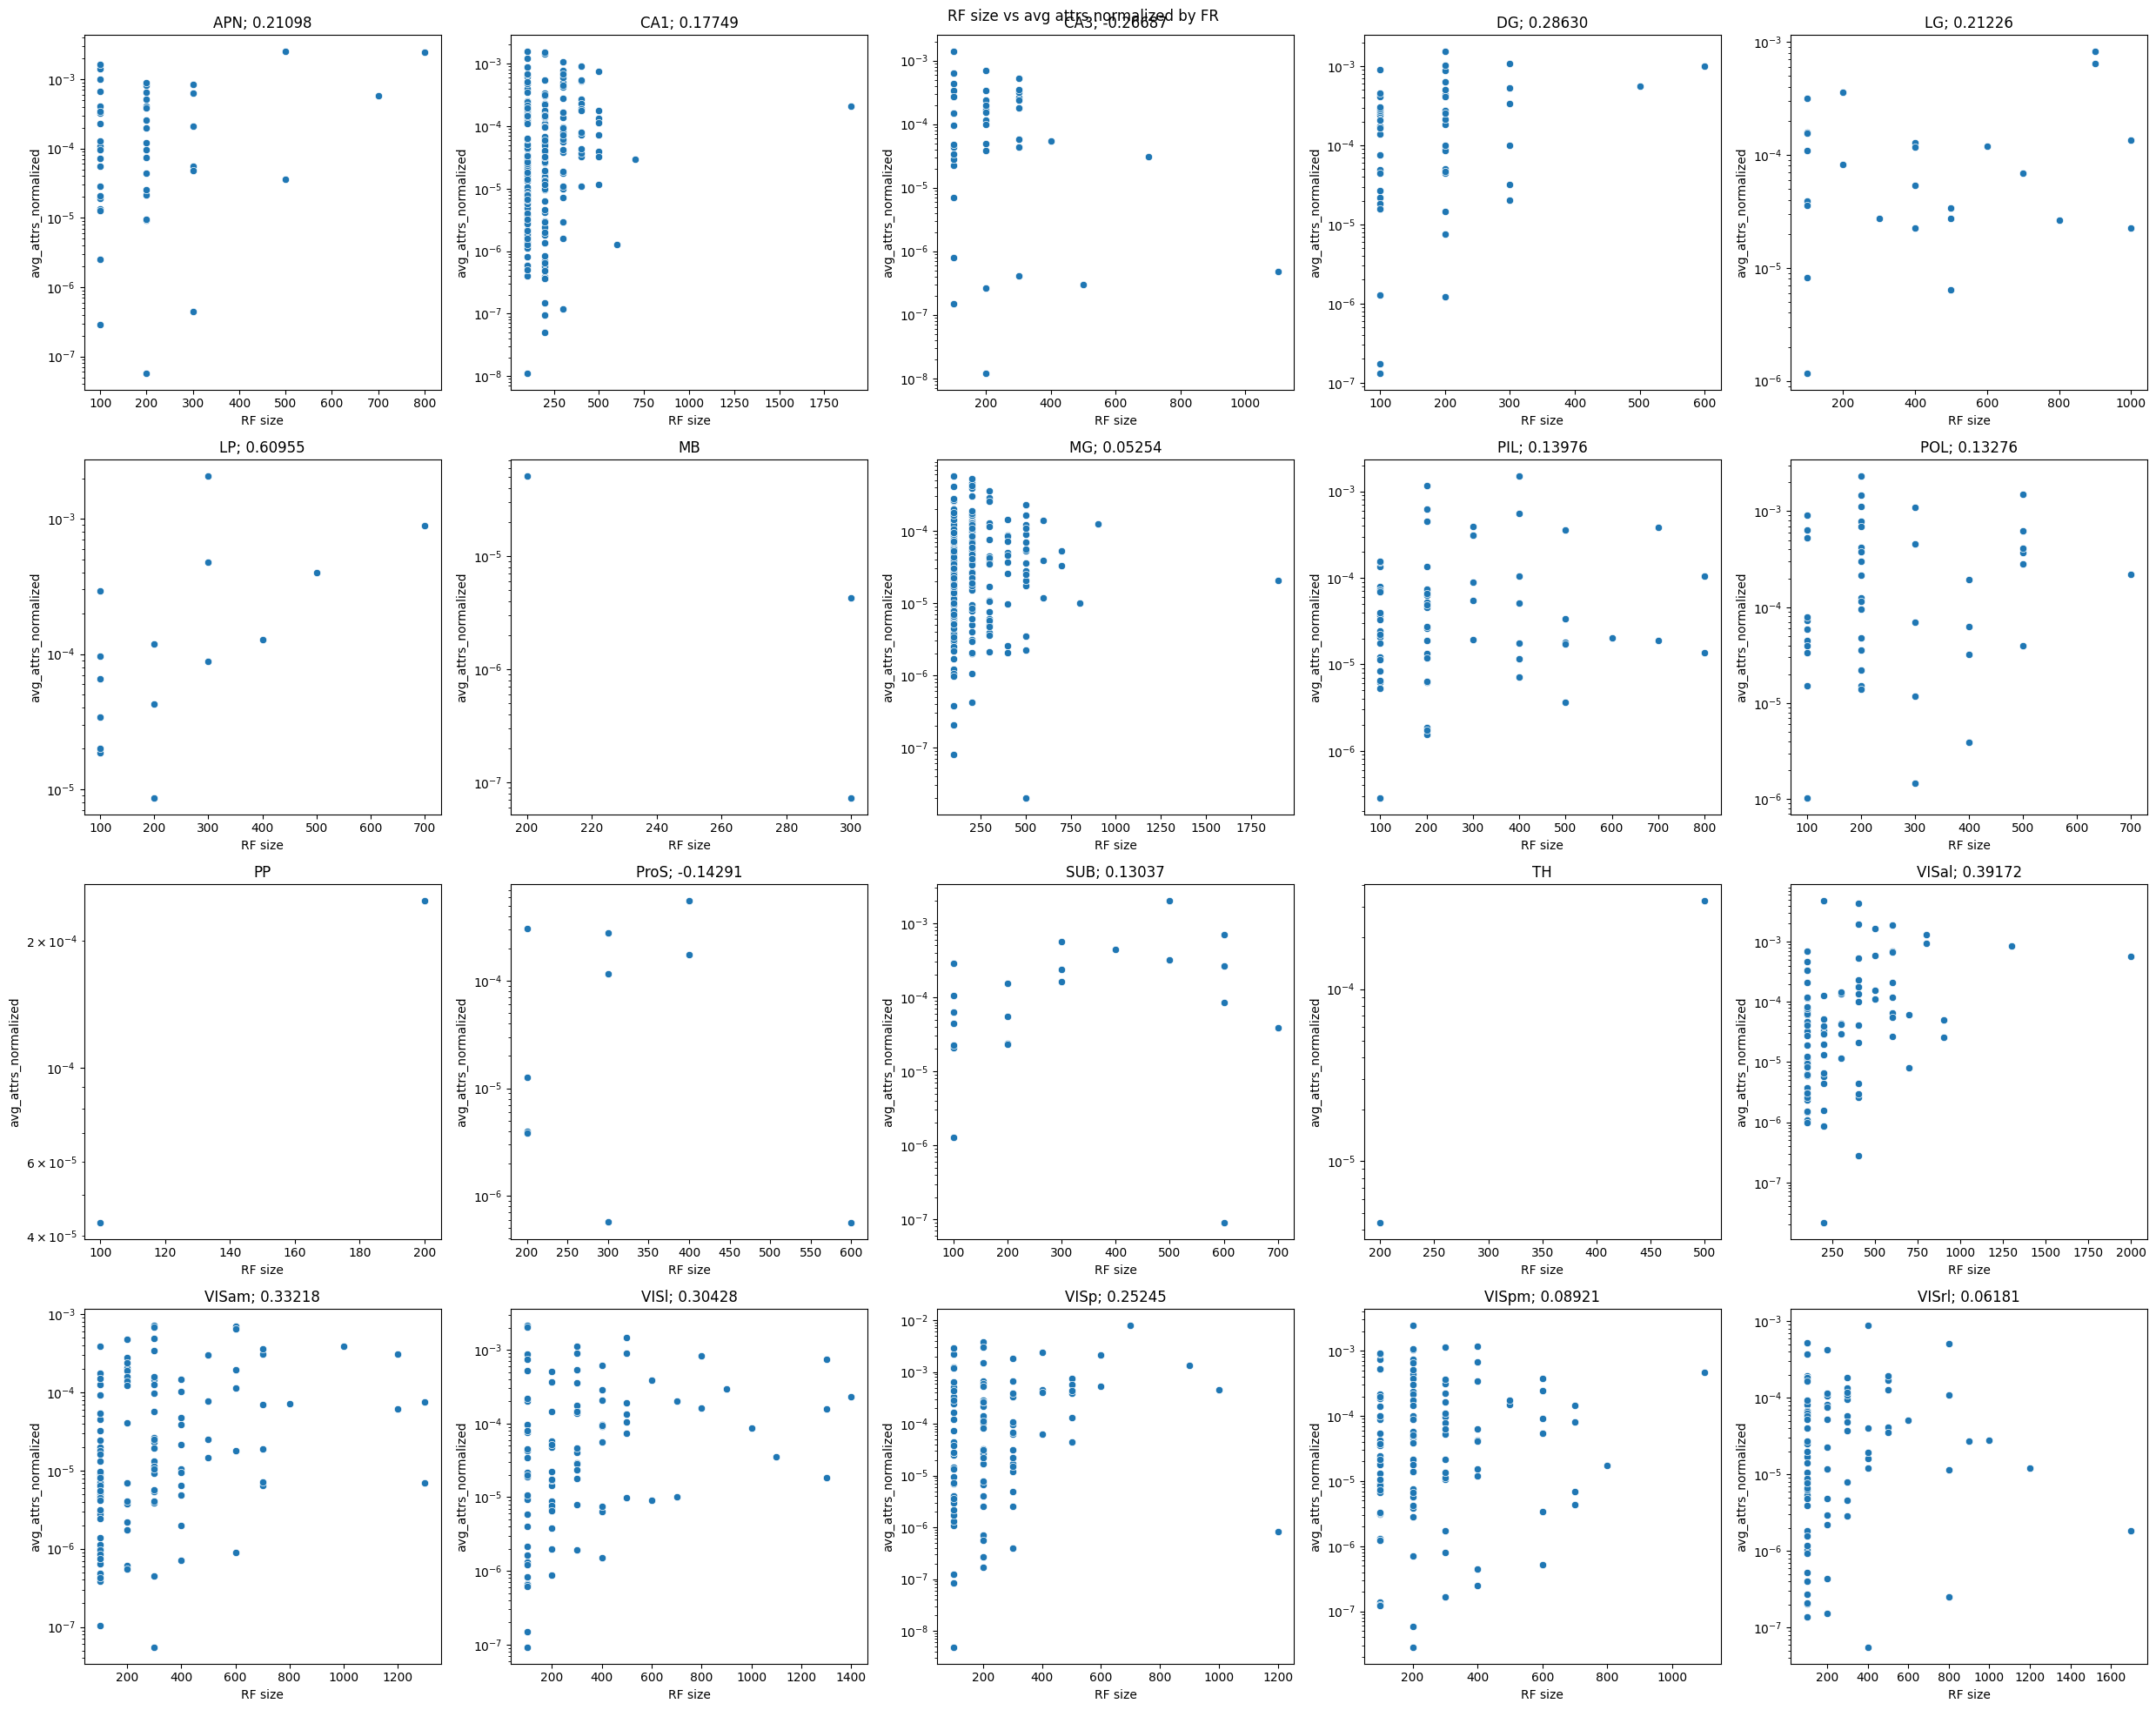

avg_fr


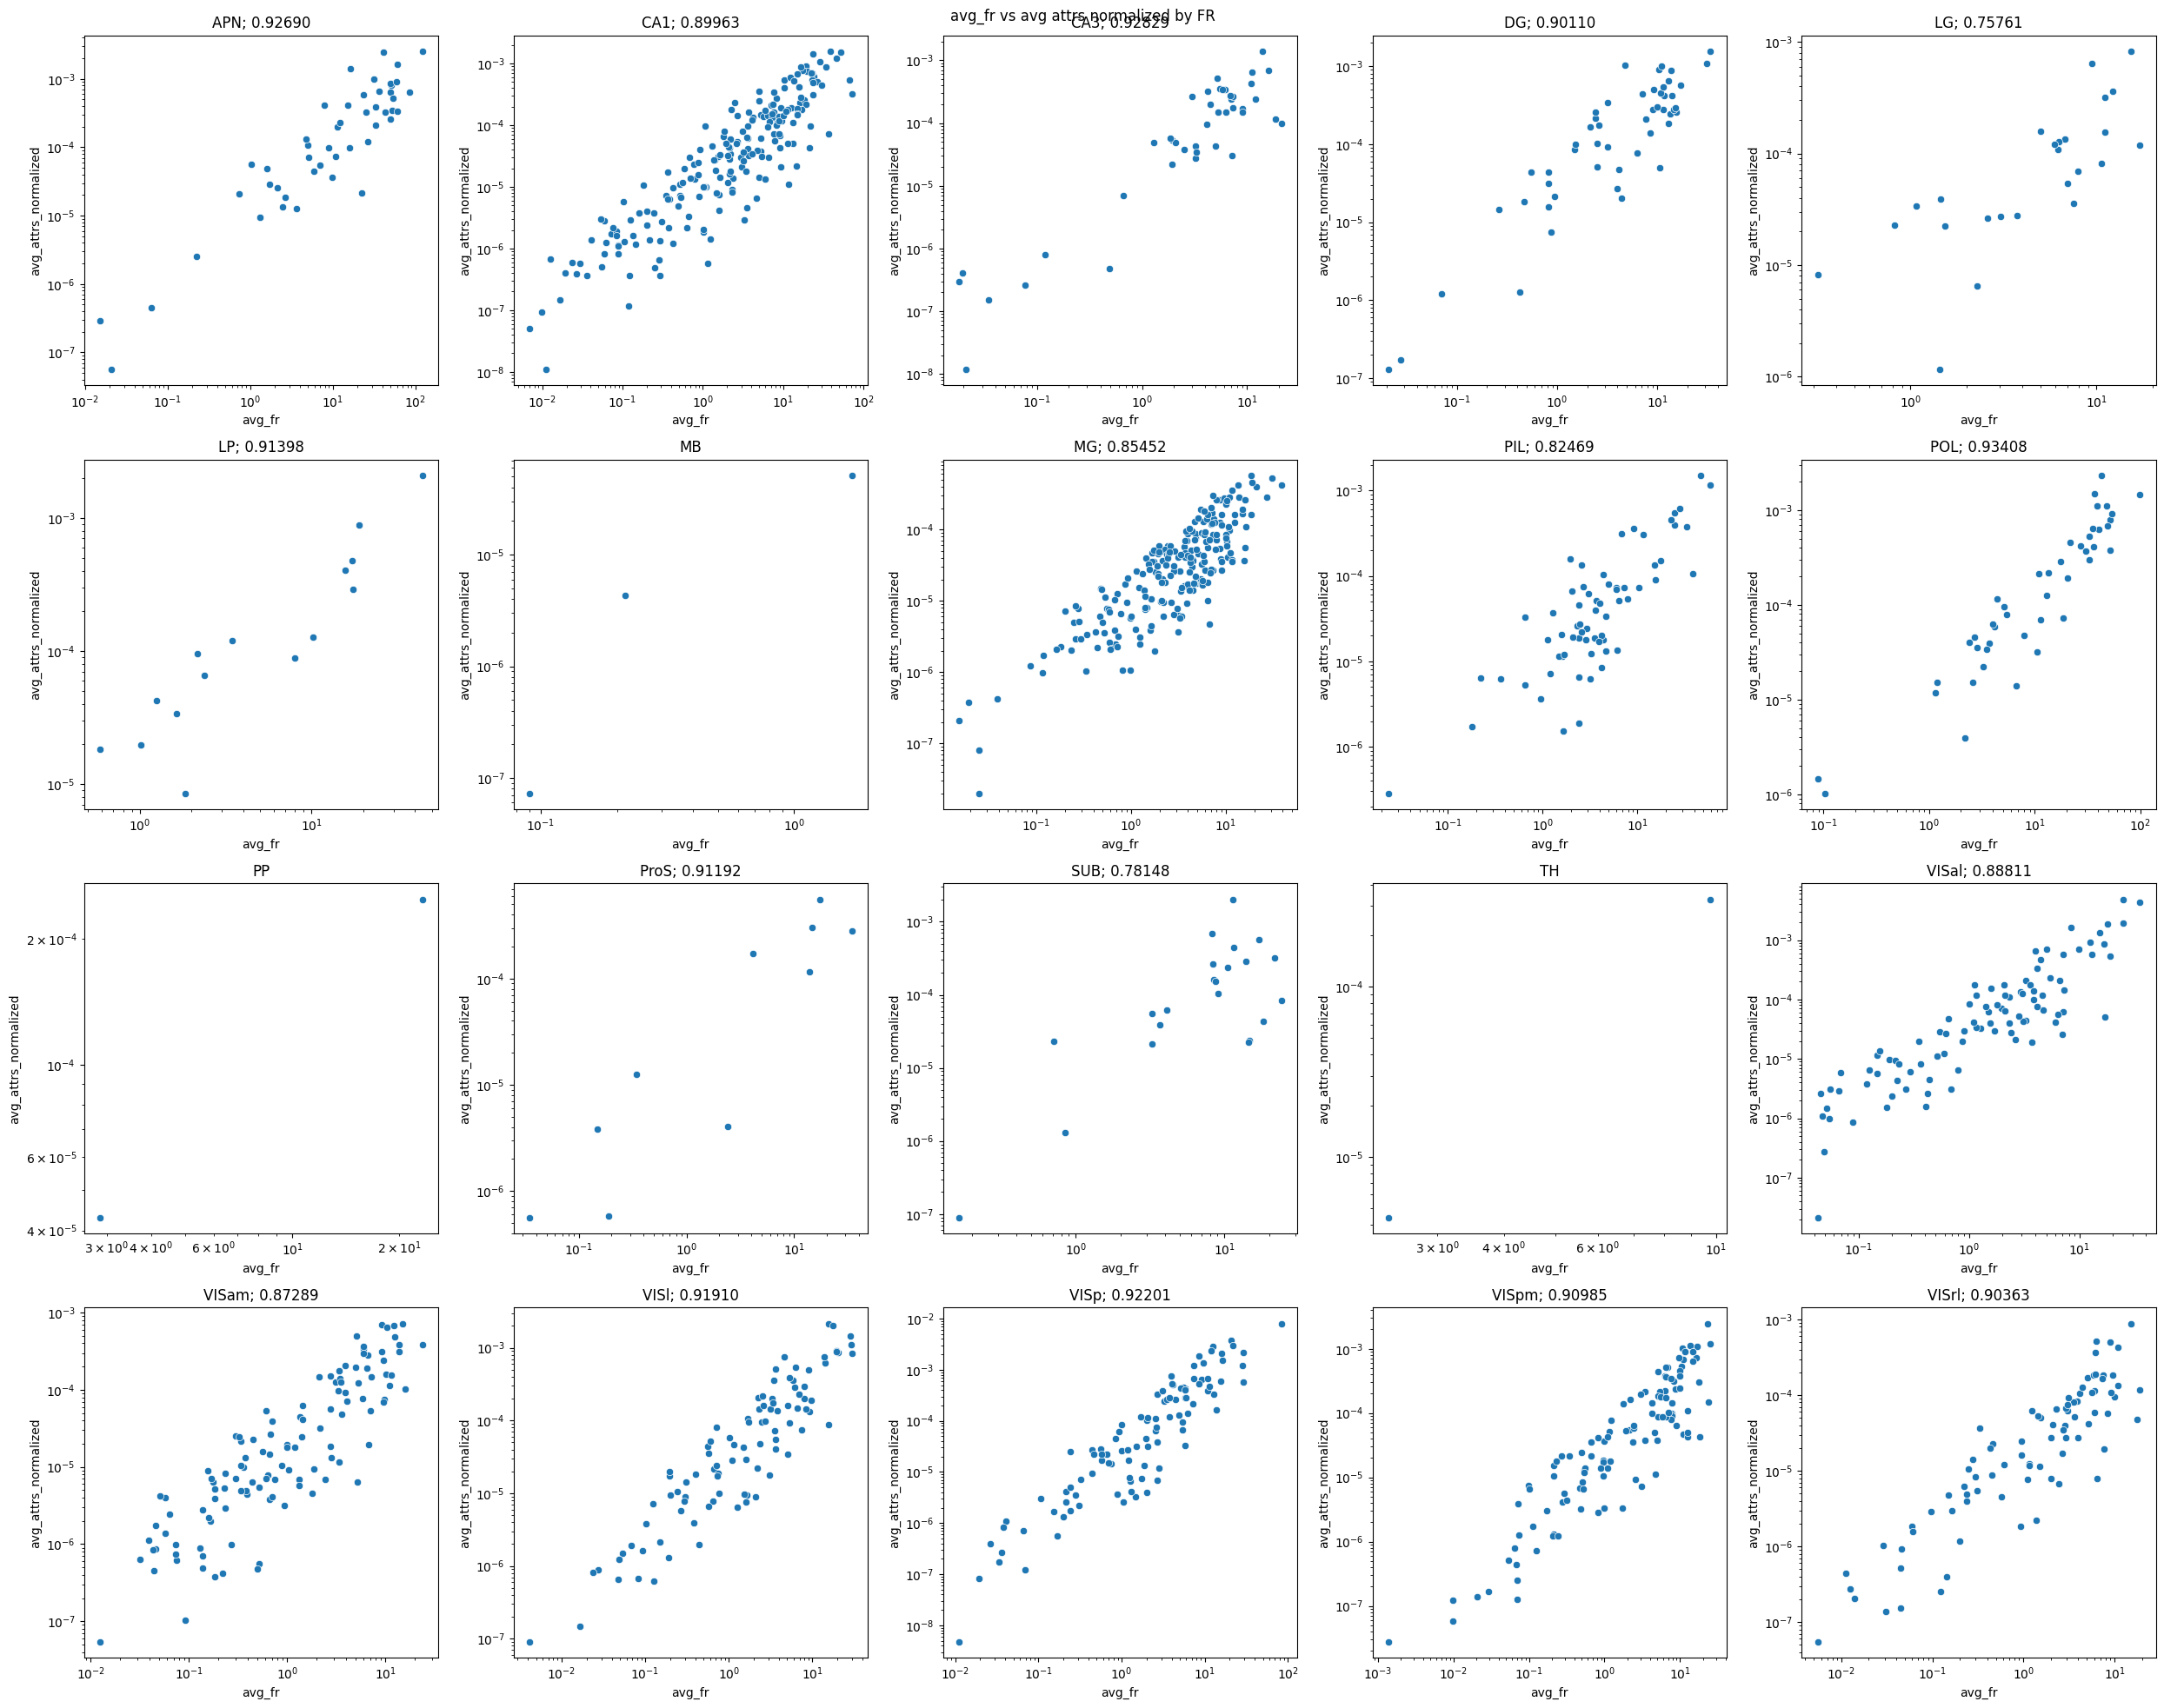

avg_attrs_normalized
cv2


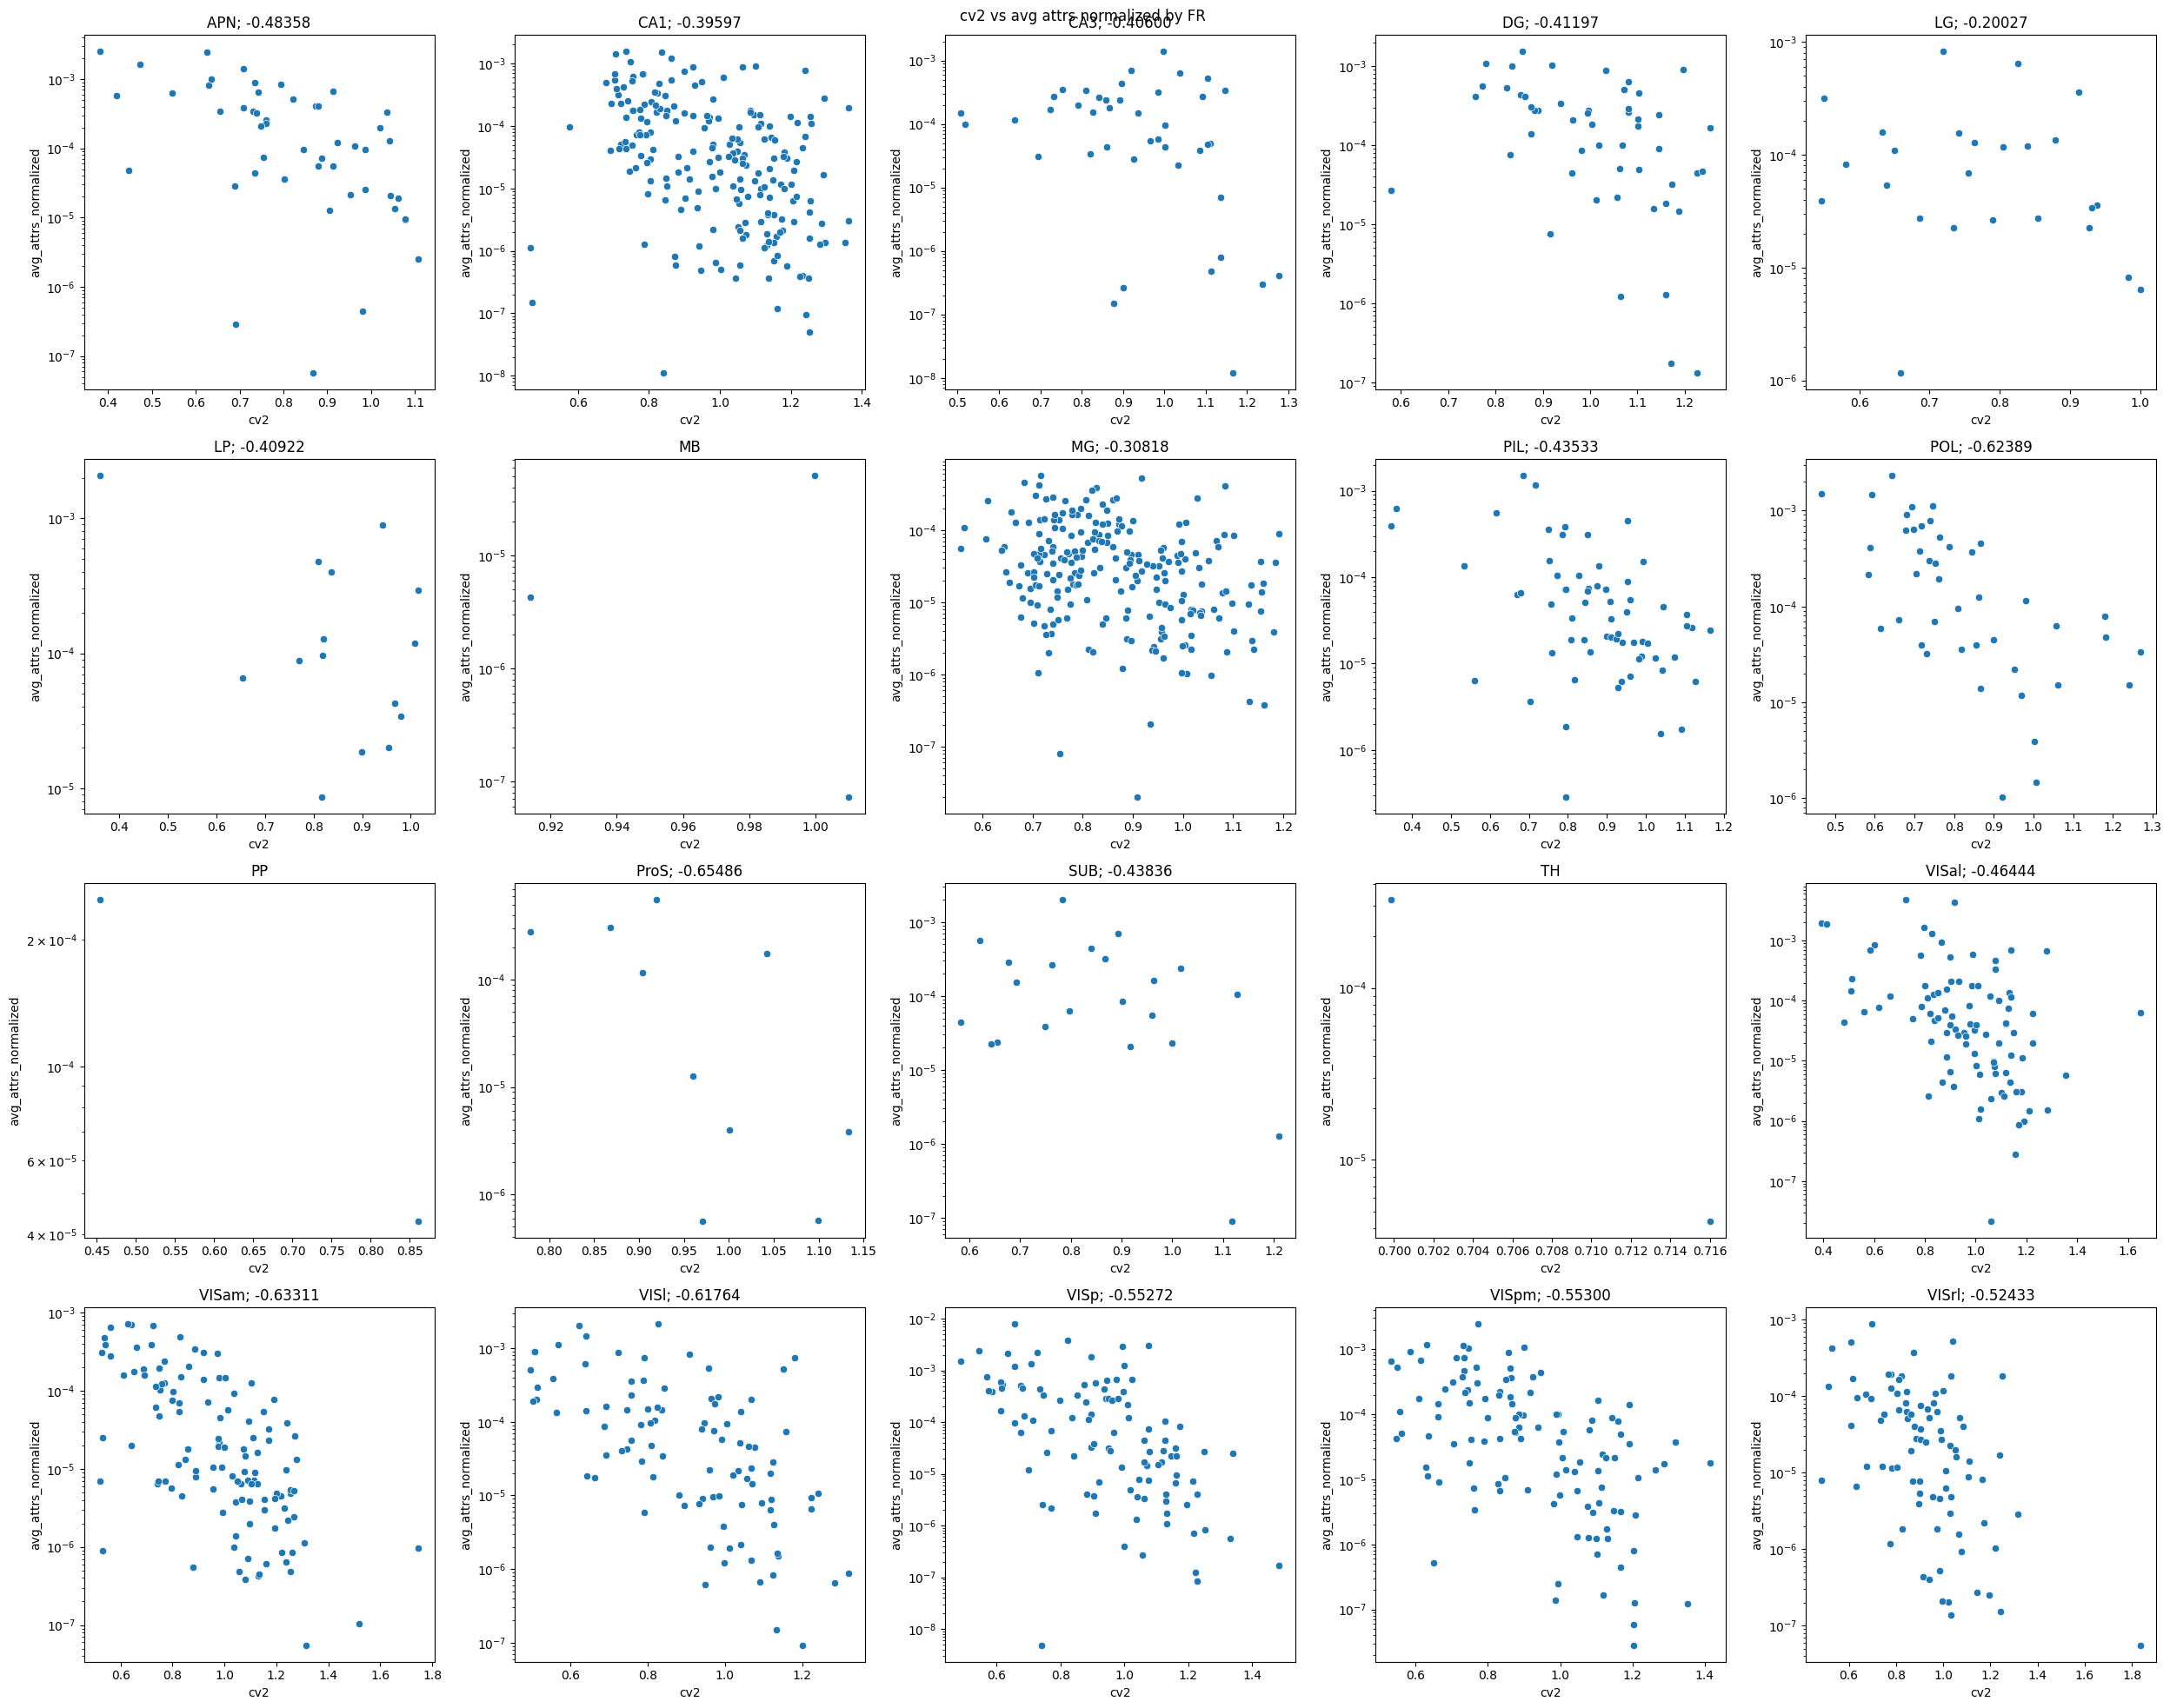

acg_c


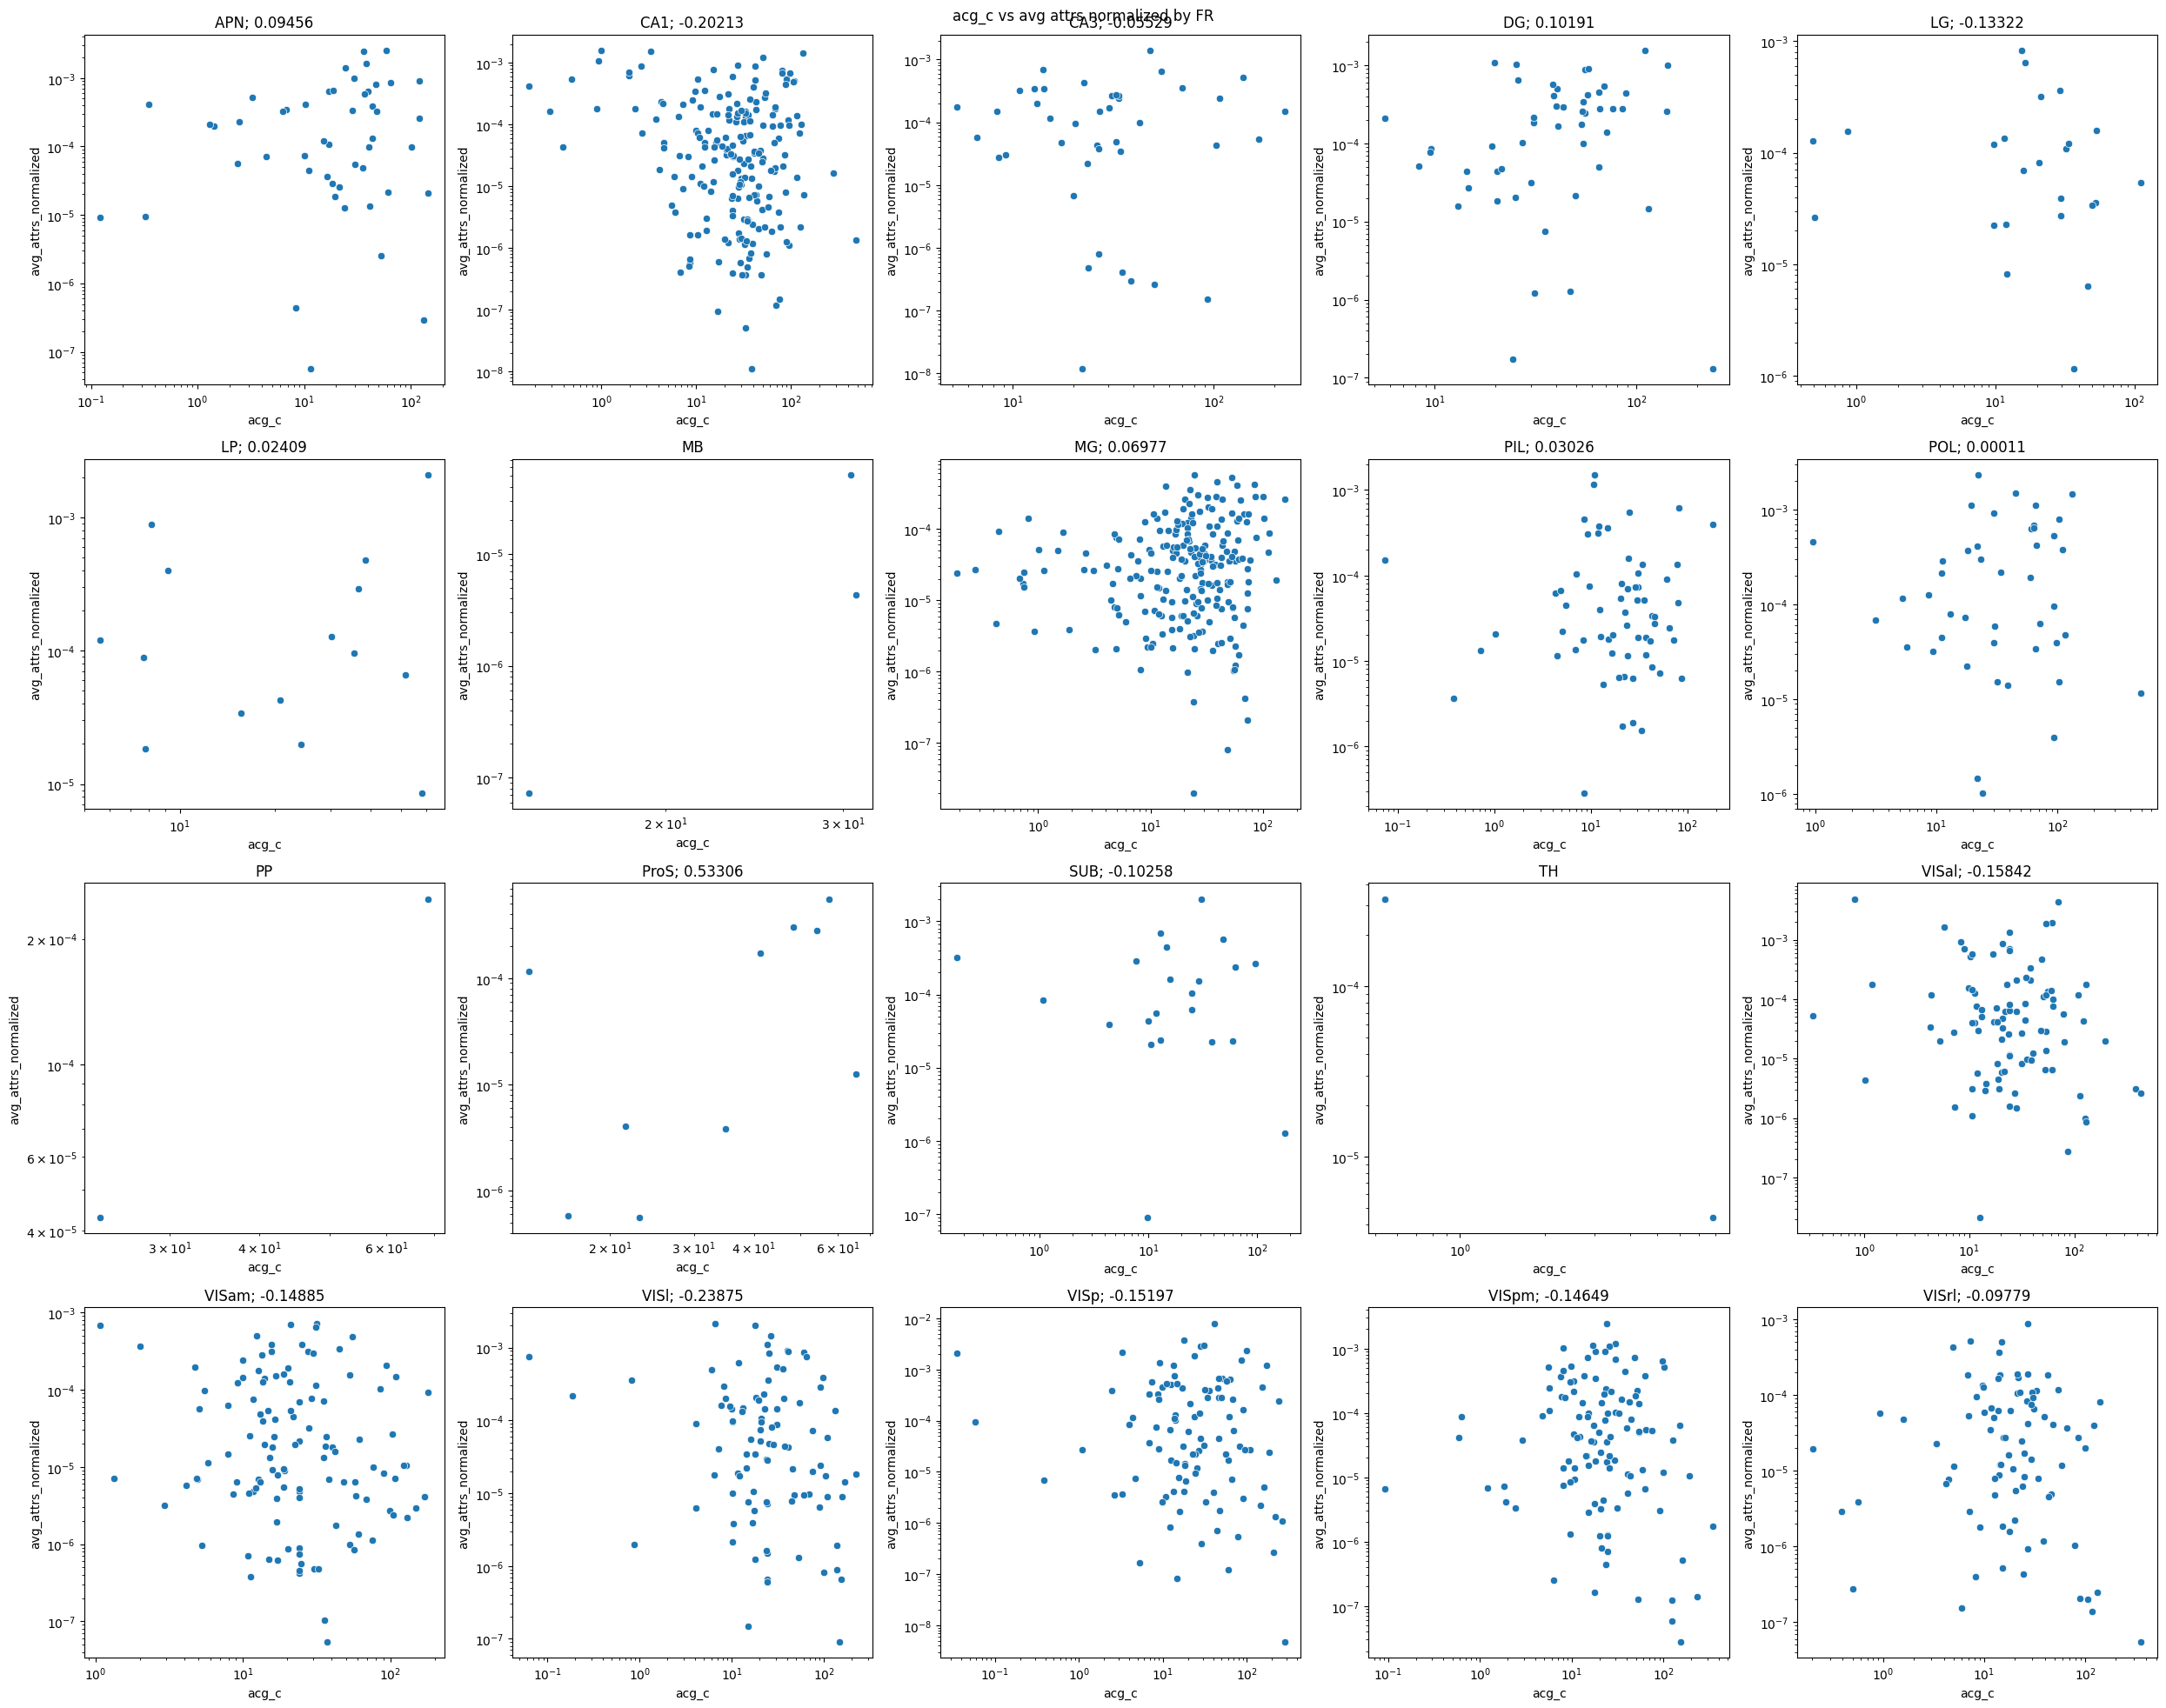

acg_d


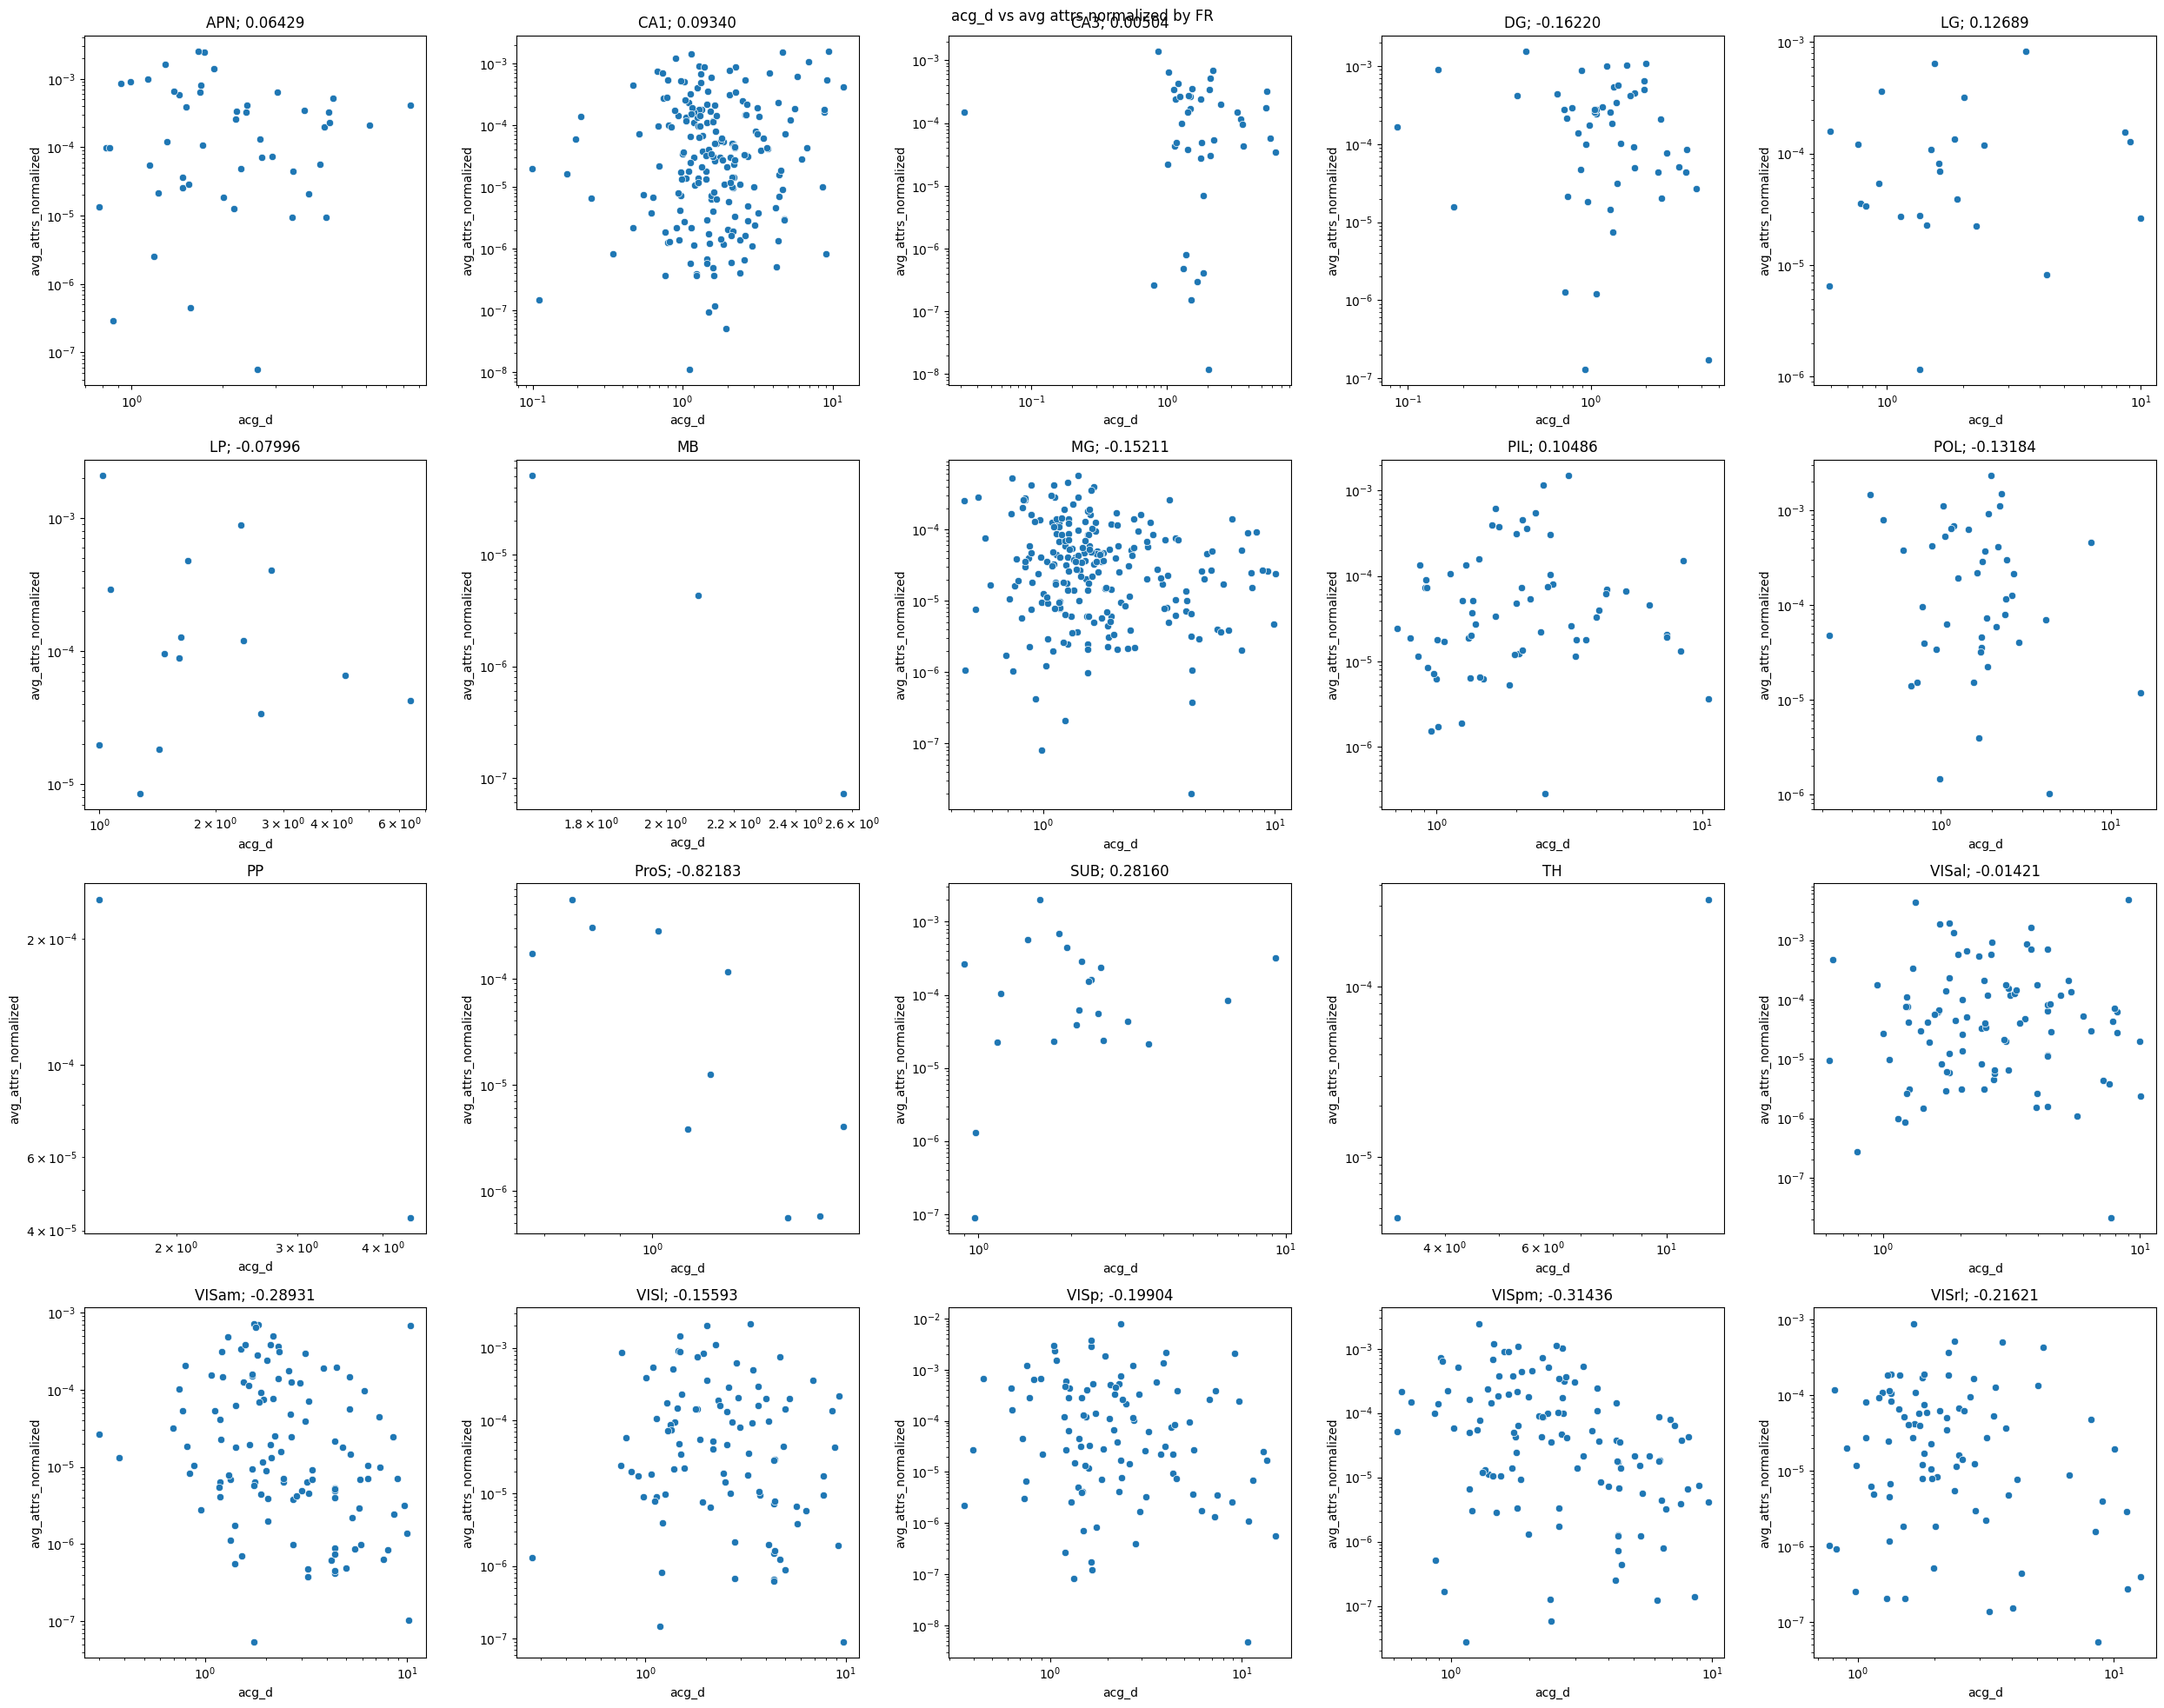

acg_tau_rise


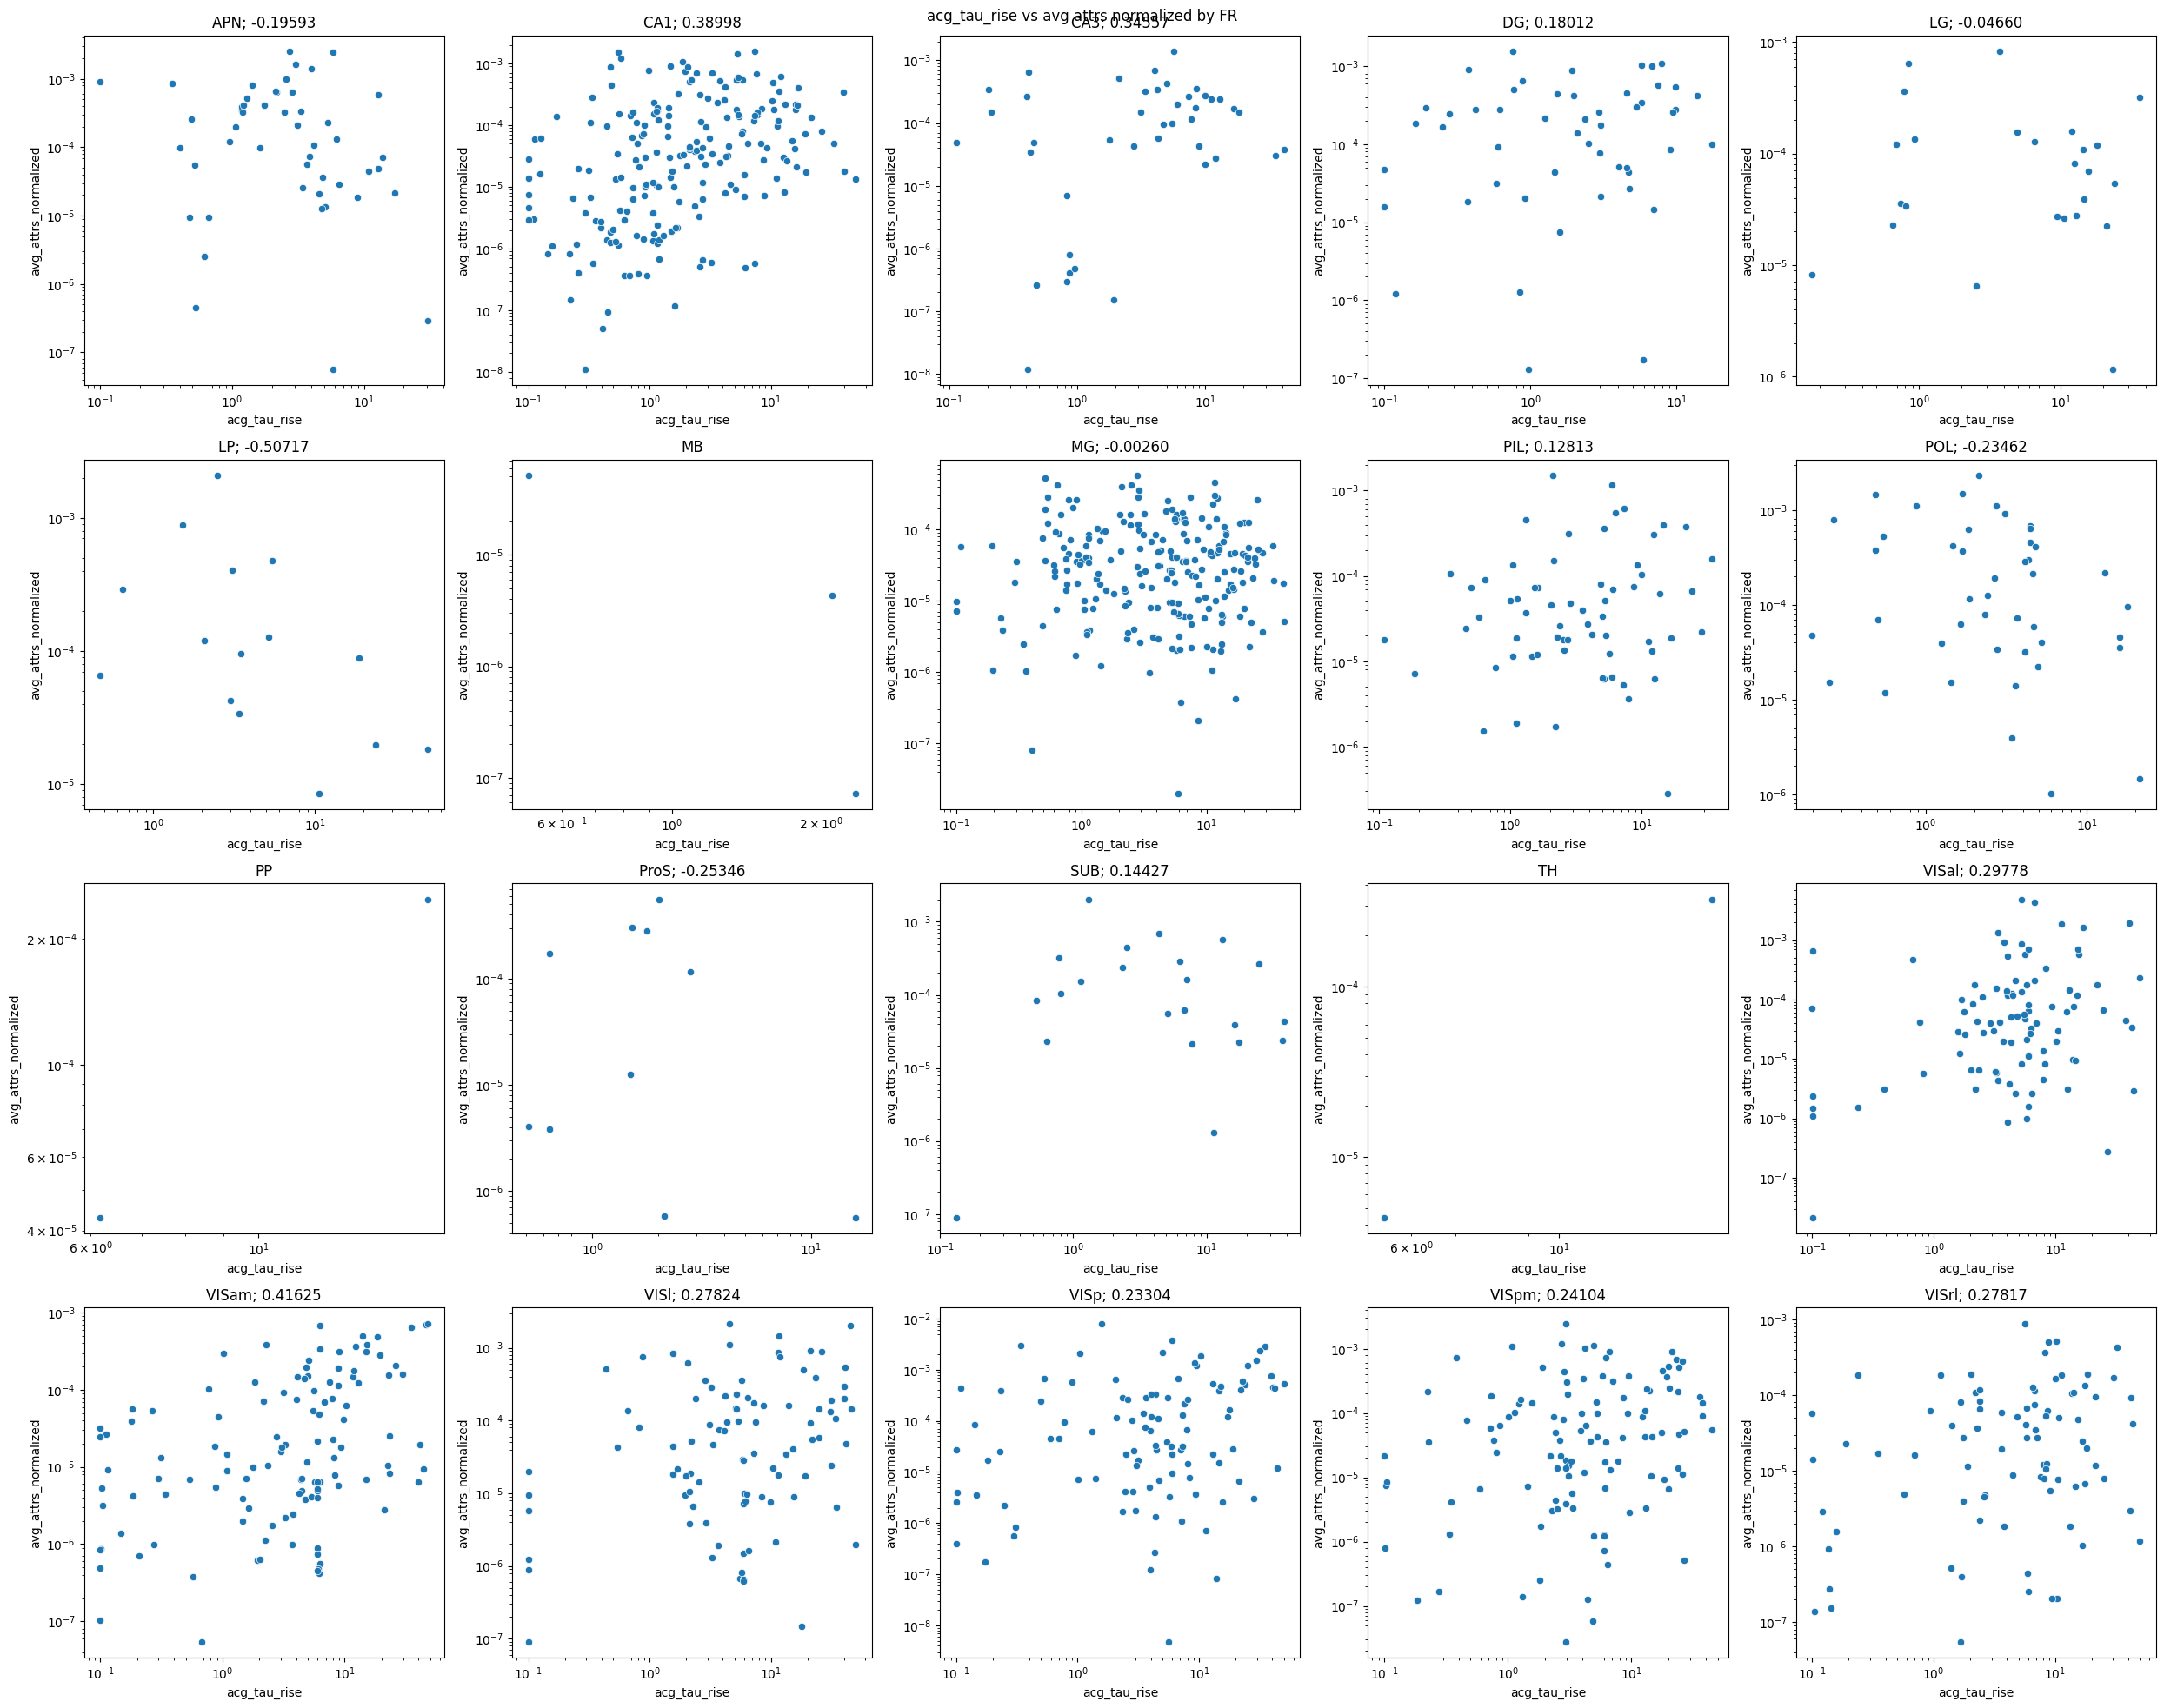

acg_tau_decay


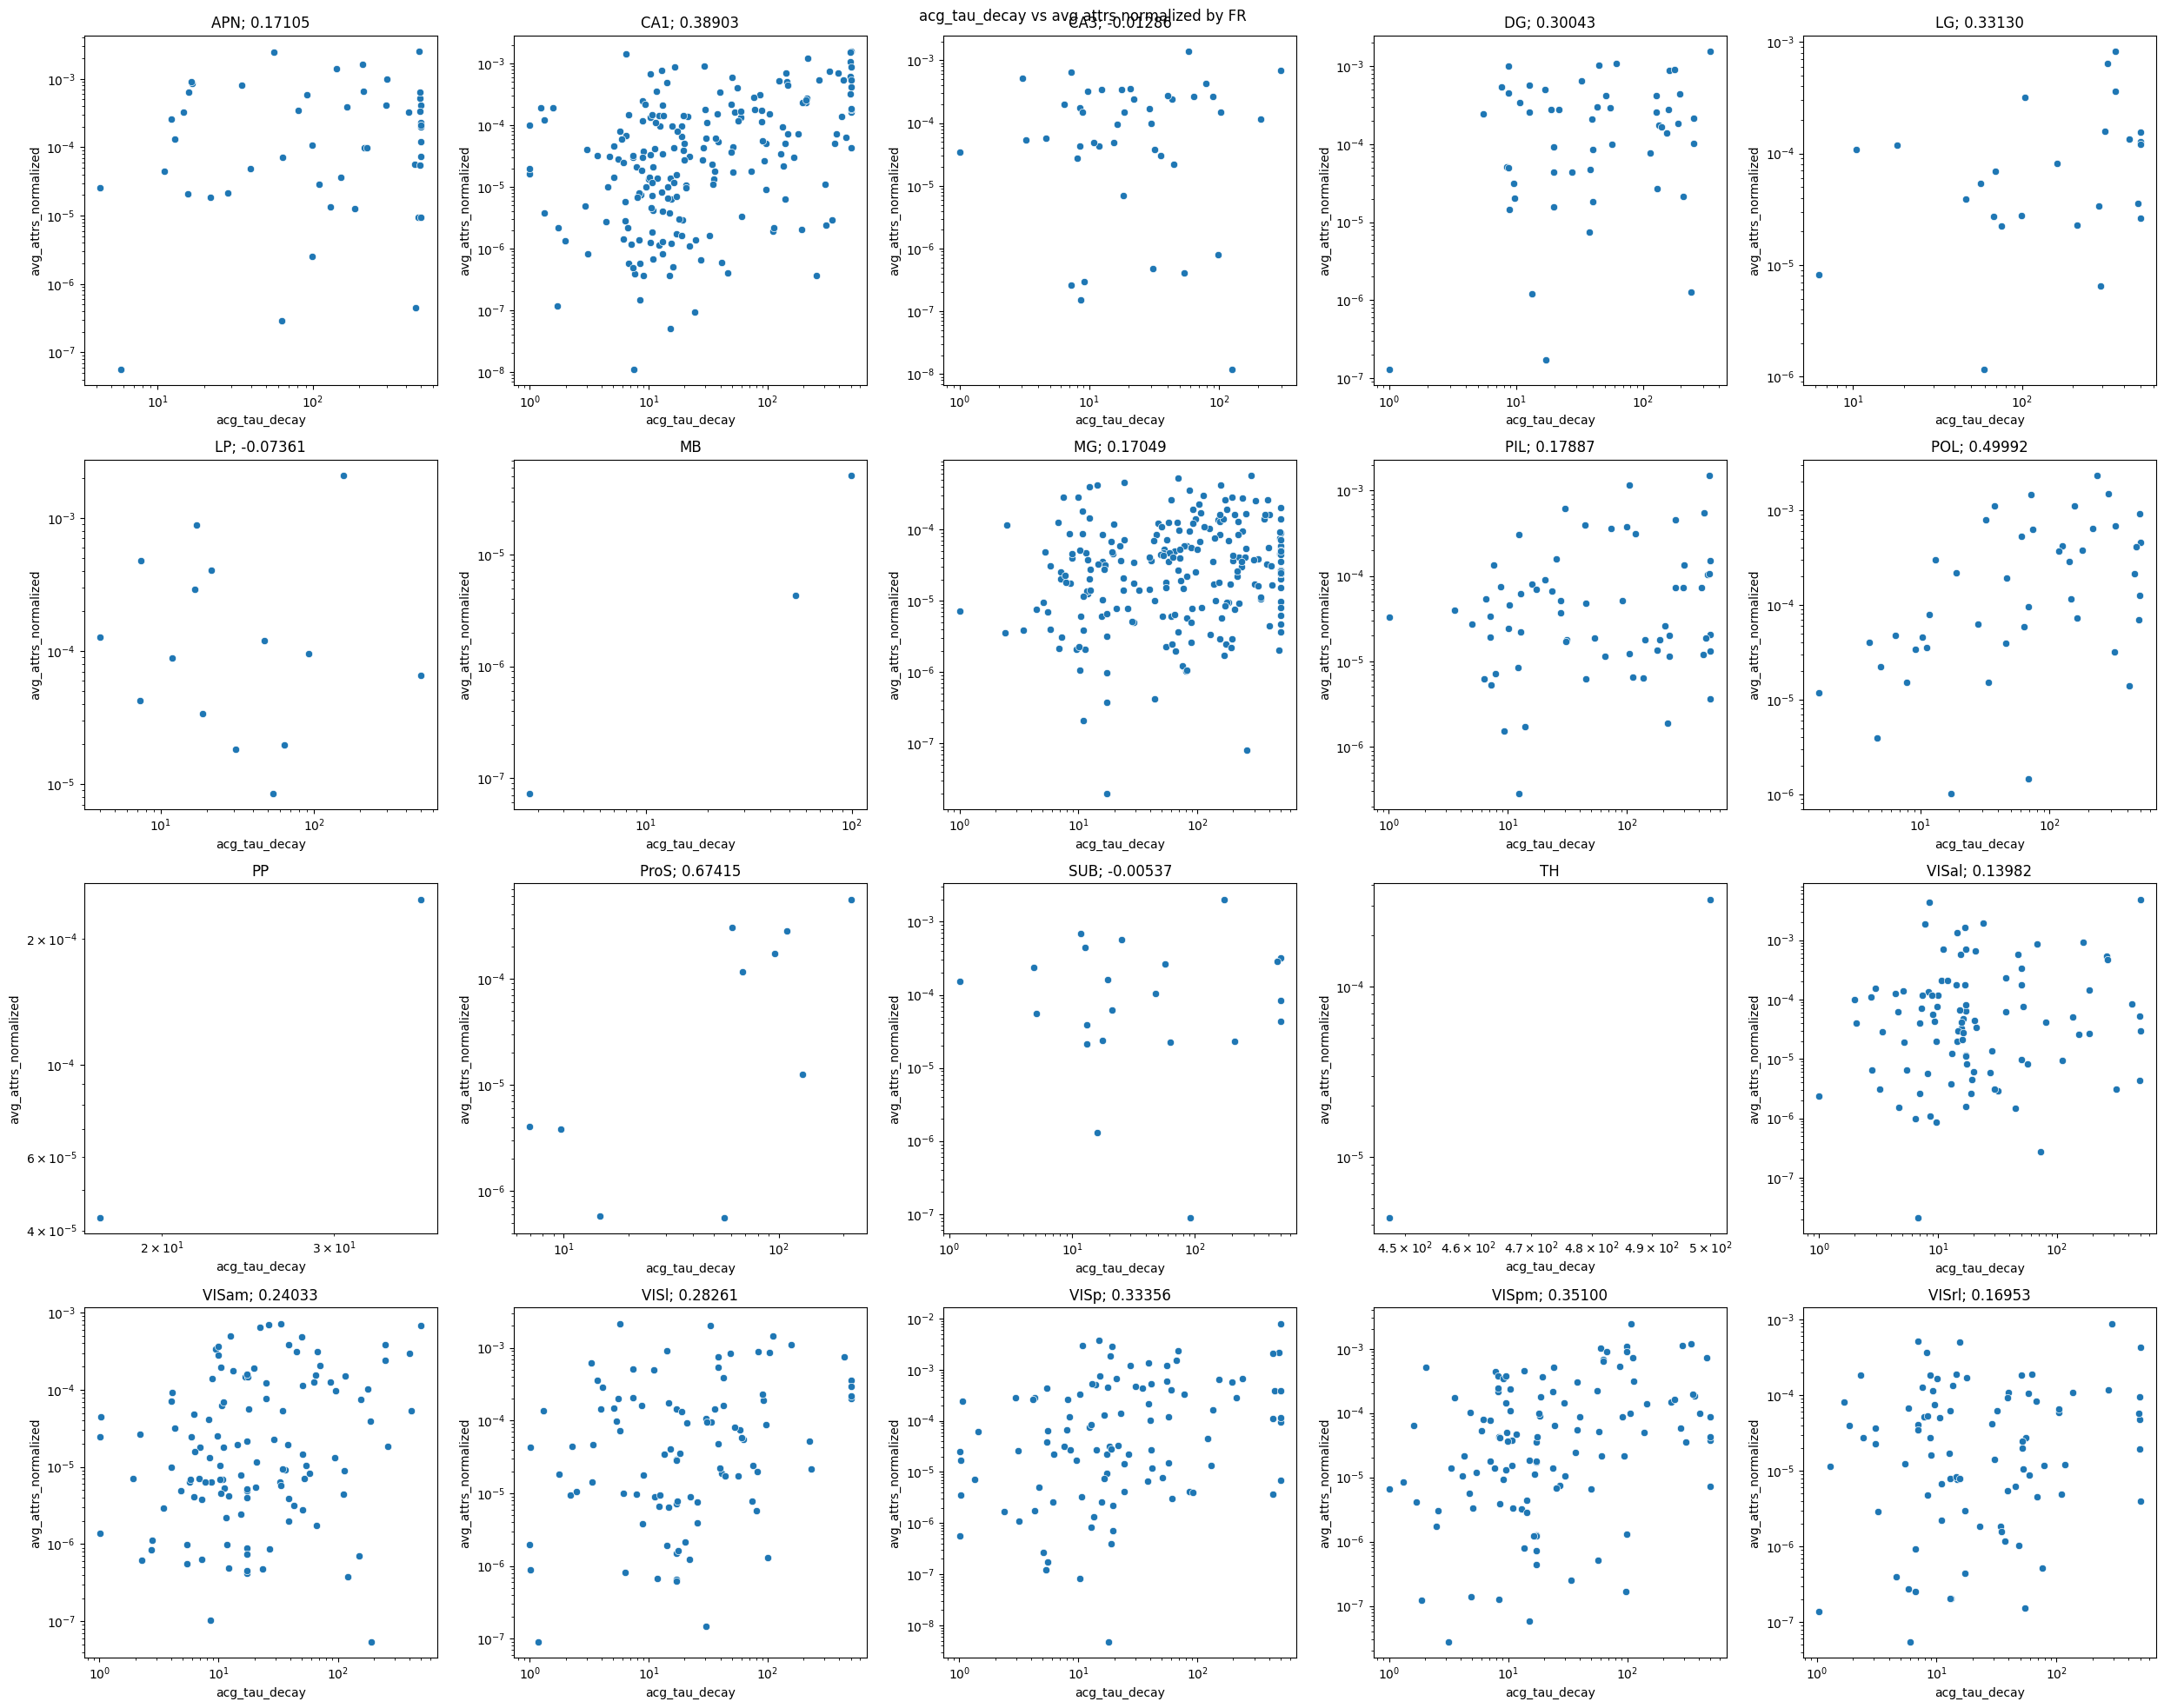

firingRateISI


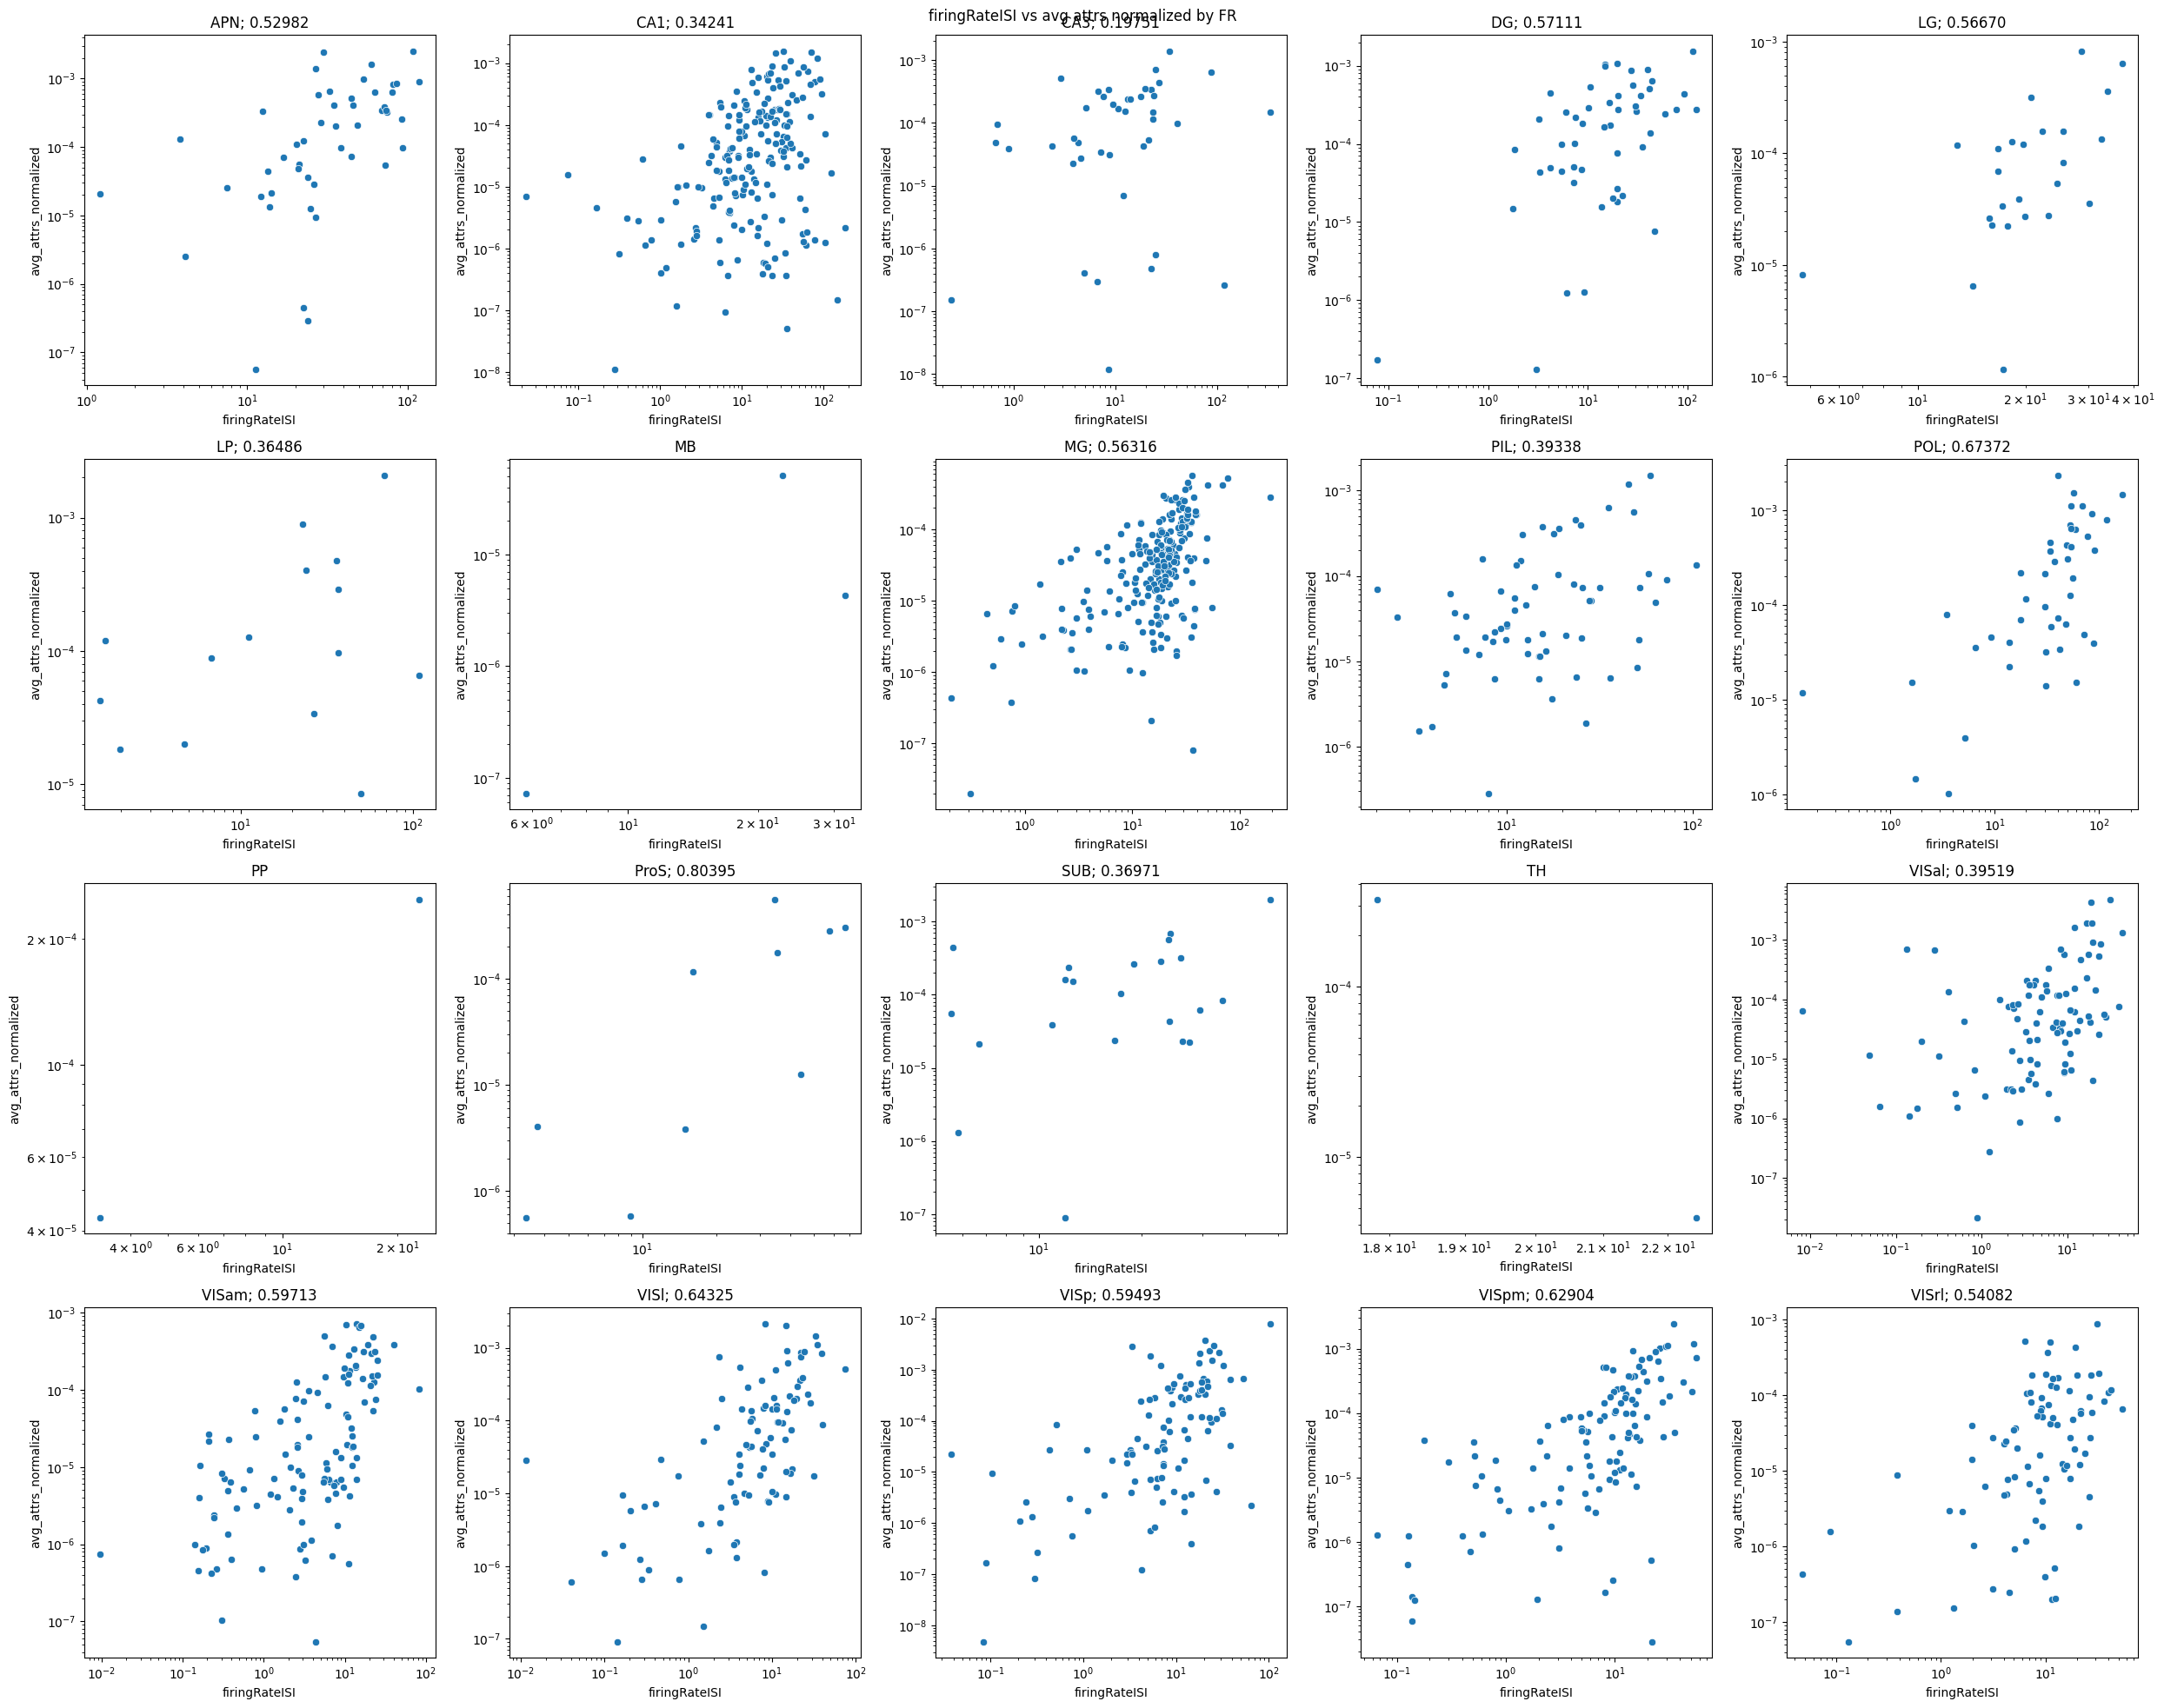

coupling_index


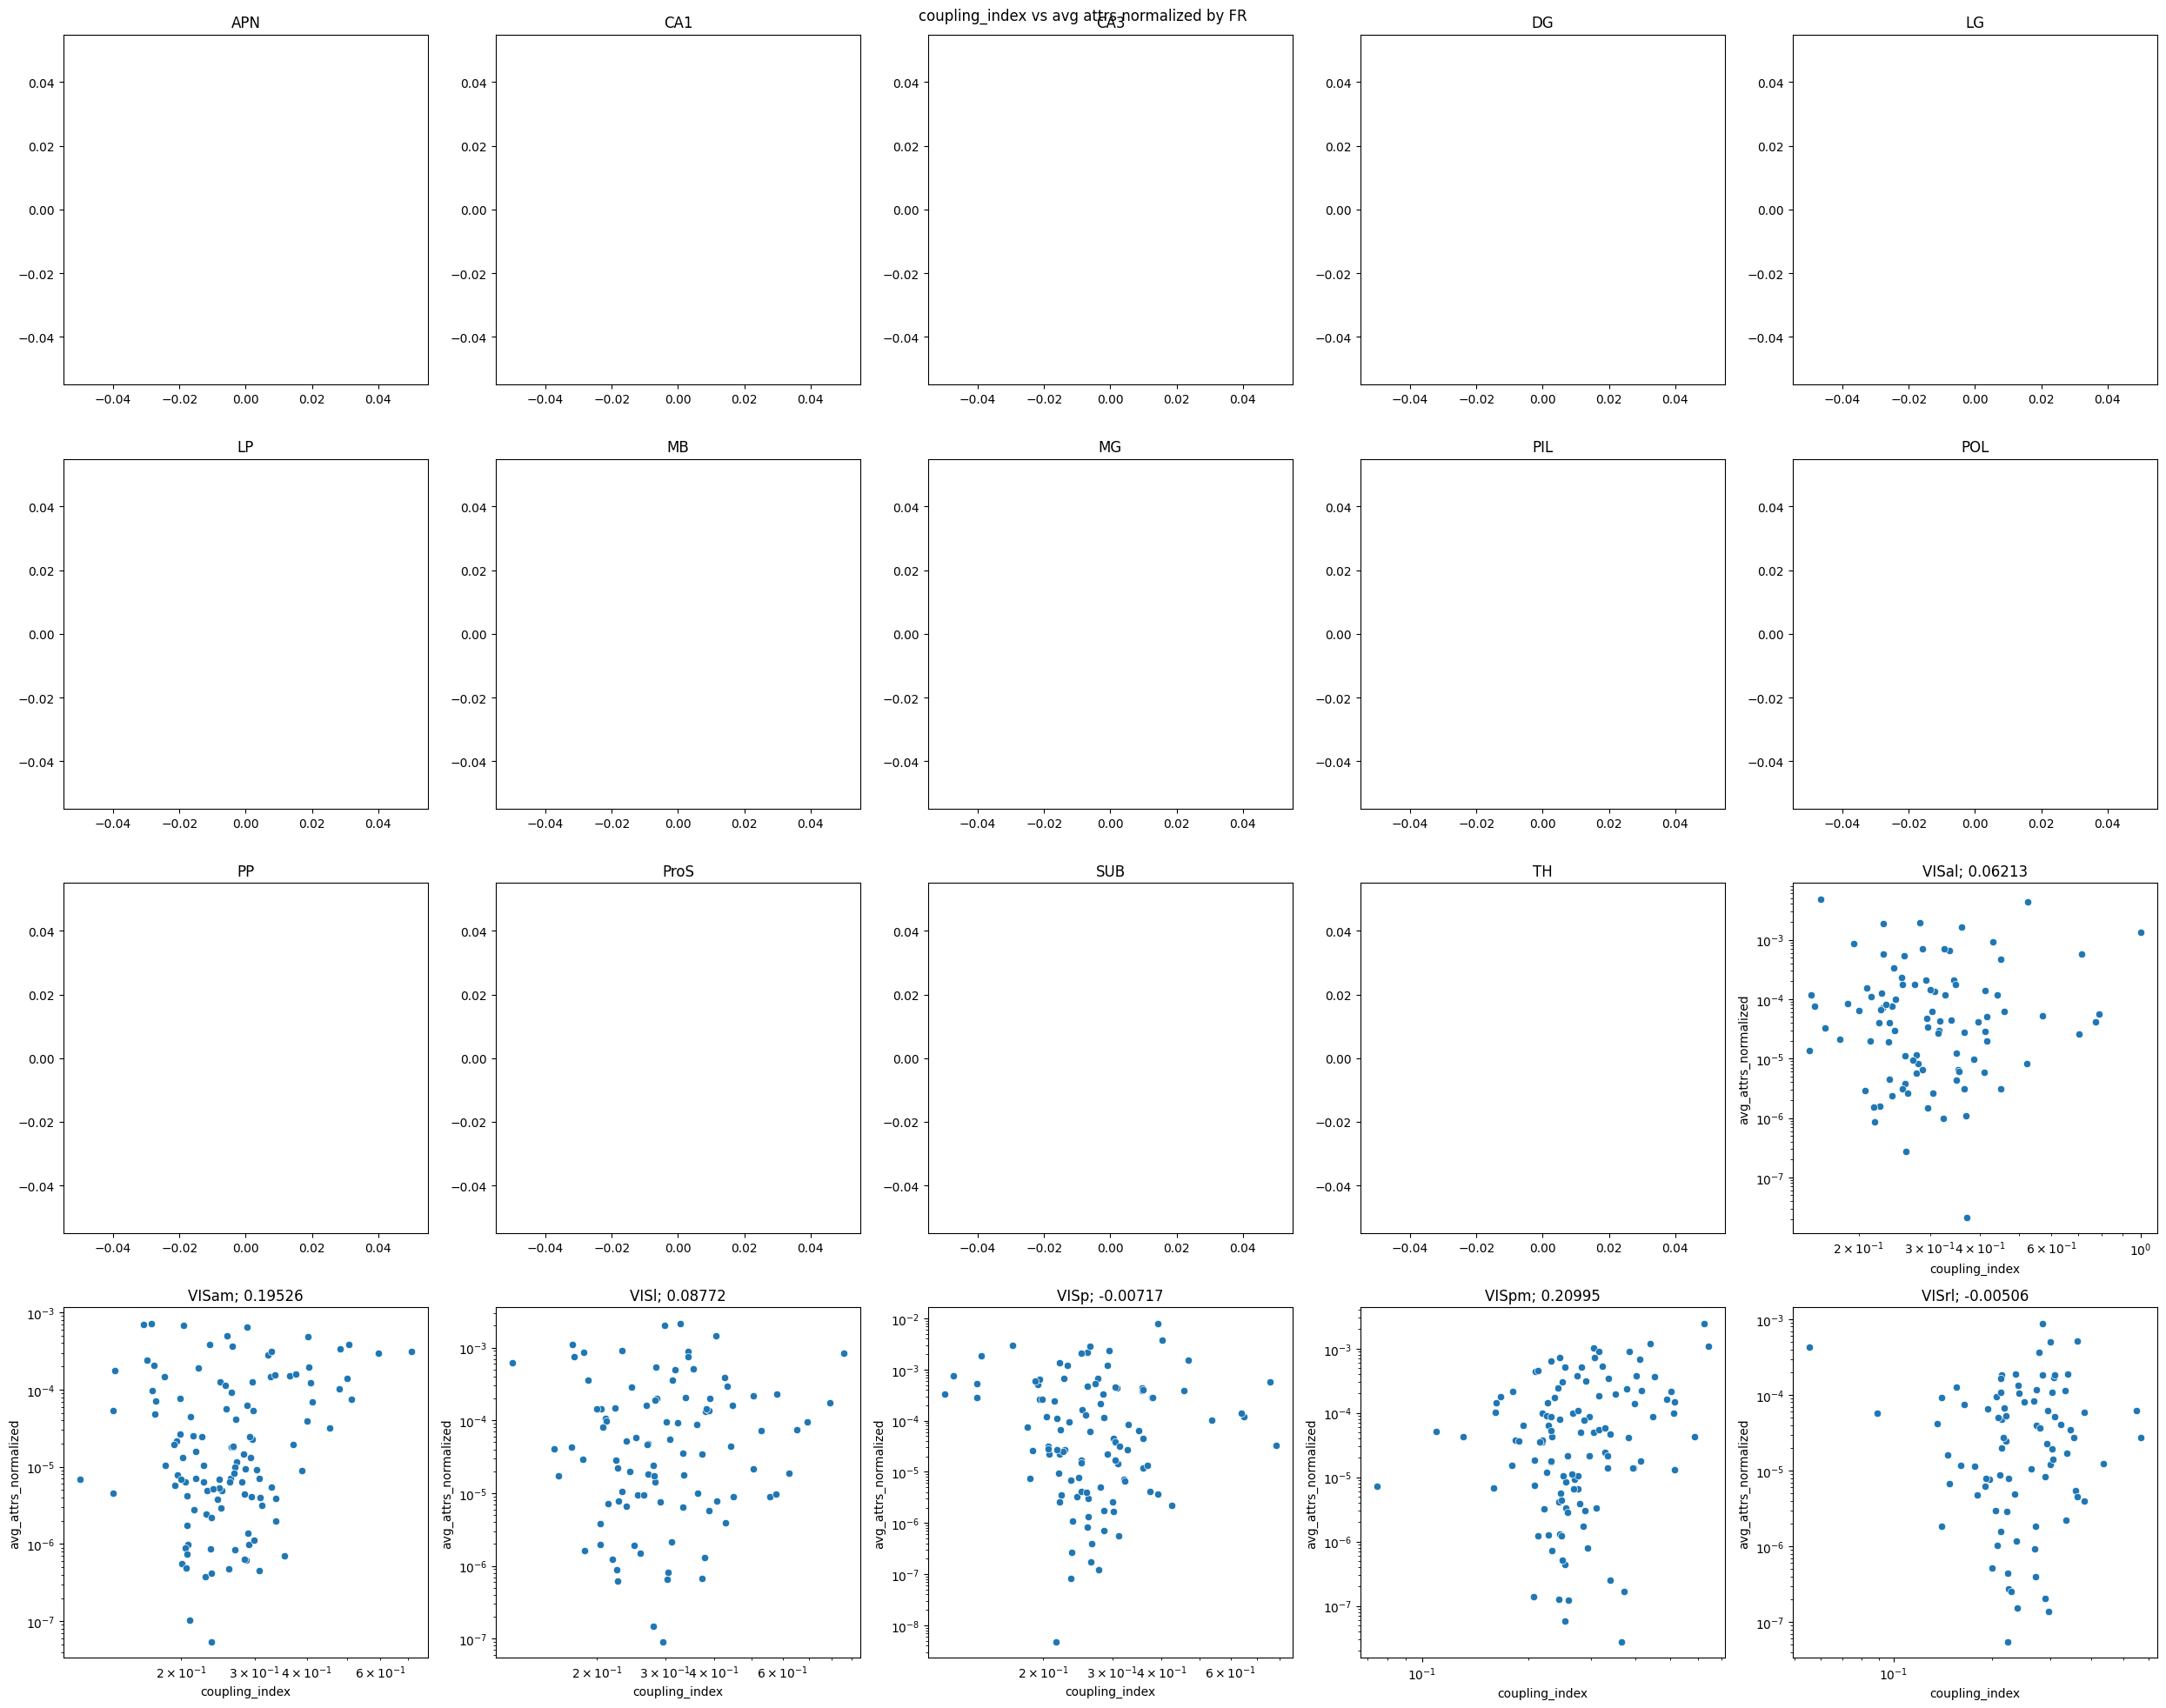

normalized_depth


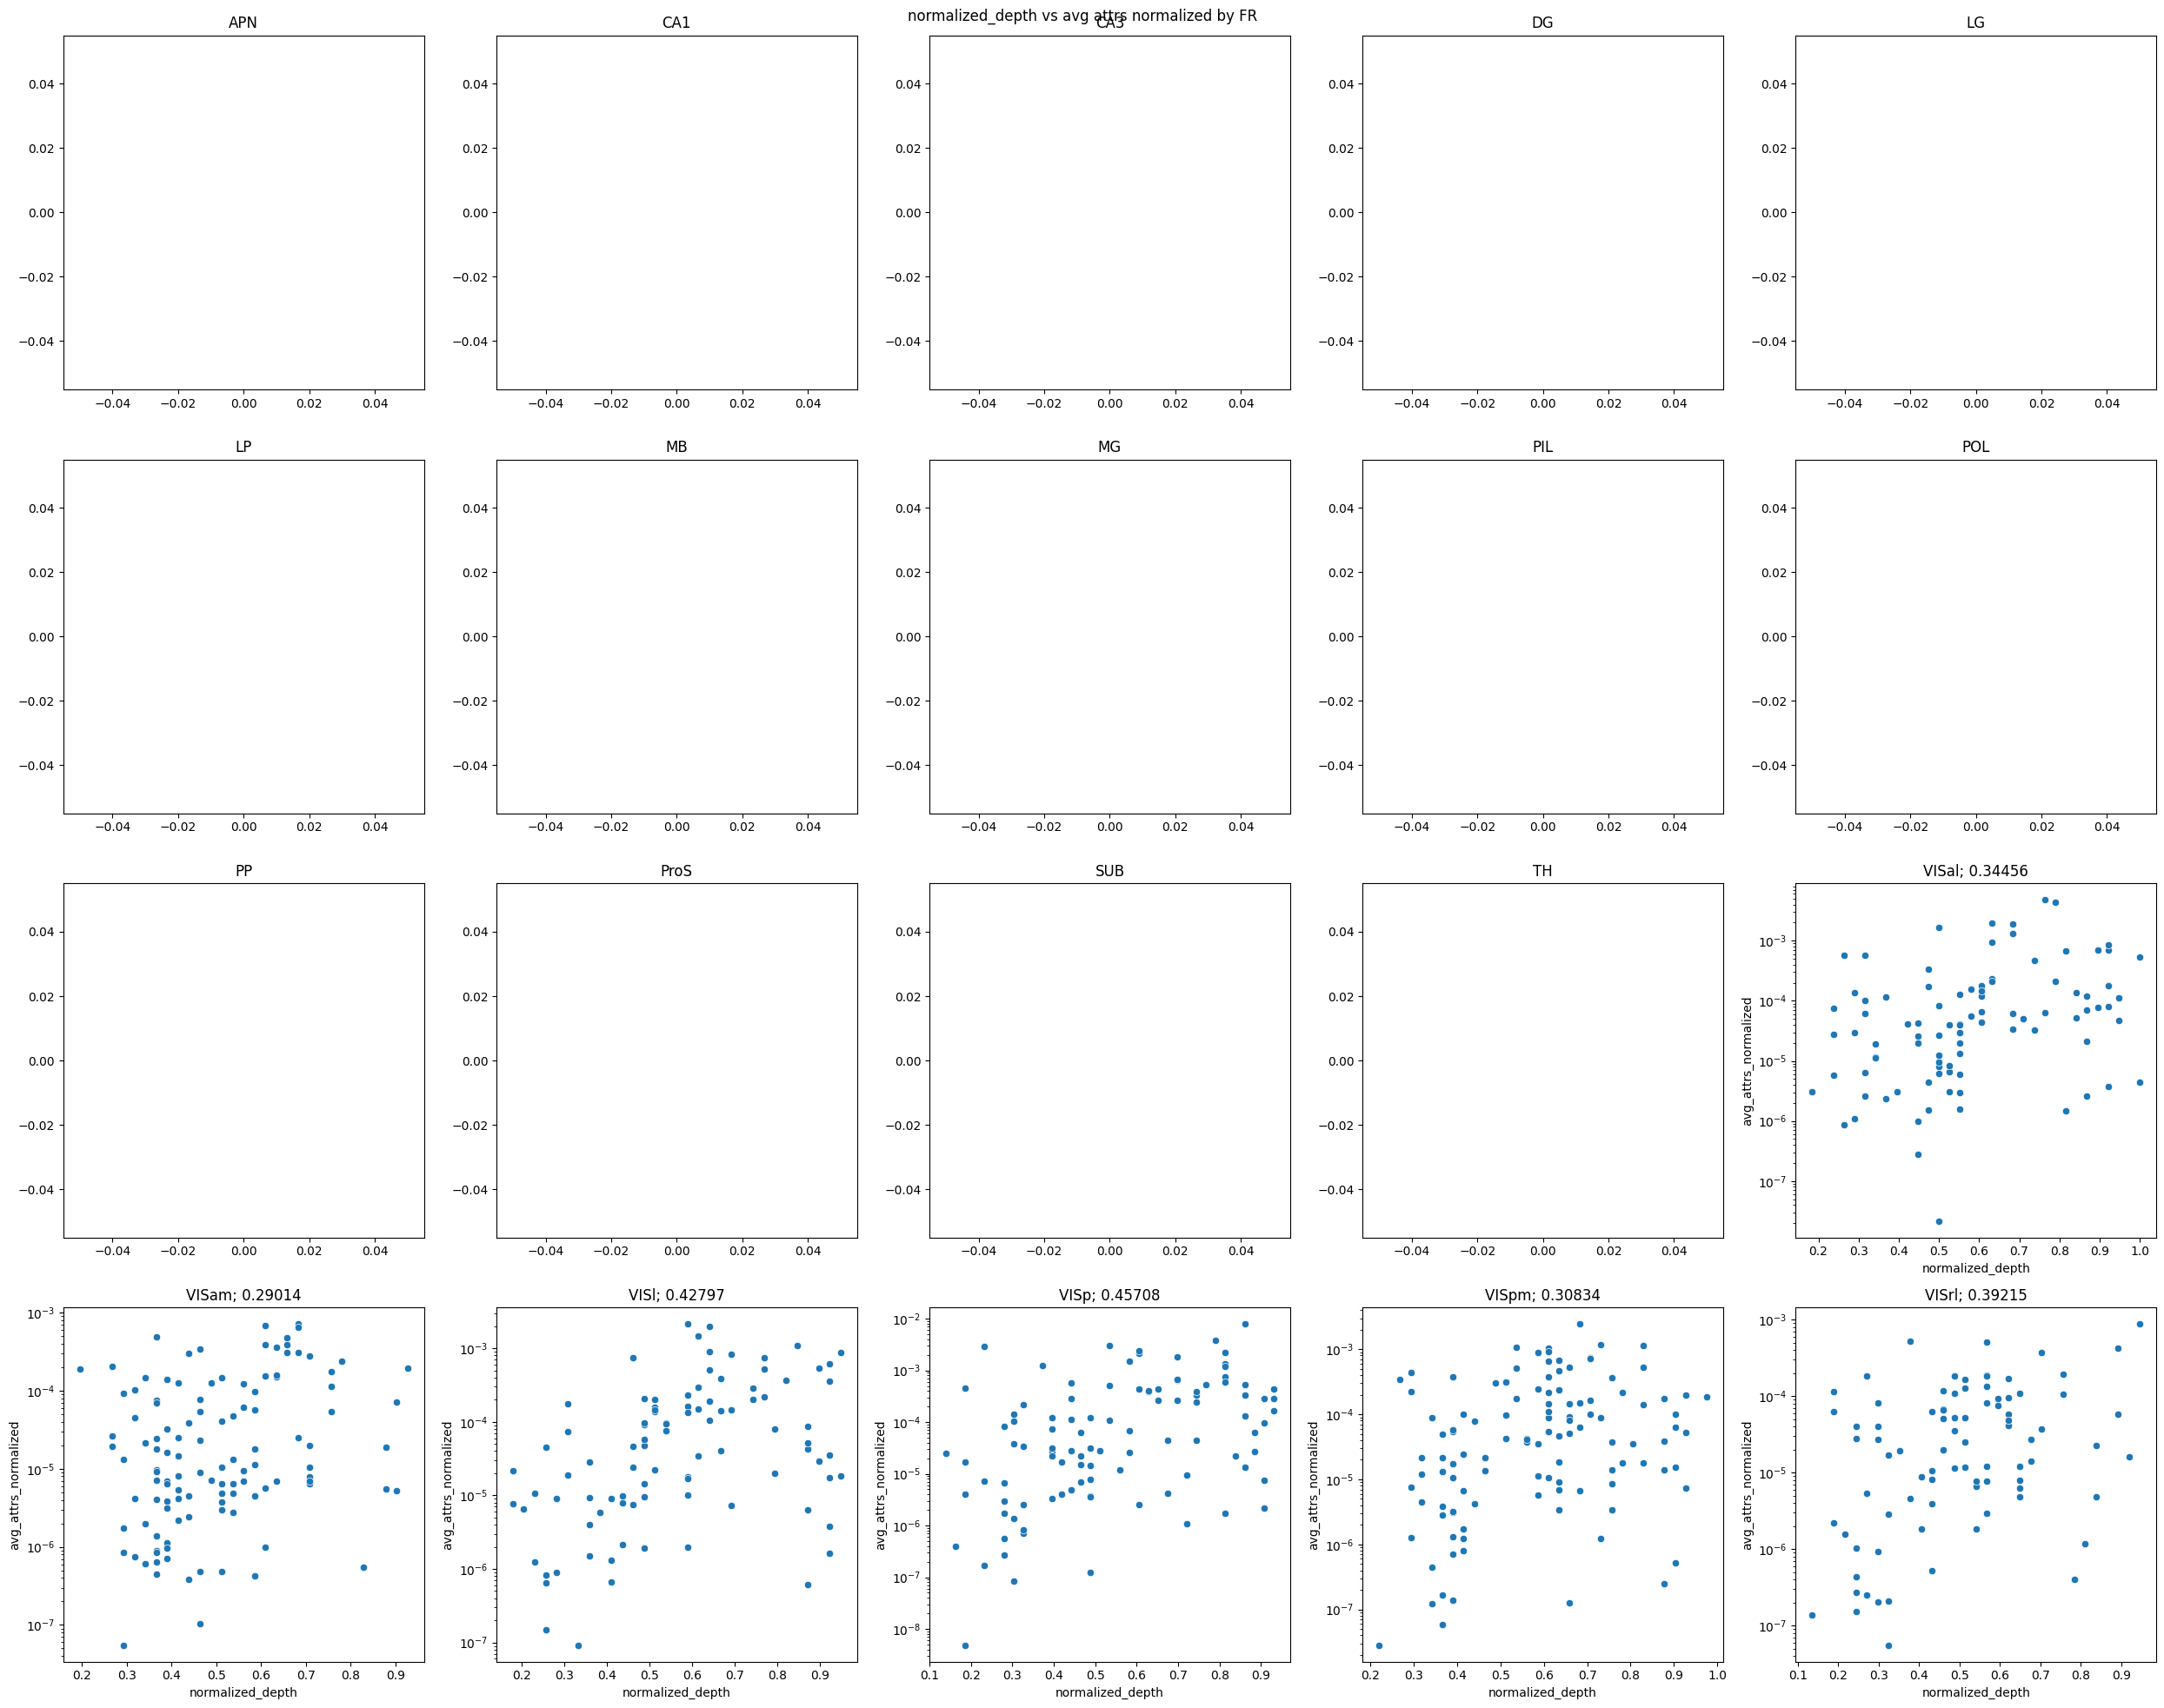

thetaModulationIndex


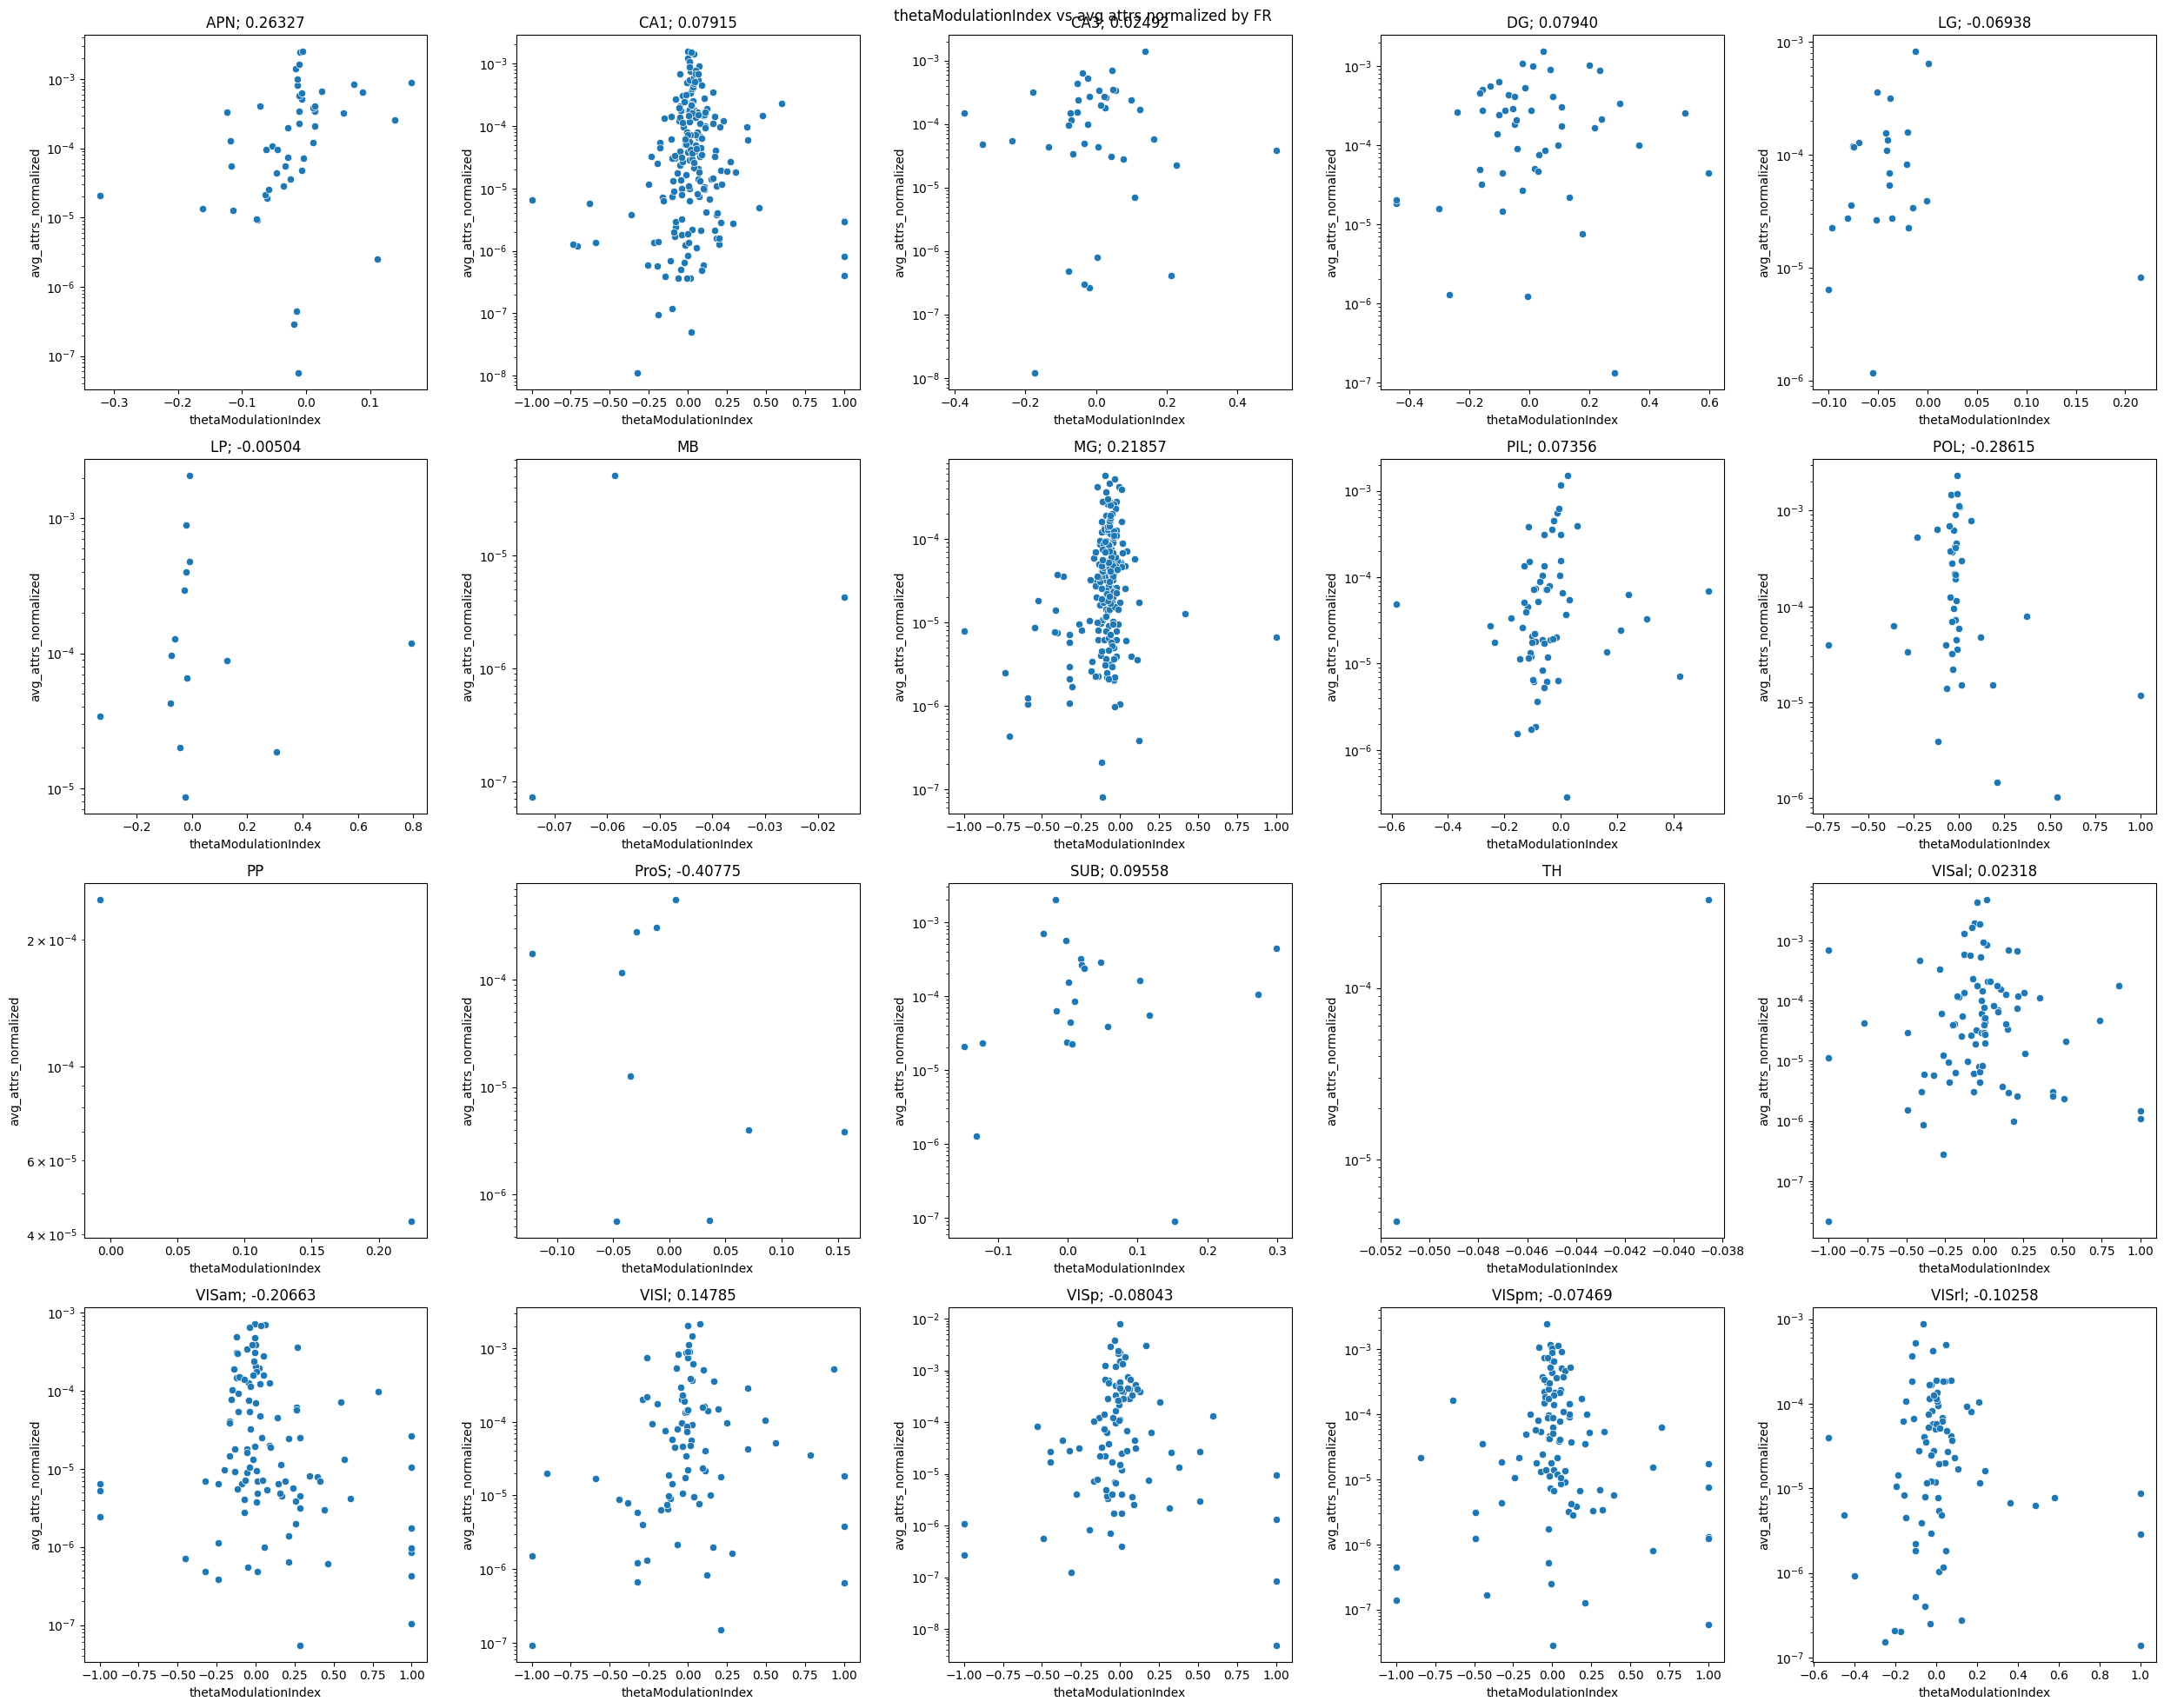

burstIndex_Royer2012


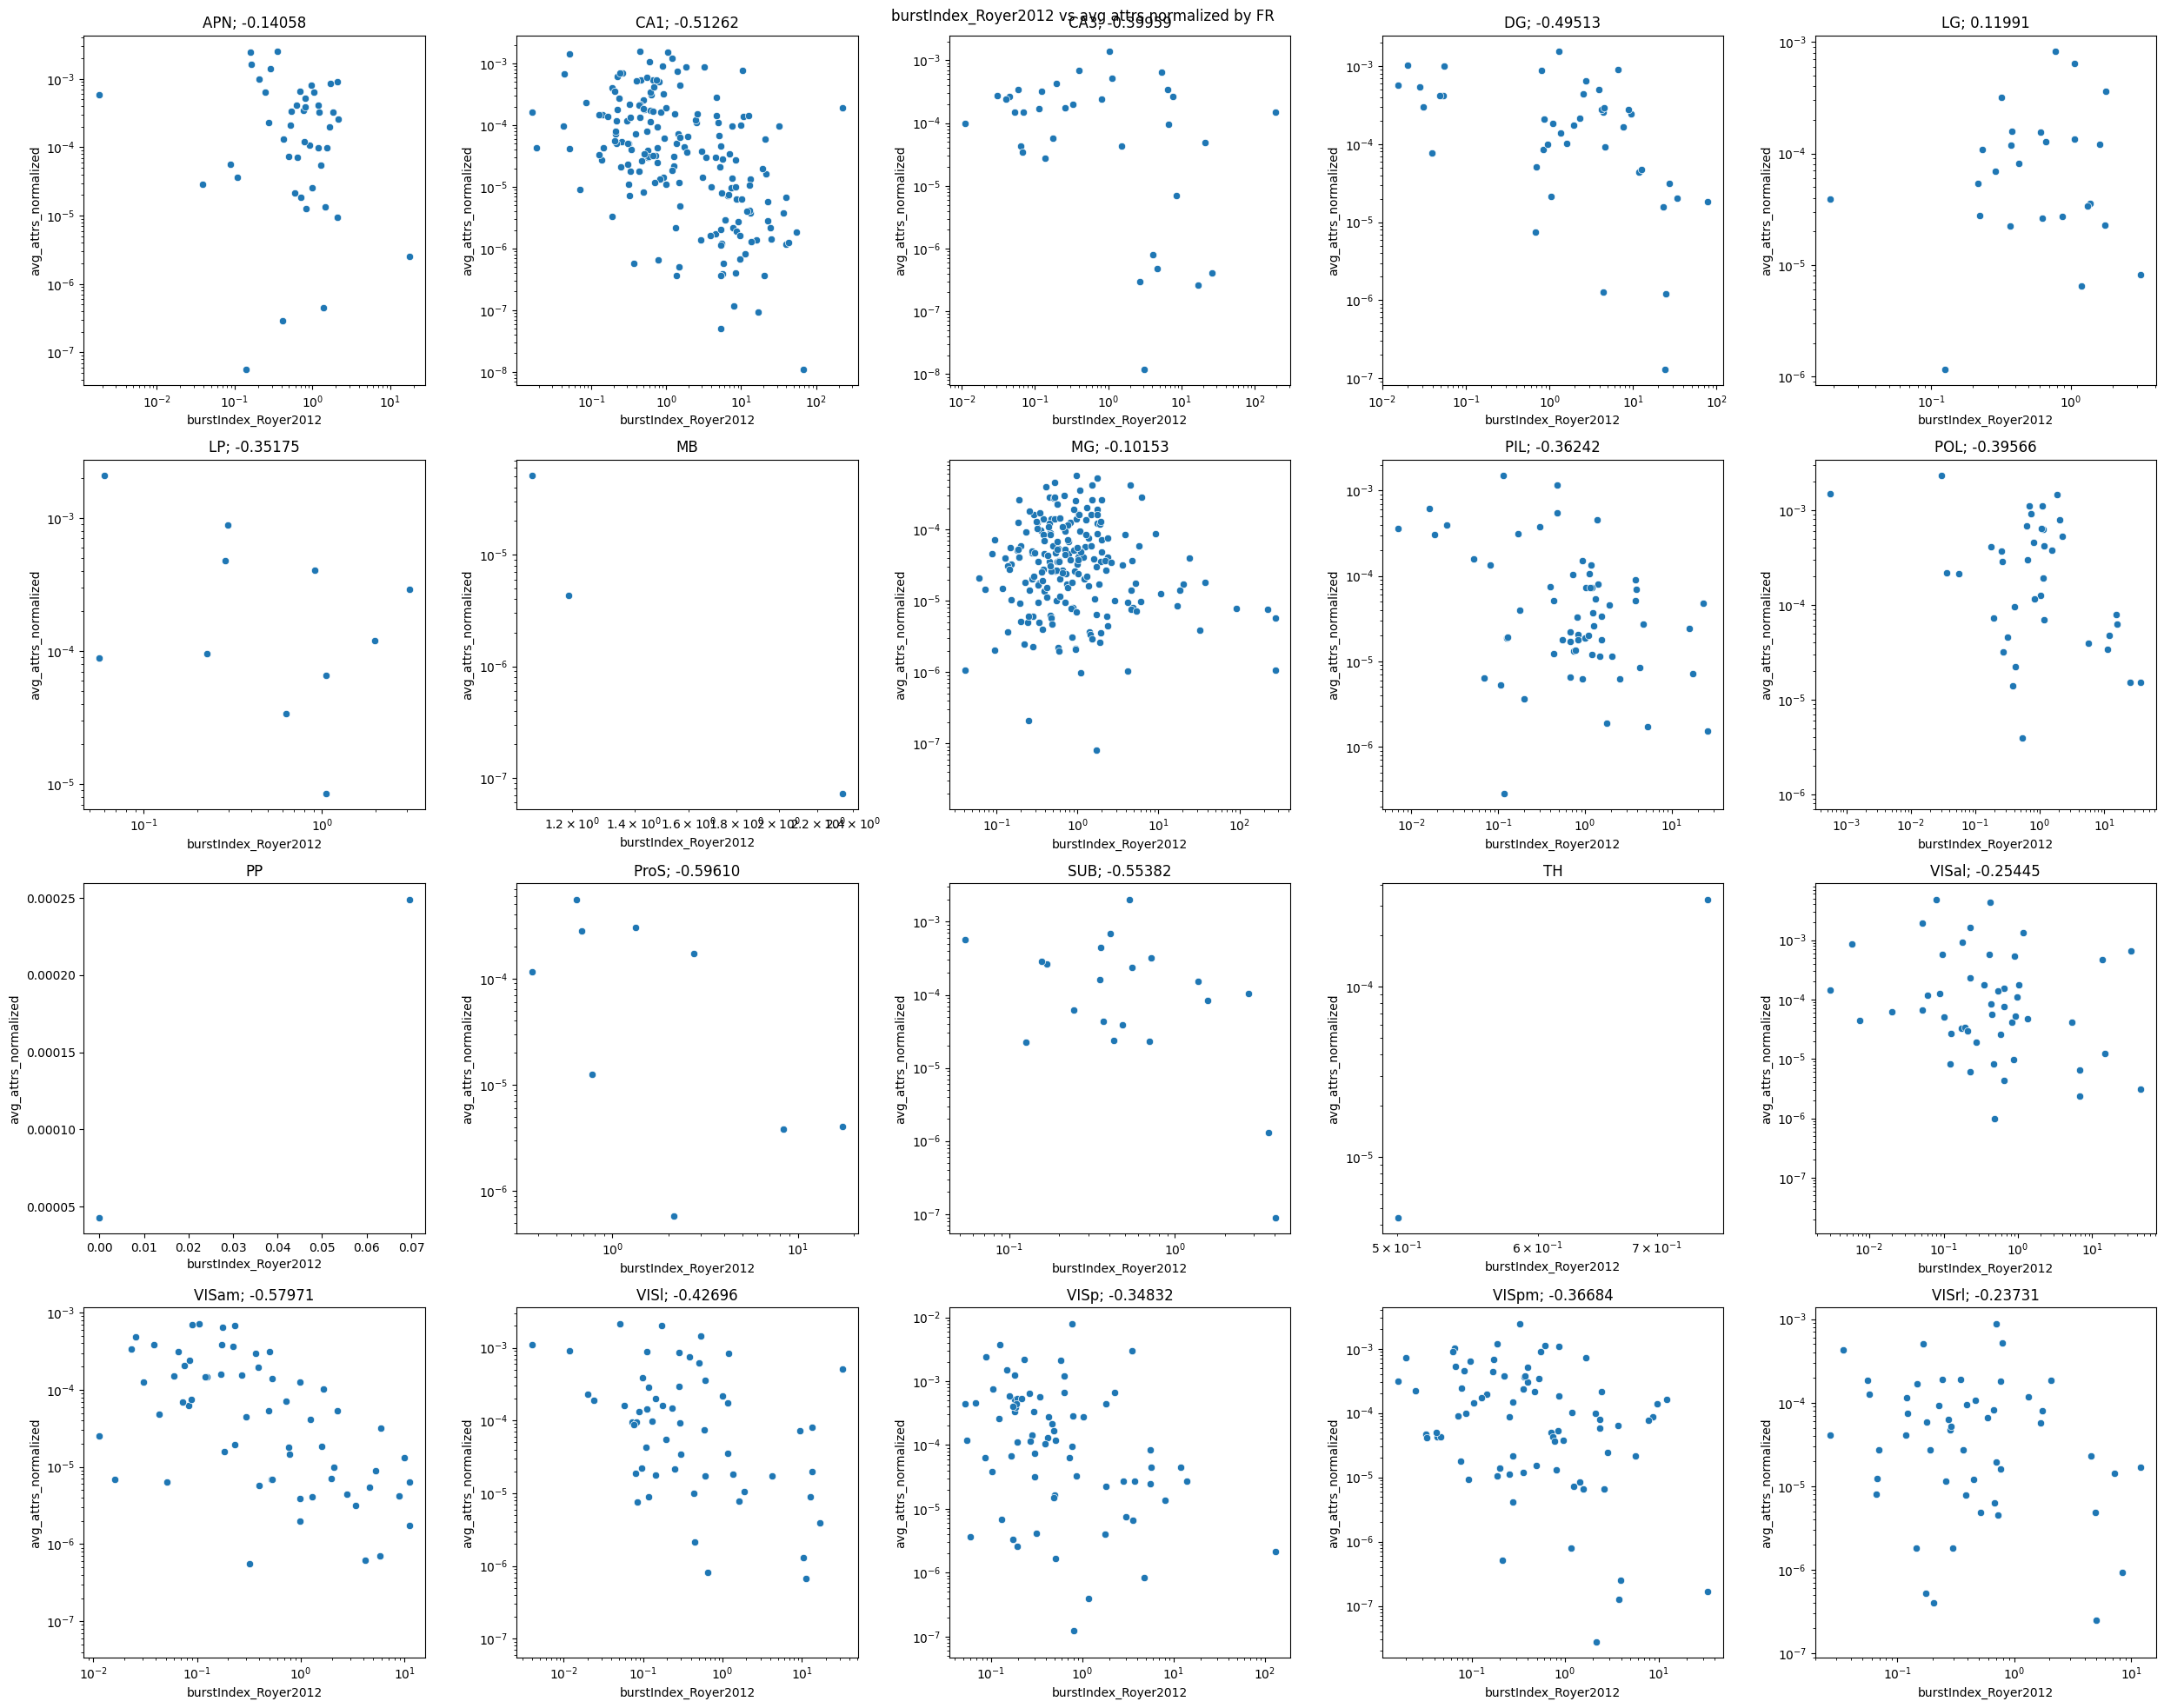

burstIndex_Mizuseki2012


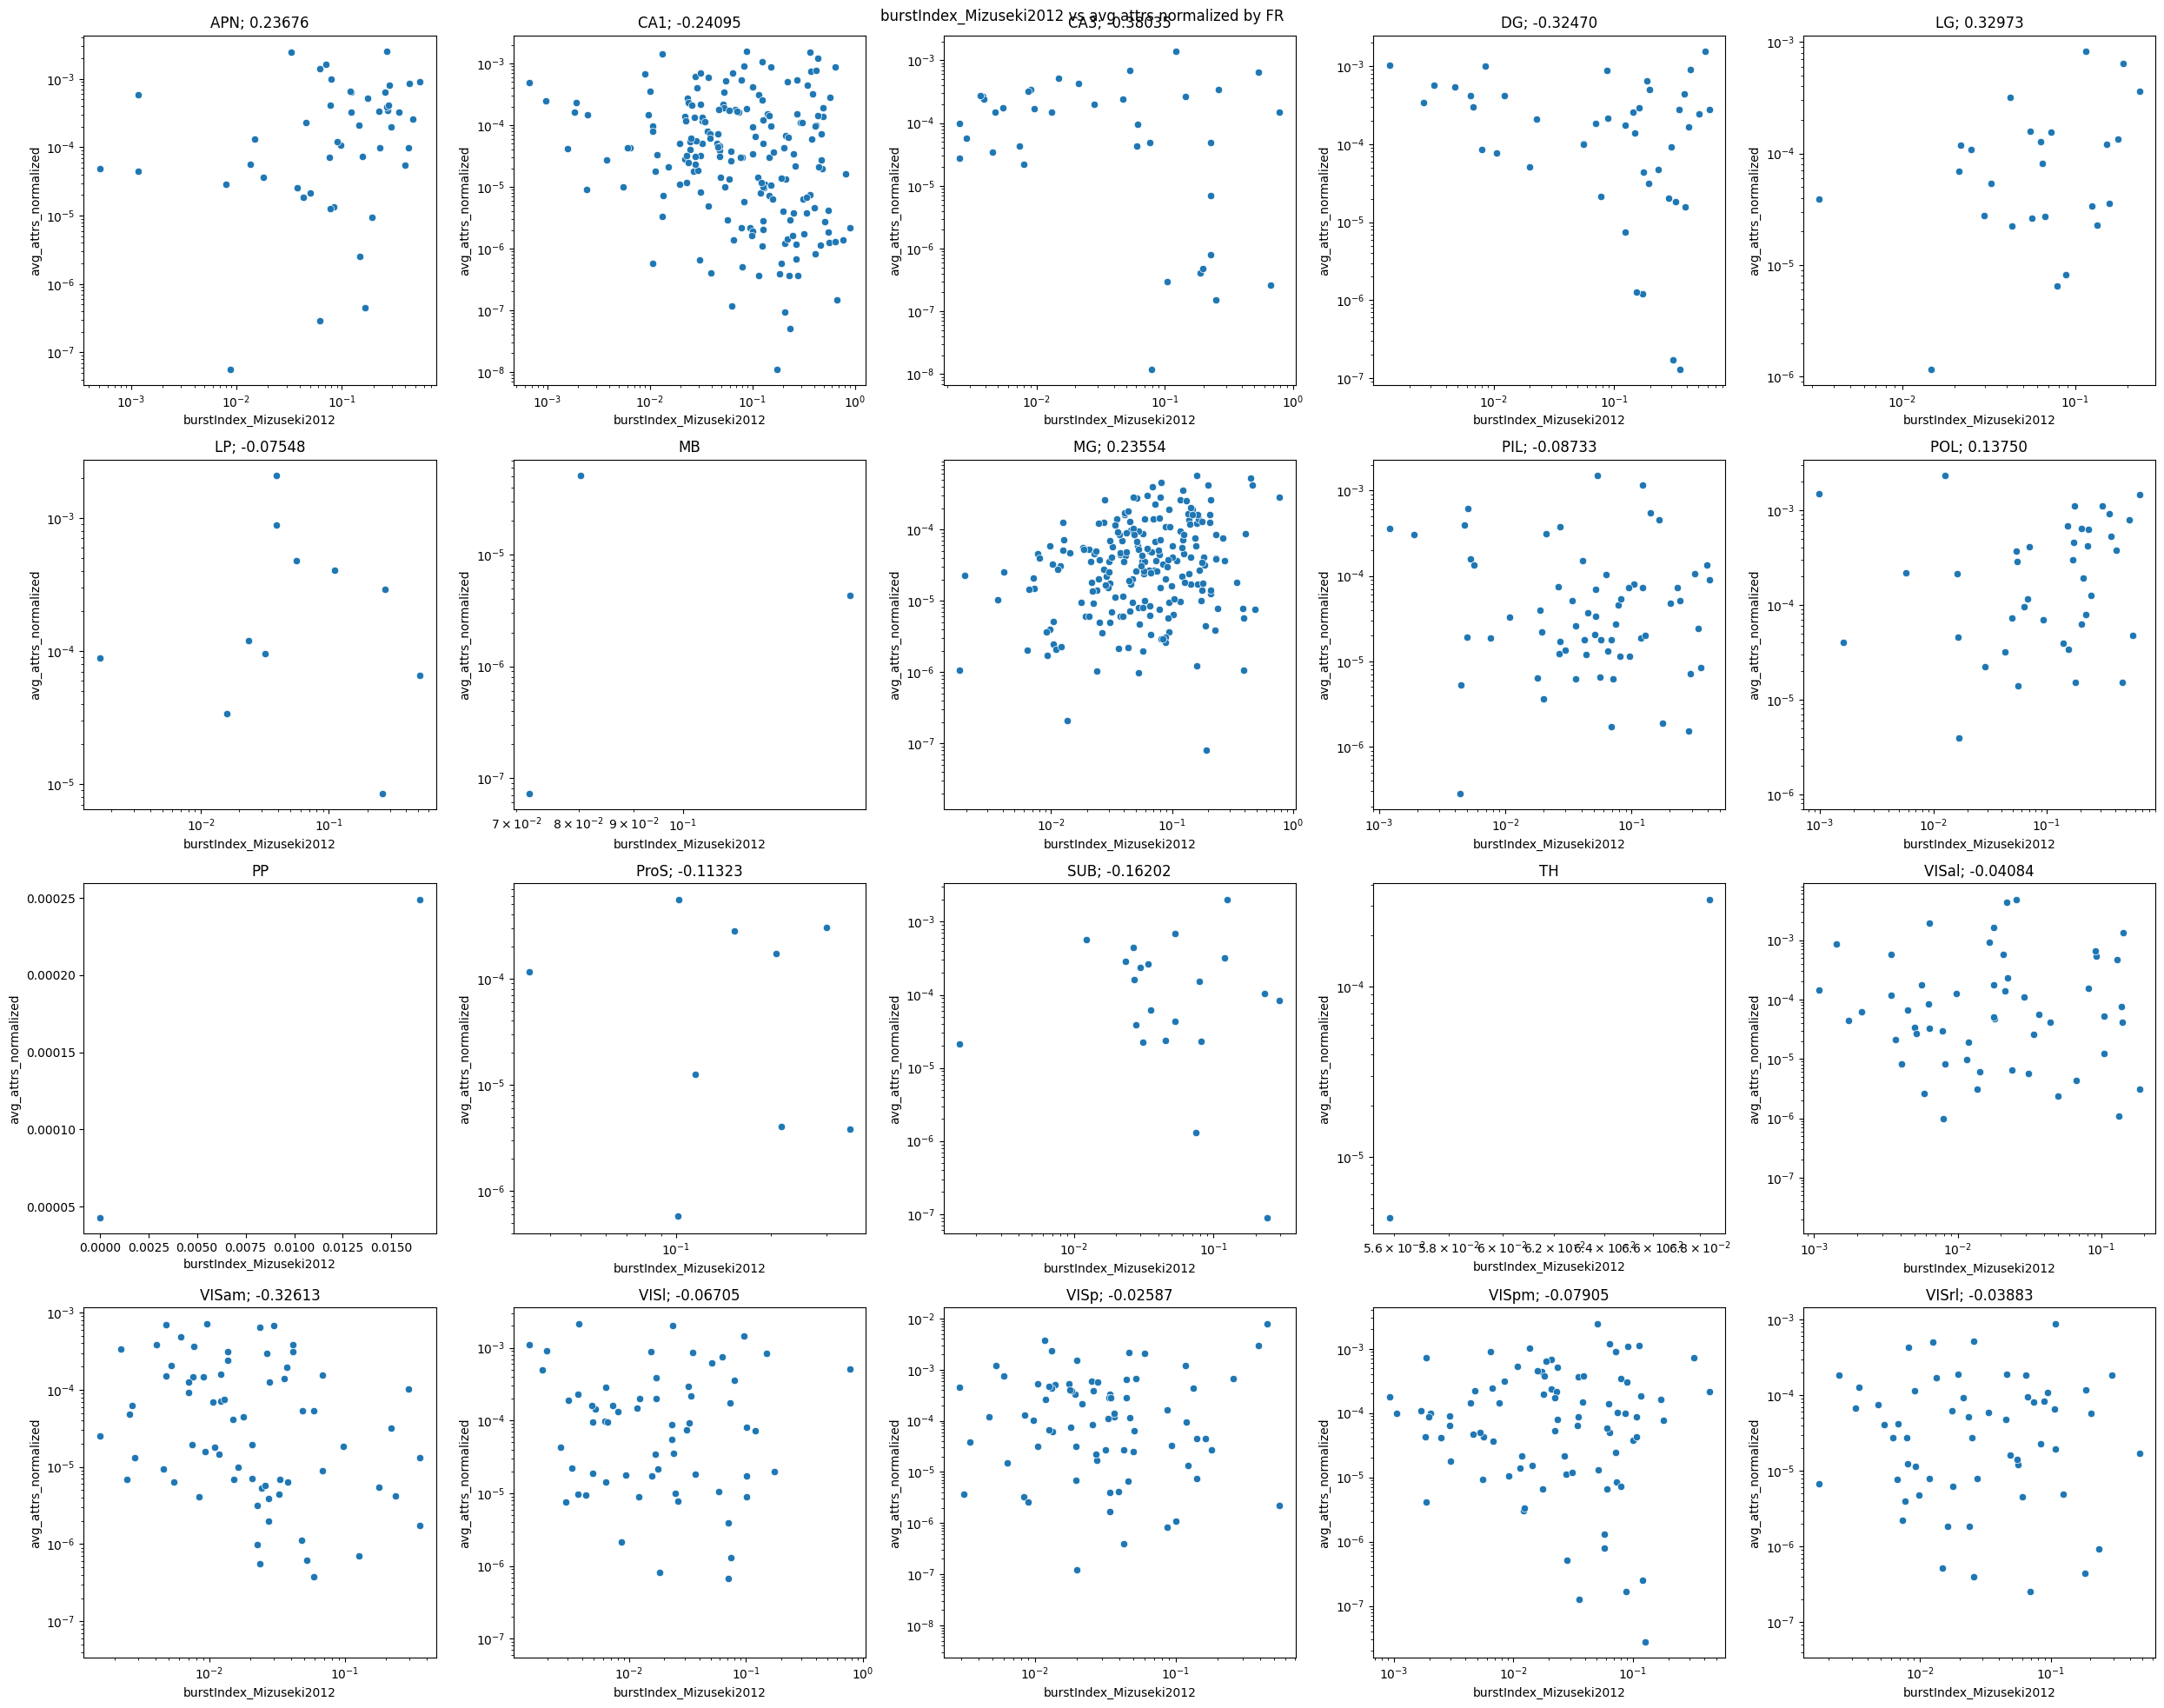

stLFP


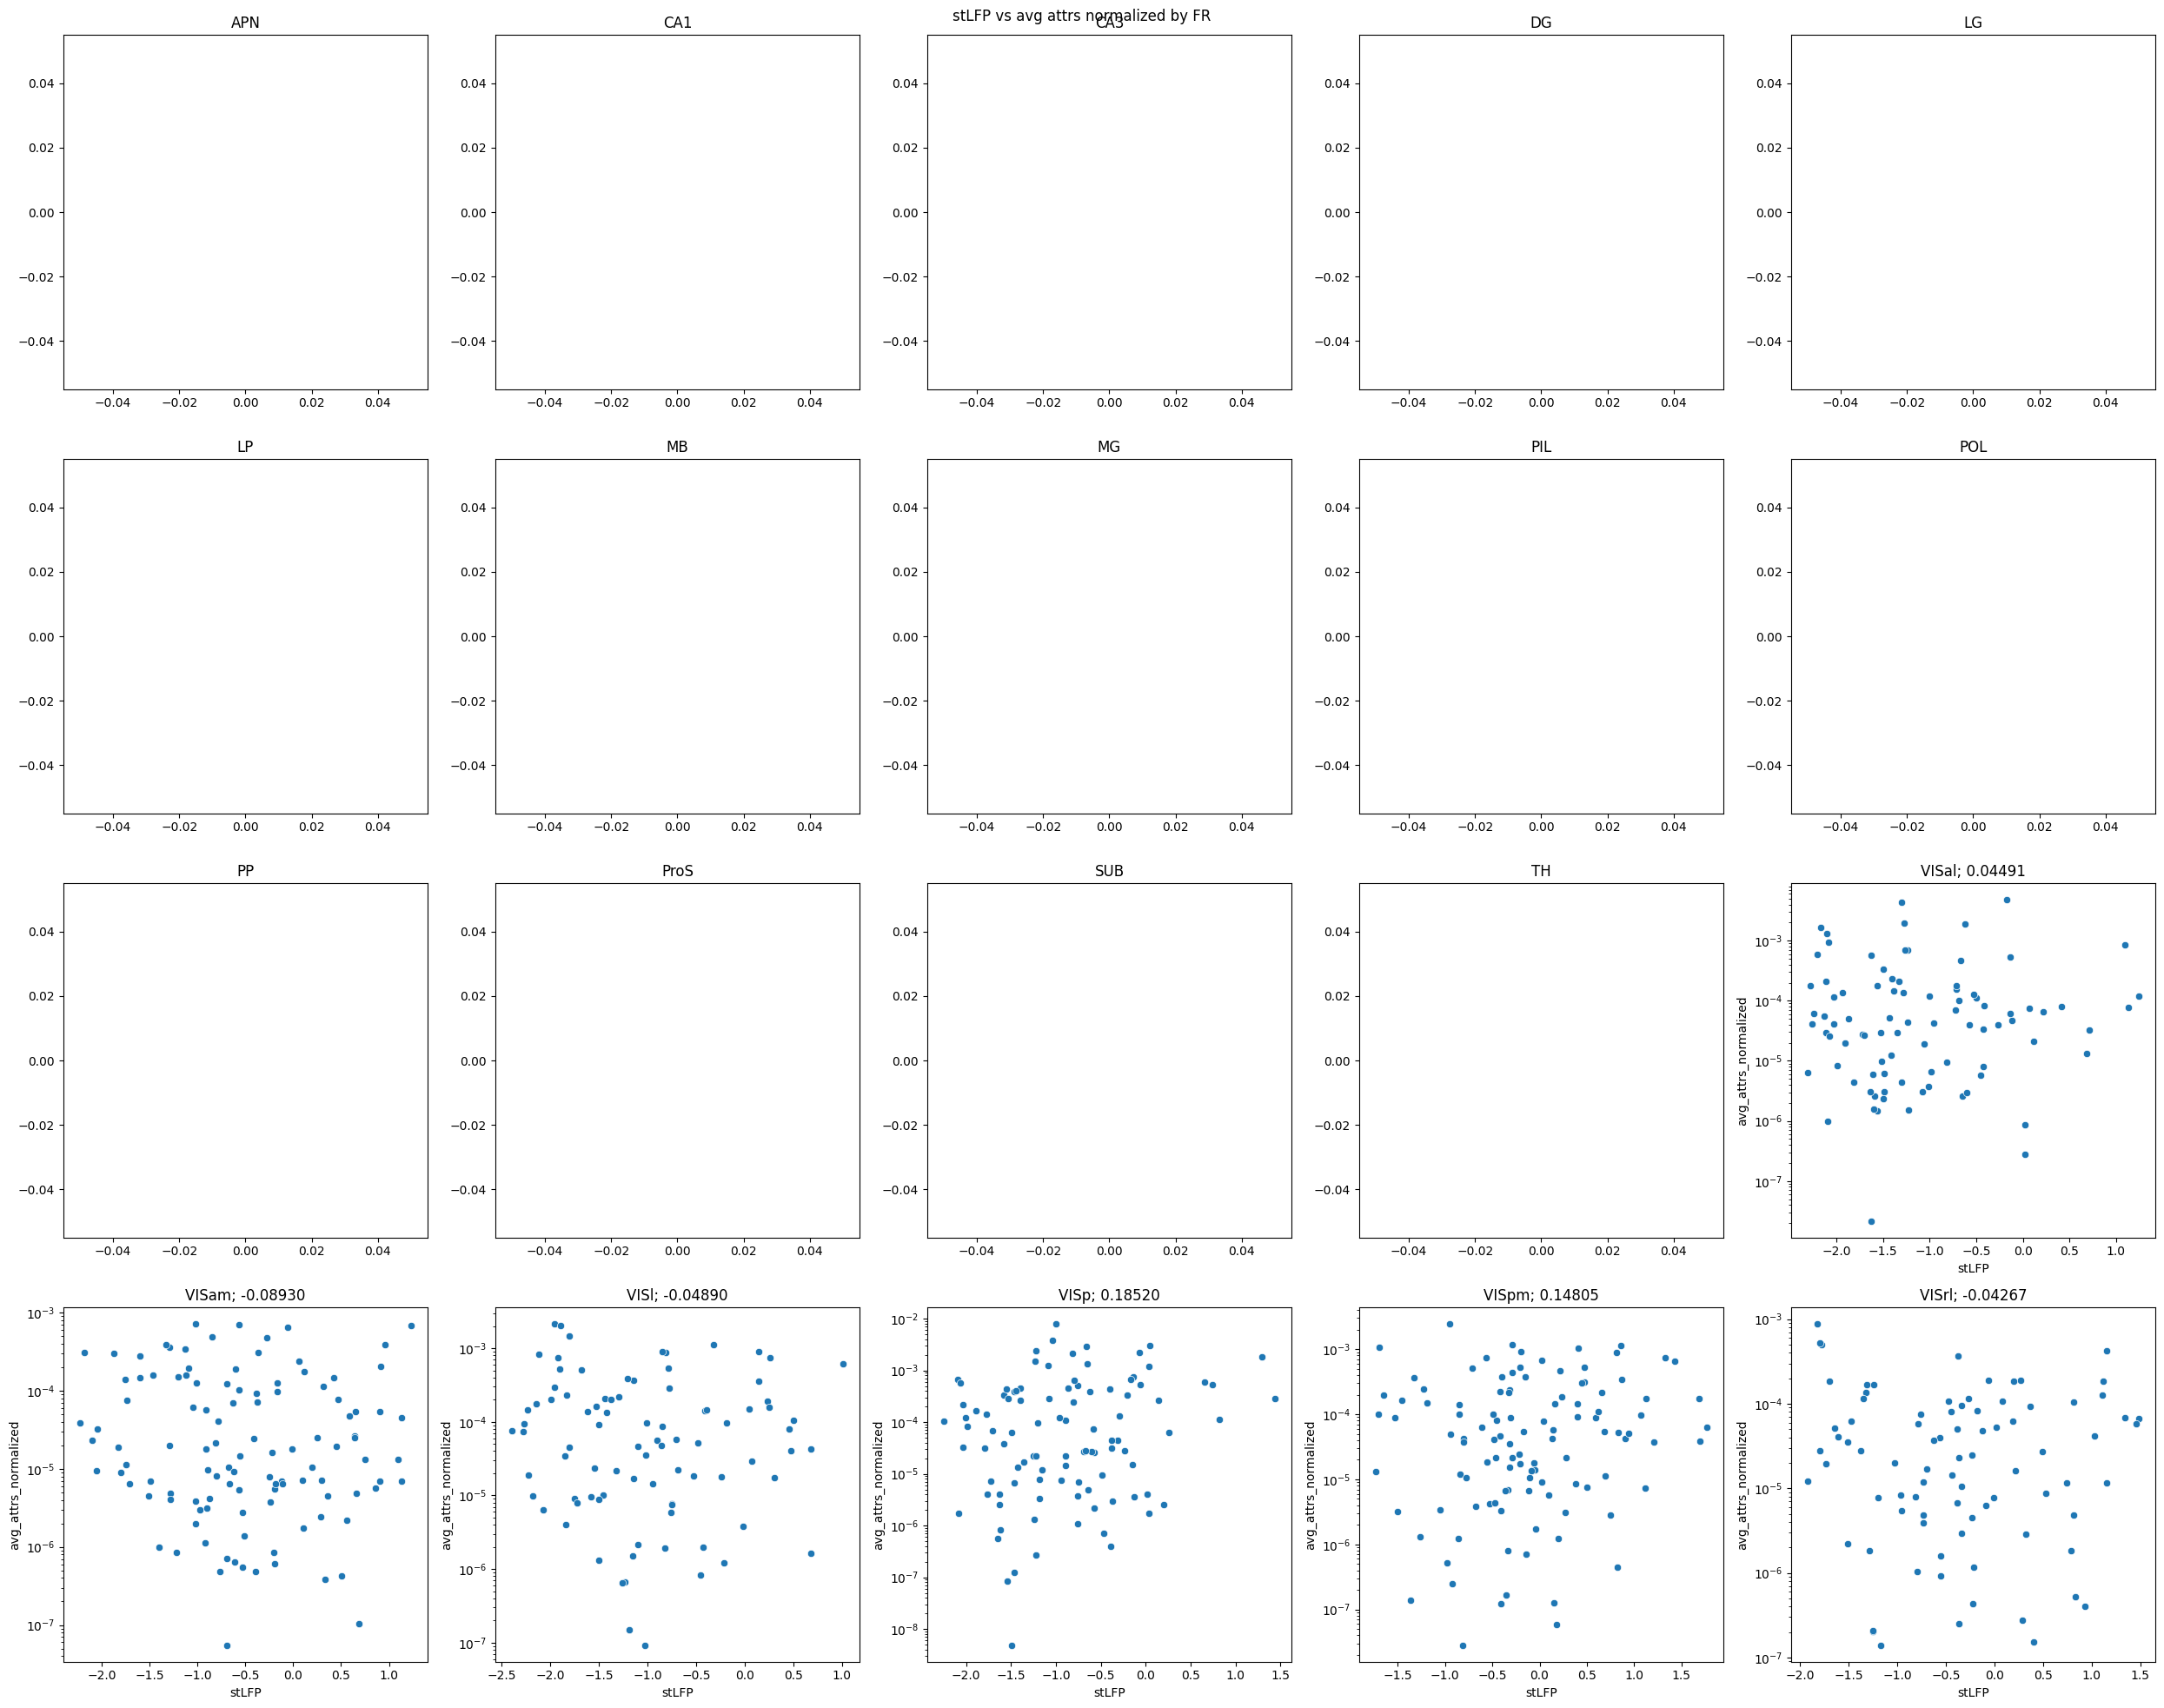

mean_stPR


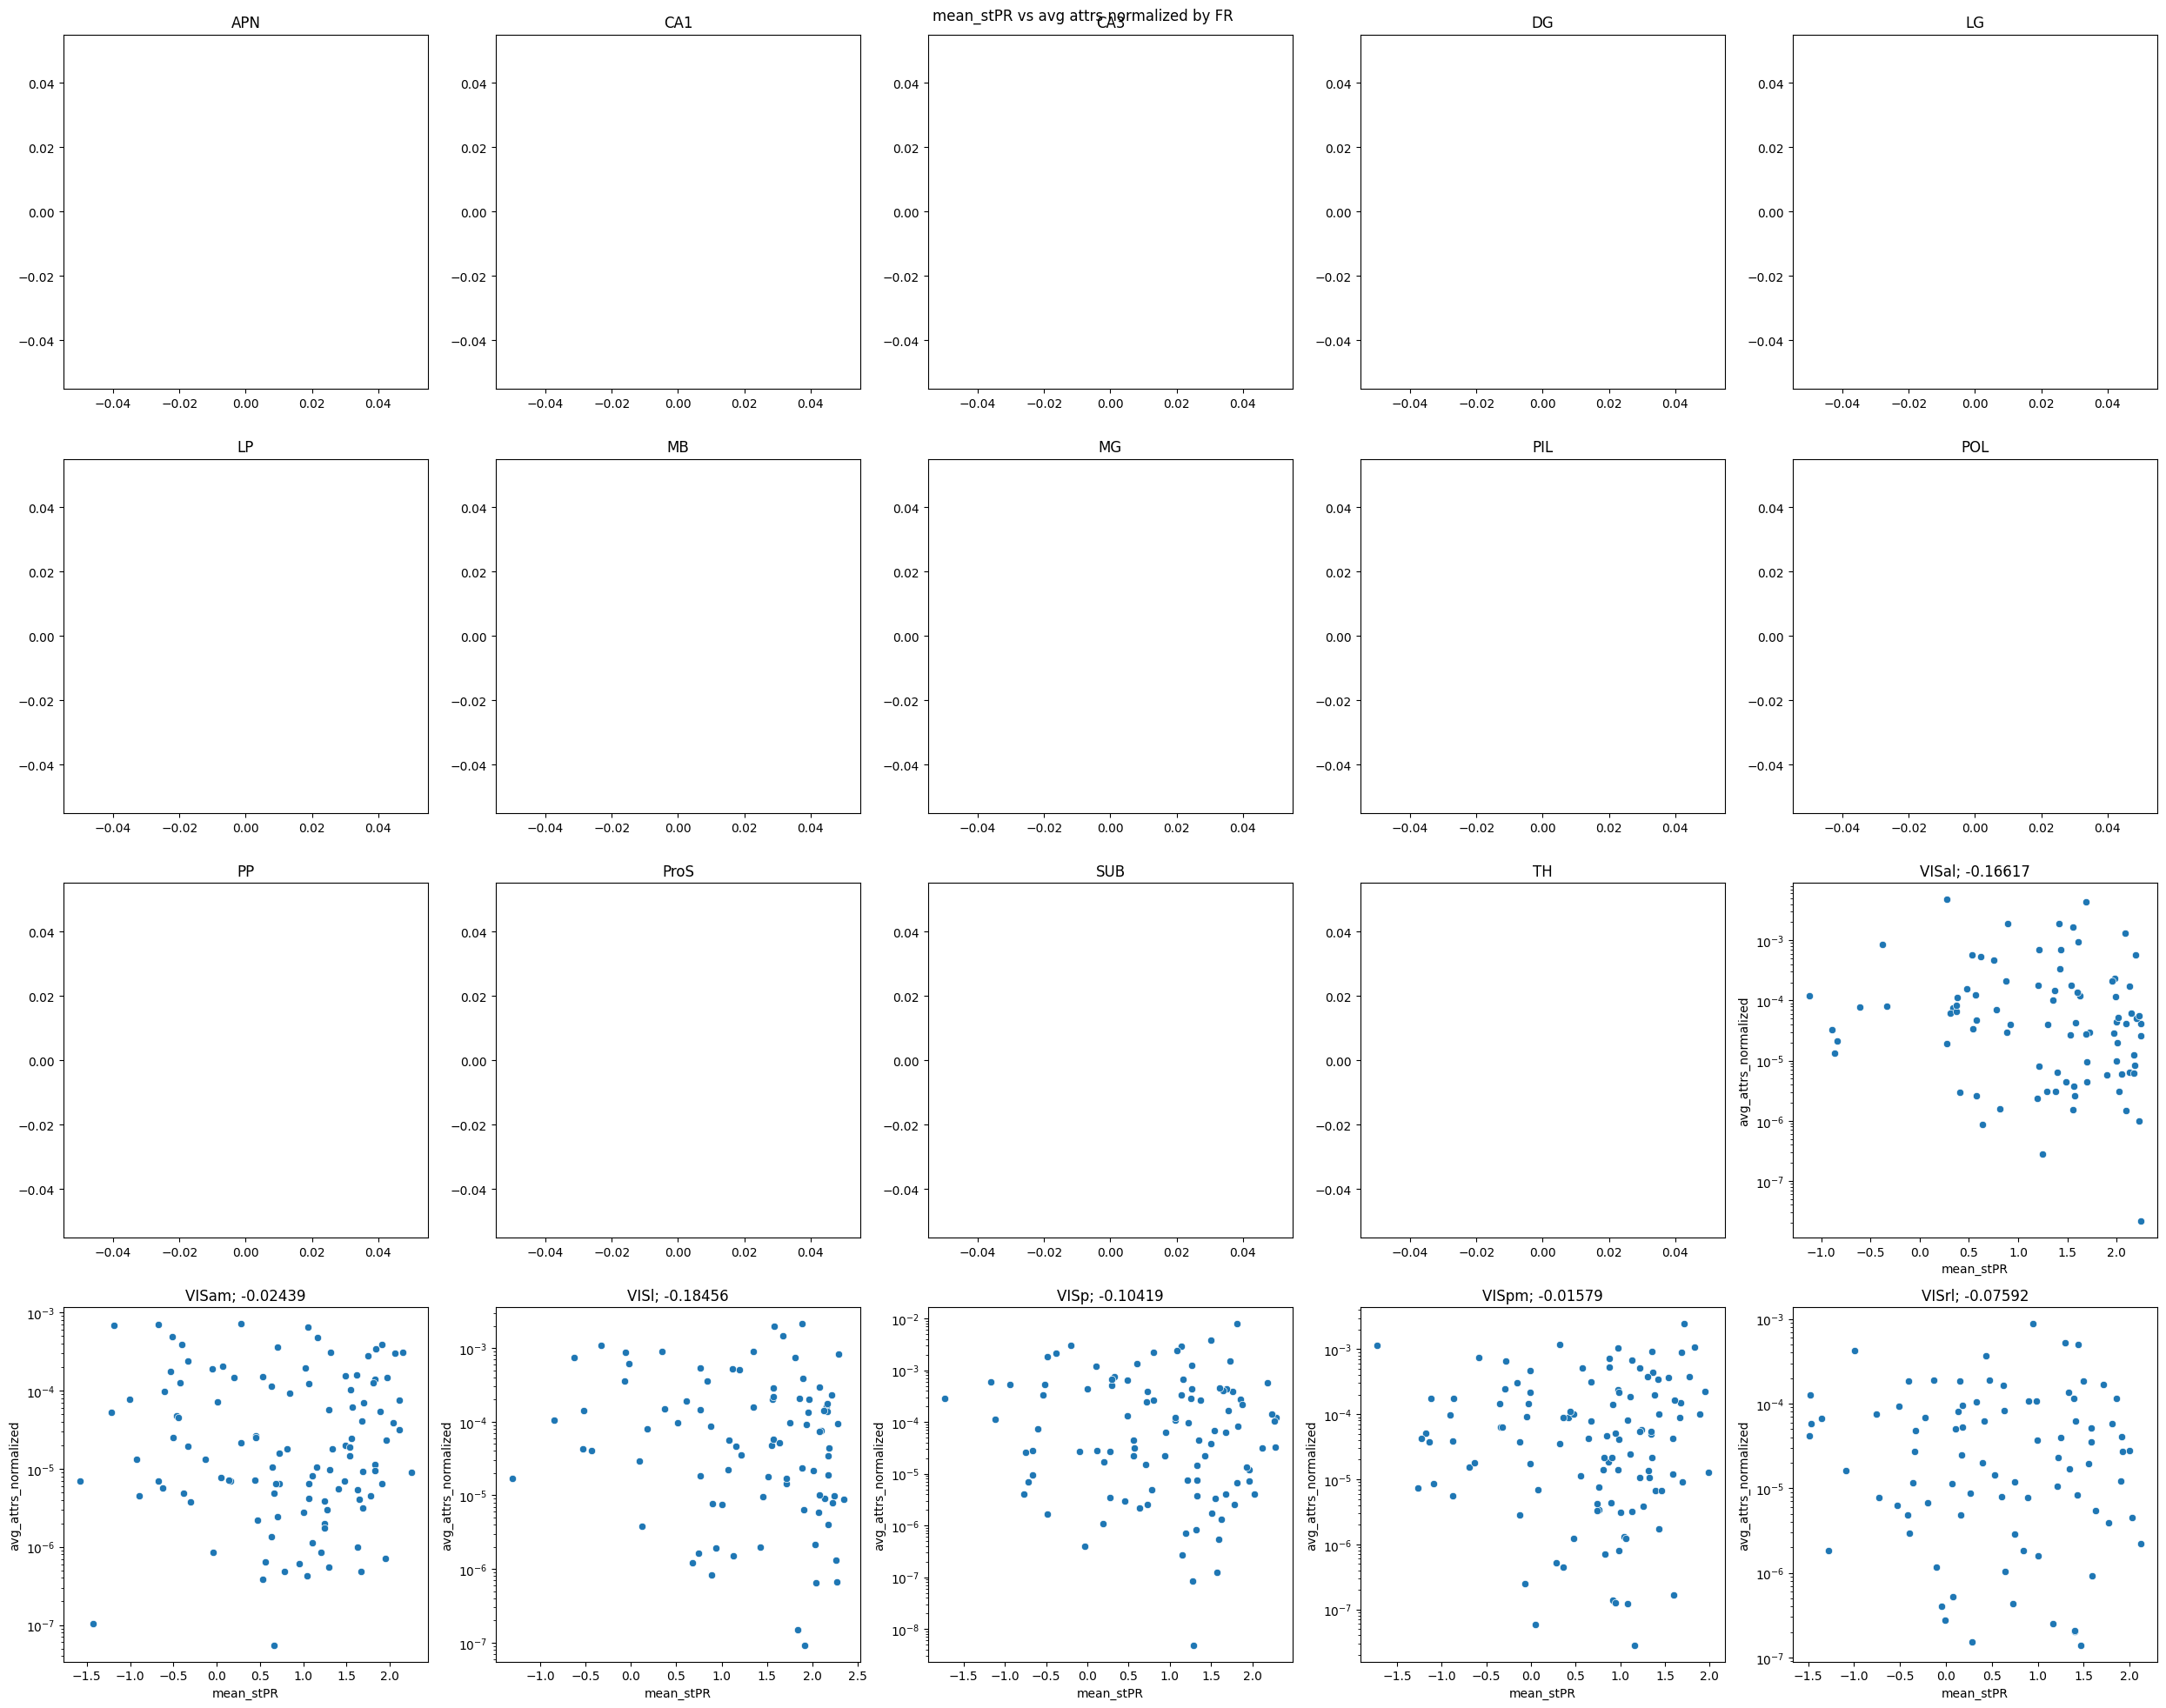

dist_from_lfp


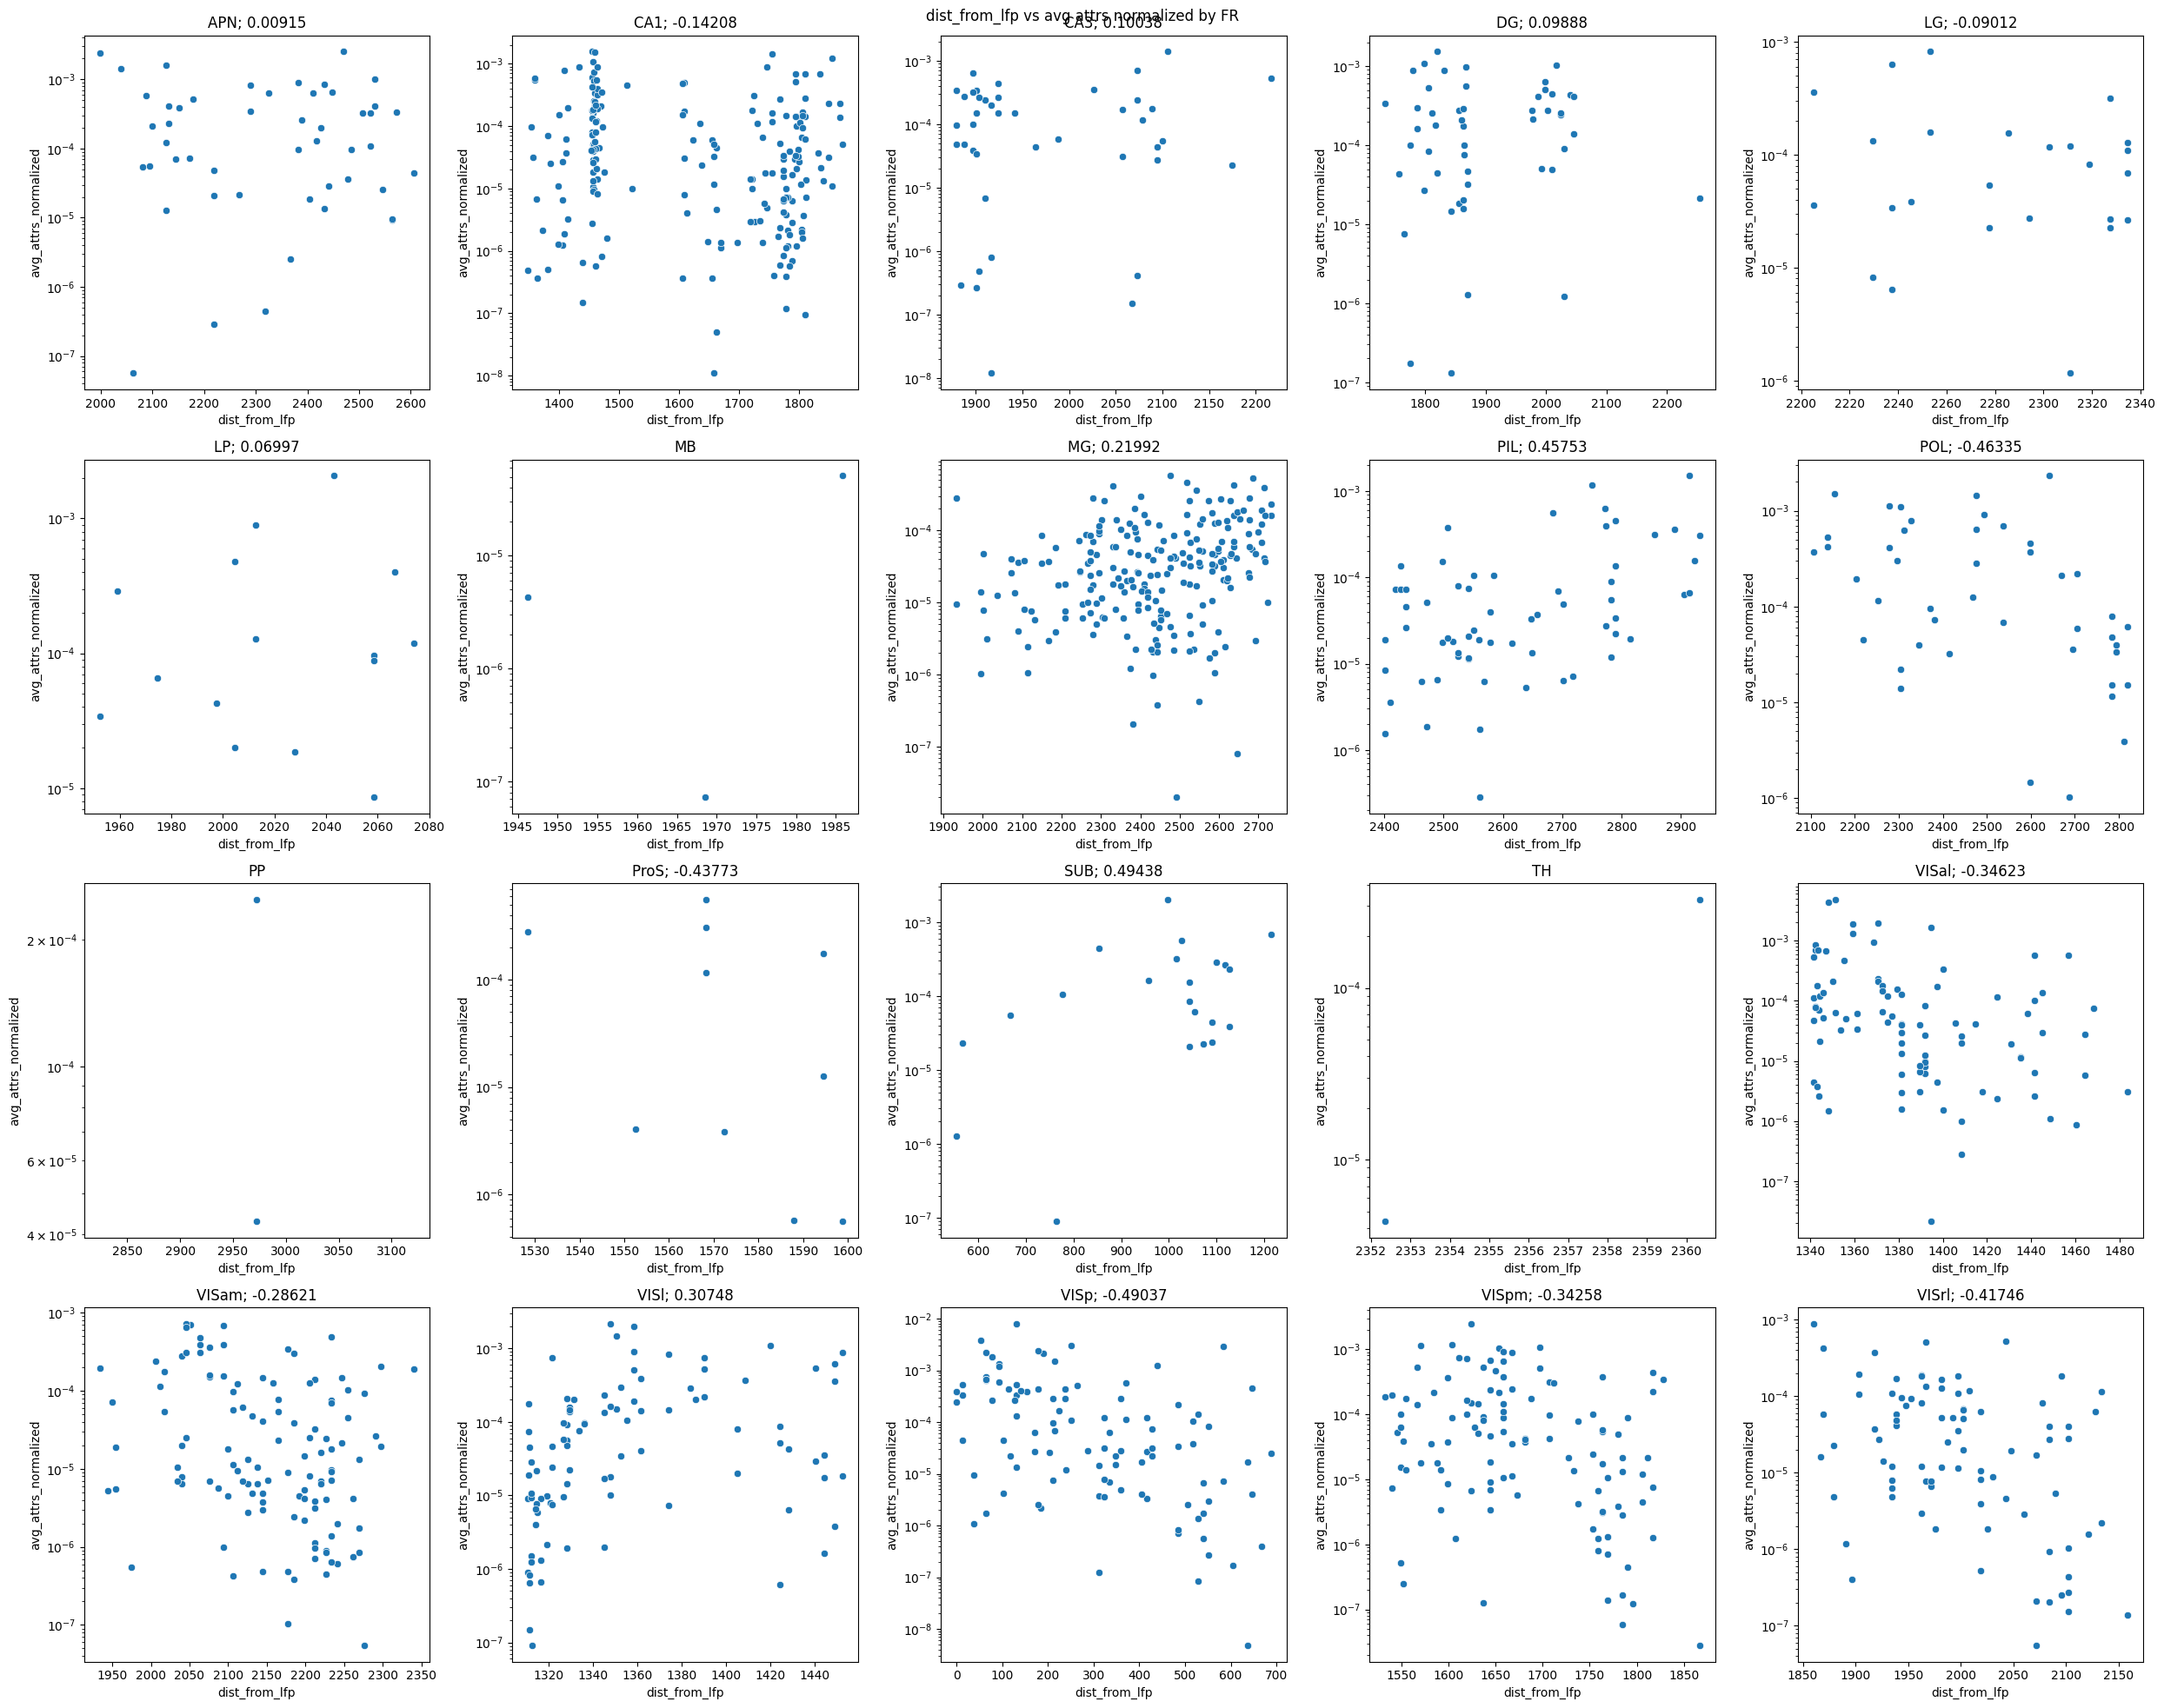

sparsity


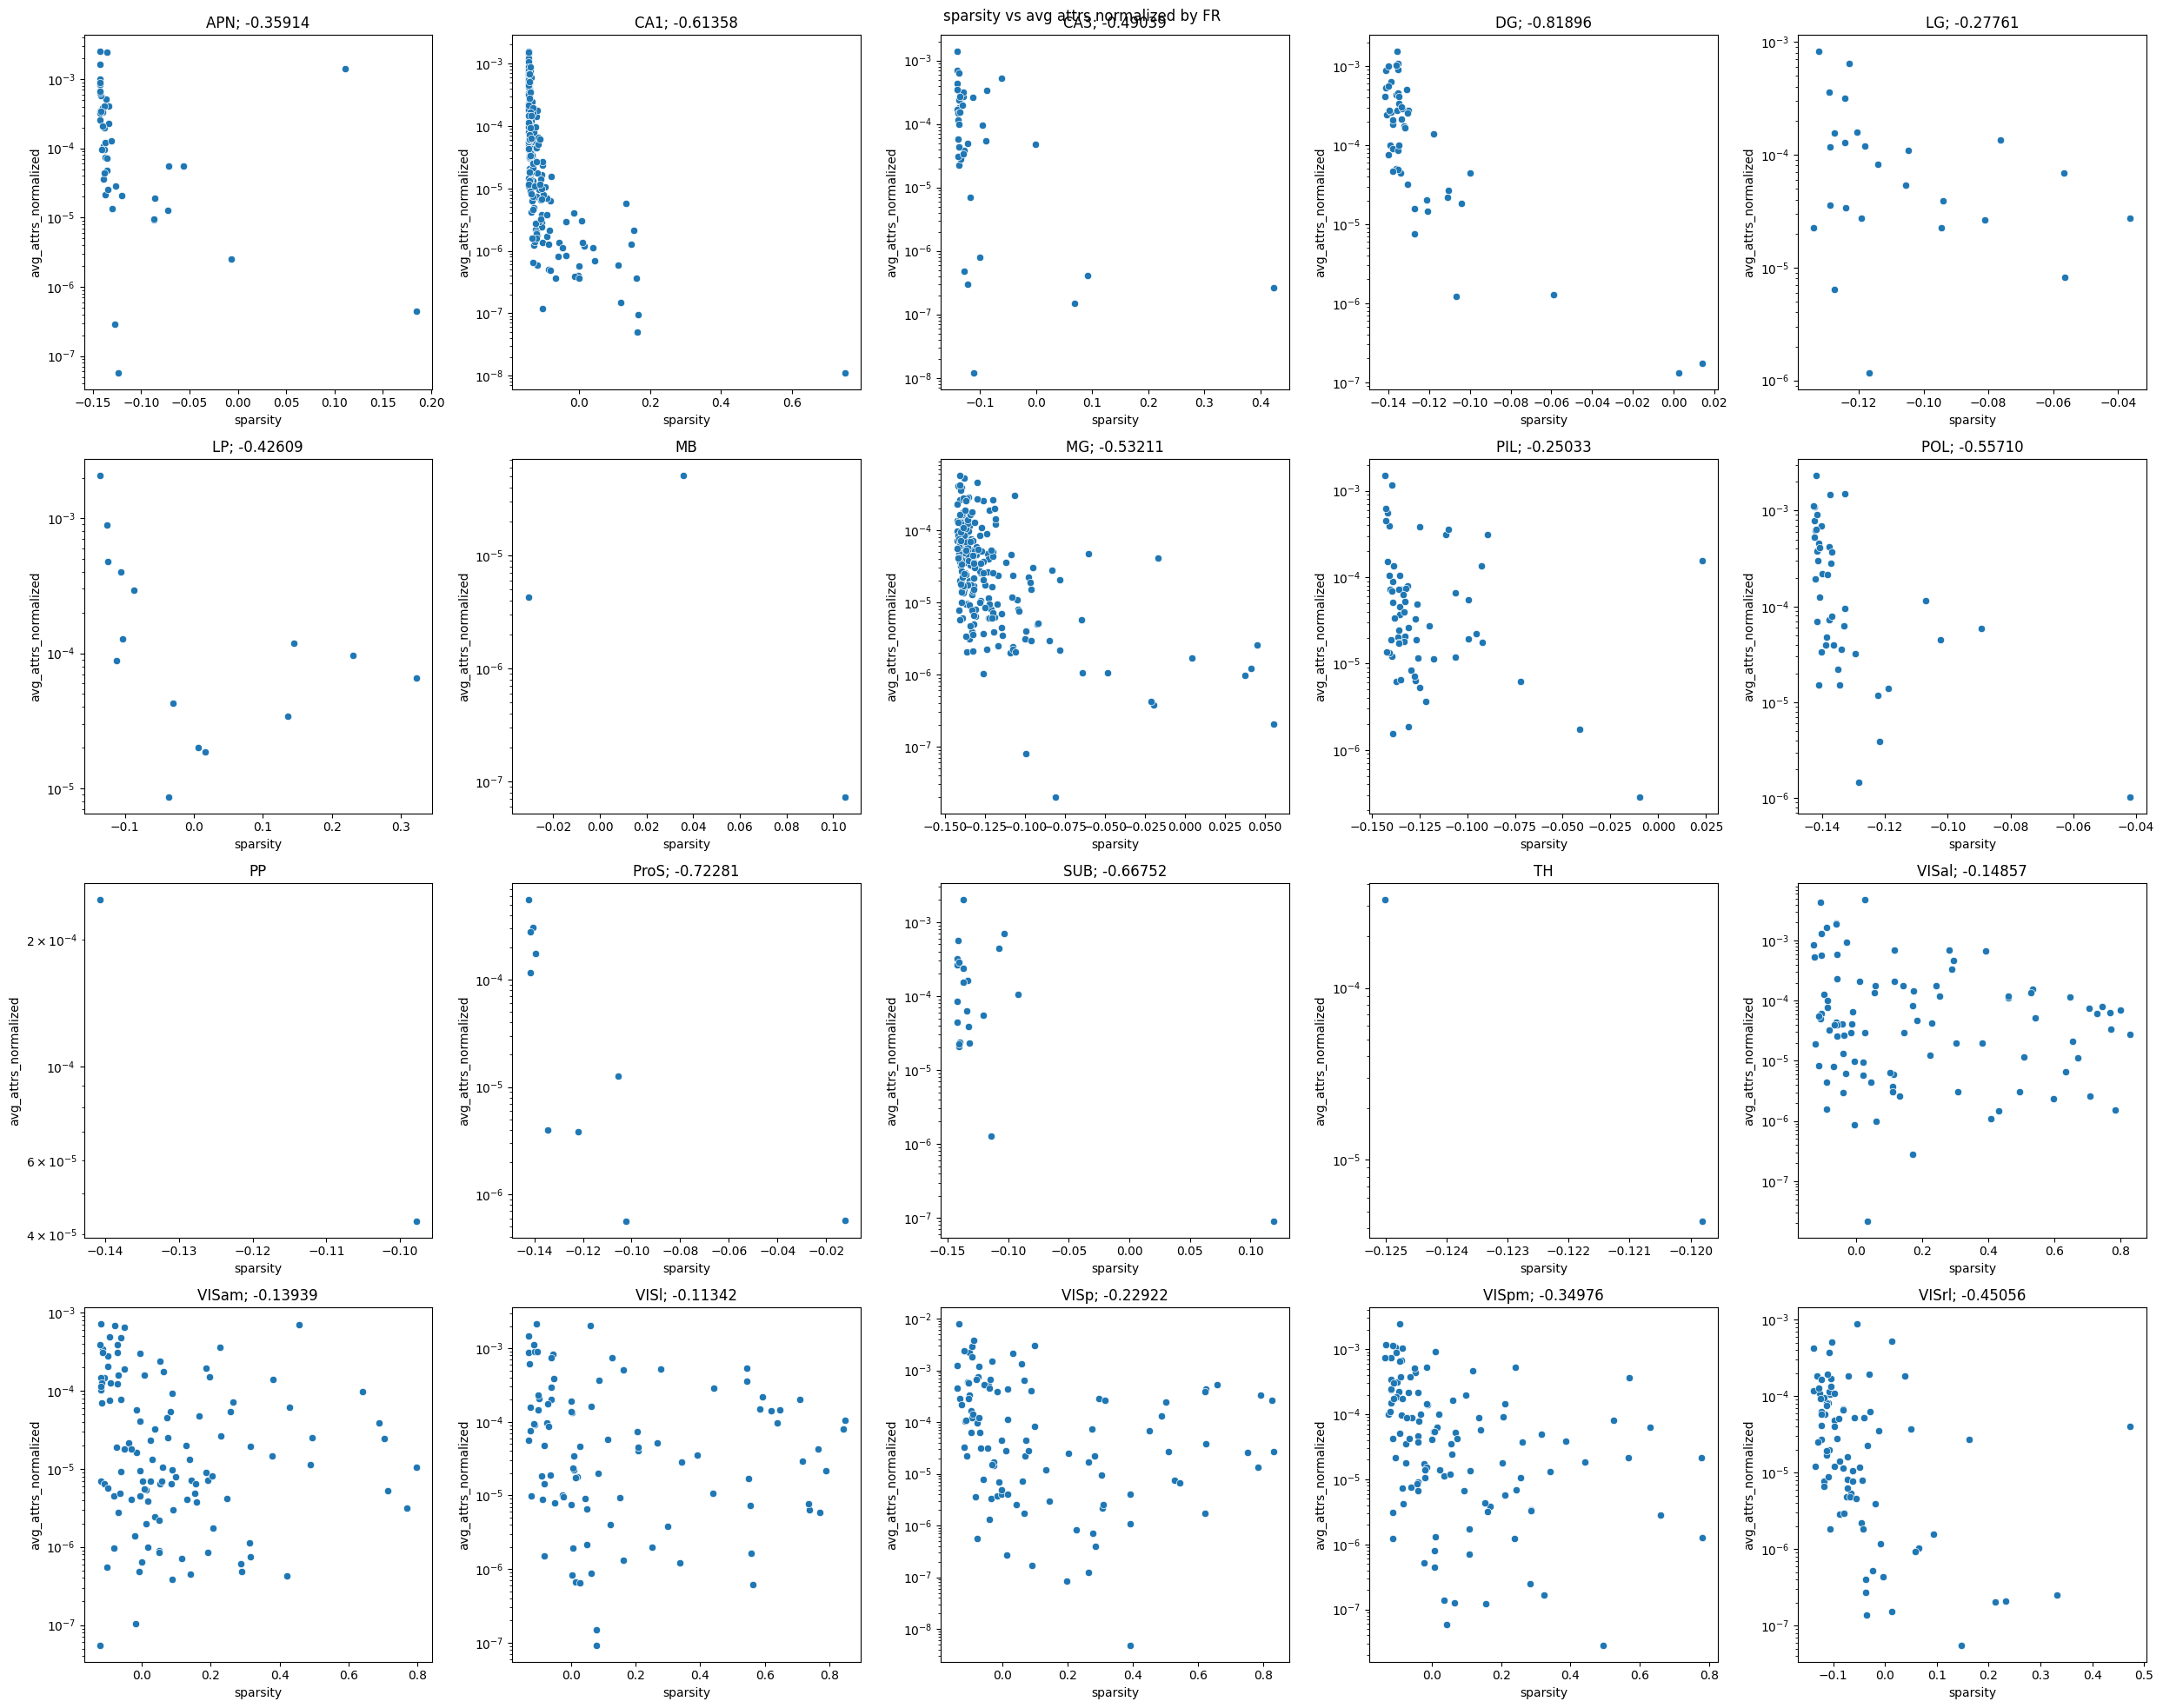

induced_percent


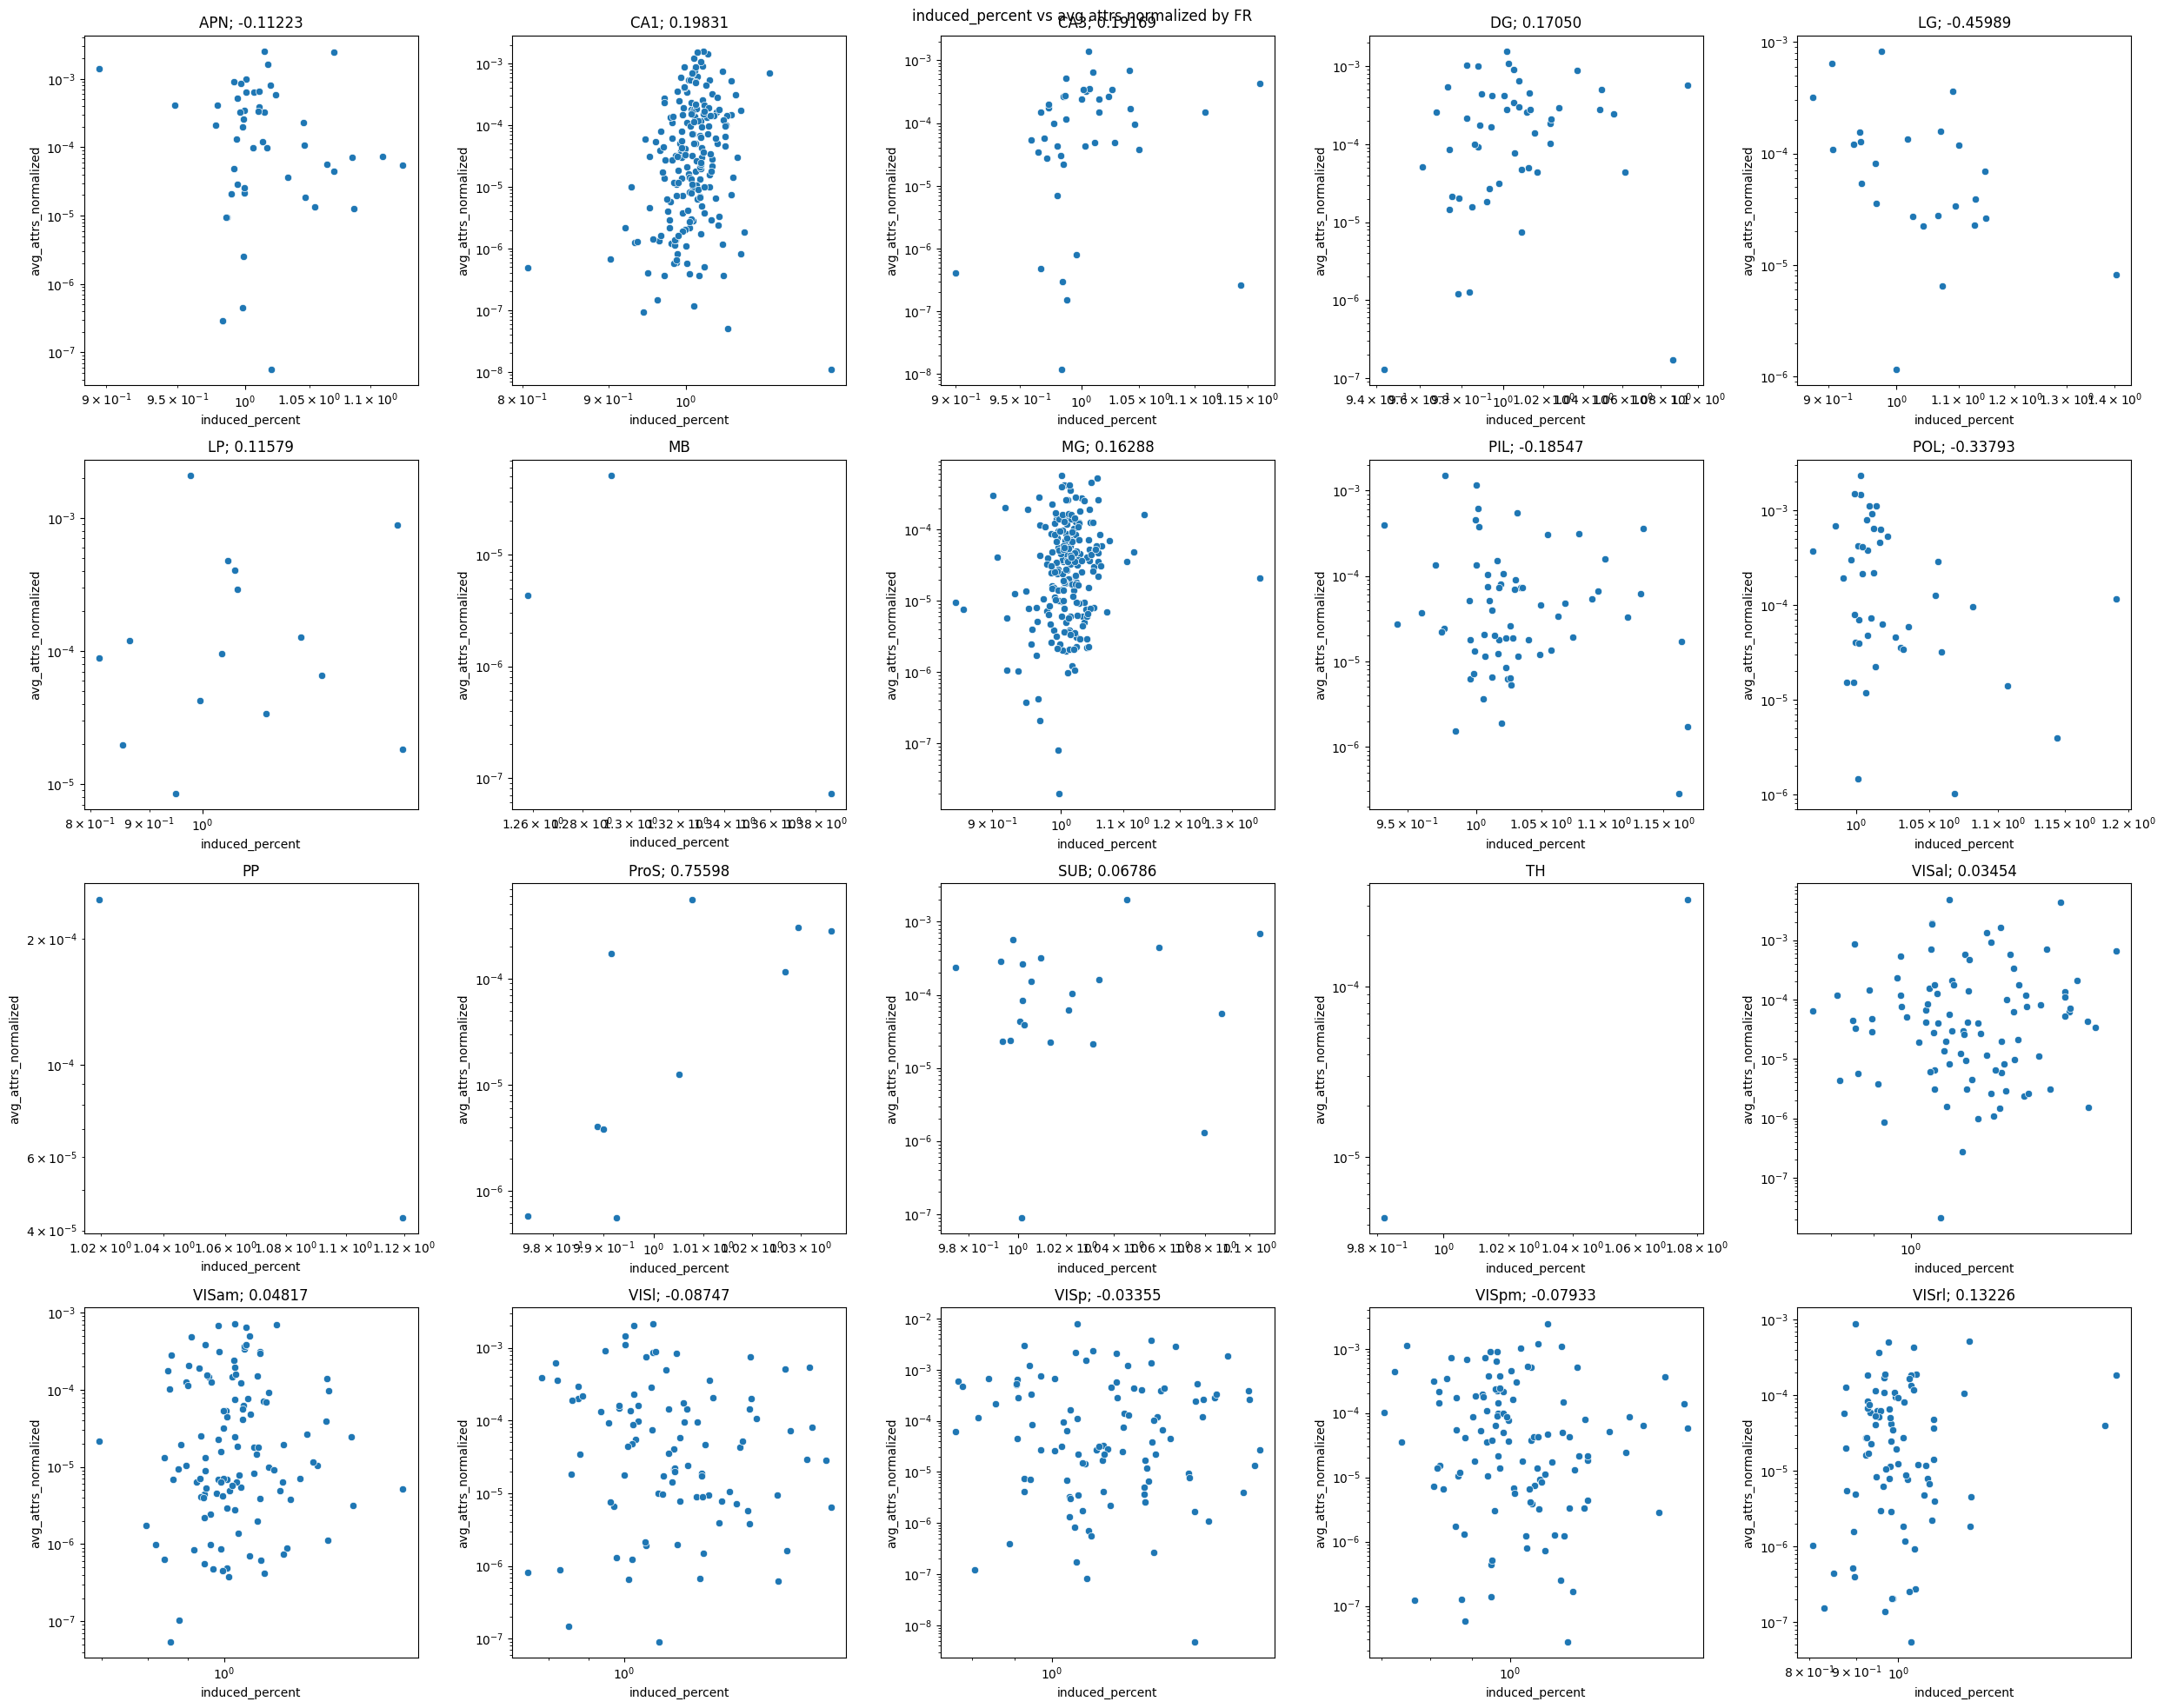

In [ ]:
#@title Plot corr for each area
# Similar to the previous code, but now we plot the correlation for each area separately
for col in cols:
    print(col)
    if col == 'avg_attrs_normalized': continue
    if col == 'avg_attrs_normalized_log': continue
    fig, axs = plt.subplots(4, 5, figsize=(25, 20))
    fig.suptitle(f"{col} vs avg attrs normalized by FR")
    for idx, area in enumerate(unique_areas):
        fig_row = idx // 5
        fig_col = idx % 5
        ax = axs[fig_row, fig_col]
        ax.set_title(area)
        area_mask = units_filtered.structure_acronym == area
        ids = units_filtered.id.values[area_mask]
        id_idx = np.array([True if i in ids else False for i in features_df.index.values])
        temp_df = features_df.loc[ids]
        plot = sns.scatterplot(data=temp_df,
                           x=col,
                           y='avg_attrs_normalized',
                           ax=ax)
        nan_filter = ~np.isnan(temp_df[col].values)
        inf_filter = ~np.isinf(temp_df[col].values)
        zero_filter = temp_df[col].values != 0
        attr_filter_temp = attr_filter[id_idx]
        value_filter = nan_filter & inf_filter & zero_filter & attr_filter_temp

        if np.sum(value_filter) > 1:
            if to_log_normalize[col]:
                ax.set_xscale('log')
            ax.set_yscale('log')

        if np.sum(value_filter) < 5:
            plot.set_title(f"{area}")
        else:
            if to_log_normalize[col]:
                plot.set_title(f"{area}; {np.corrcoef(np.log10(temp_df[col].values[value_filter]), np.log10(temp_df['avg_attrs_normalized'].values[value_filter]))[0,1]:.5f}")
            else:
                plot.set_title(f"{area}; {np.corrcoef(temp_df[col].values[value_filter], np.log10(temp_df['avg_attrs_normalized'].values[value_filter]))[0,1]:.5f}")
    plt.tight_layout()
    # plt.savefig(f"{fig_storage_dir}{col}.png")
    # plt.close()
    plt.show()

##### Try the number of connections

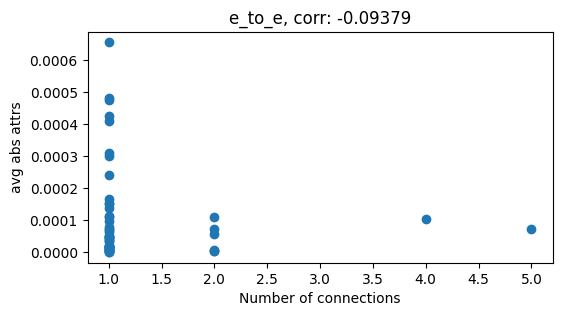

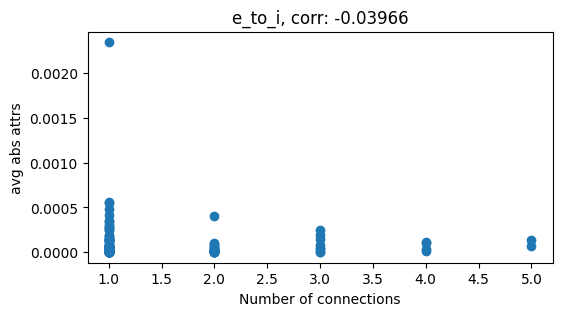

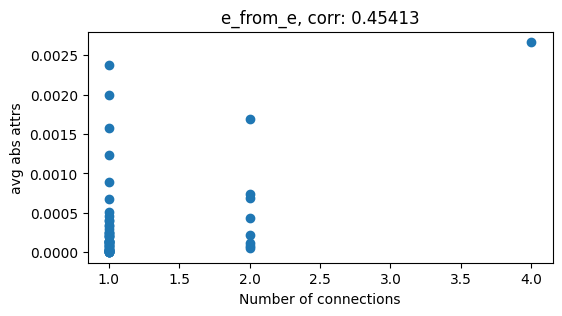

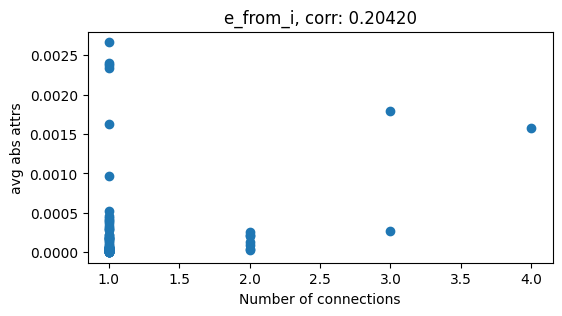

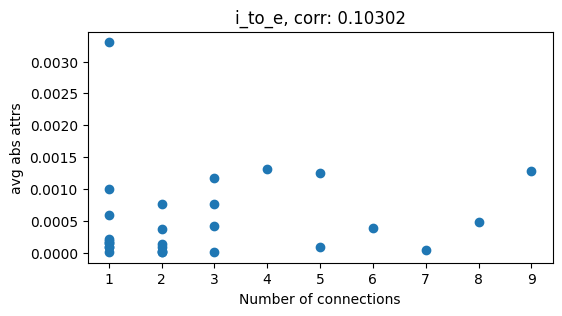

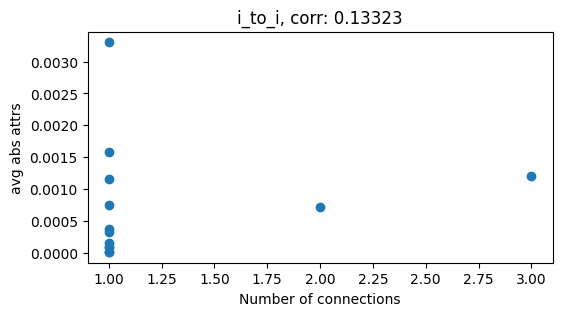

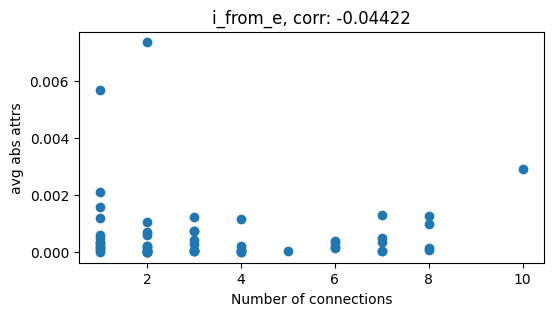

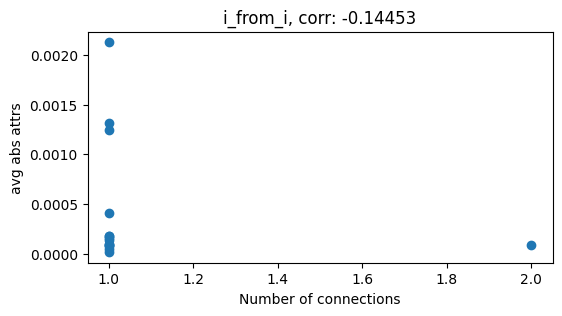

In [ ]:
# Please note that here attrs are not log-normalized
for col in cols:
    if "num_conn" not in col: continue
    plt.figure(figsize=(6, 3))
    plt.scatter(features_df[col].values, features_df['avg_attrs_normalized'].values)
    nan_filter = ~np.isnan(features_df[col].values)
    coef = np.corrcoef(features_df[col].values[nan_filter], features_df['avg_attrs_normalized'].values[nan_filter])[0,1]
    plt.title(f"{col[9:]}, corr: {coef:.5f}")
    plt.xlabel("Number of connections")
    plt.ylabel("avg abs attrs")

##### Spike Triggered LFP

In [ ]:
# Calcualting st-LFP
# This is the old implementation, the newer version can be found in examine_model_error_and_error_correlated_LFP.ipynb
# This version is much slower, but slicing and windowing is equivalent
def calculate_spike_triggered_lfp(spiketimes, unit_ids, lfp, timestamps, timelimit = 720, window_half_size=50, normalize=None):
    num_bins = lfp.shape[0]
    num_units = len(unit_ids)
    window_length = 2 * window_half_size + 1
    st_lfp_all_neurons = np.full((window_length, num_units), np.nan)
    st_lfp_all_neurons_std = np.full((window_length, num_units), np.nan)
    # for each unit, find the spike times within the time limit
    for idx, unit_id in tqdm(enumerate(unit_ids)):
        spike_times = spiketimes[unit_id]
        spike_times = spike_times[spike_times < timelimit]
        spike_idxs = np.searchsorted(timestamps, spike_times)
        if len(spike_times) == 0:
            print(f"Unit {unit_id}: No spikes found. Result will be NaN.")
            continue
        lfp_segments = []
        # for each spike, extract the LFP segment around the spike
        for spike_idx in spike_idxs:
            start_idx = spike_idx - window_half_size
            end_idx = spike_idx + window_half_size + 1
            if start_idx >= 0 and end_idx <= num_bins:
                if normalize is None:
                    lfp_segments.append(lfp[start_idx:end_idx])
                elif normalize == 'min_max':
                    lfp_segments.append(minmax_scale(lfp[start_idx:end_idx]))
                elif normalize == 'zscore':
                    lfp_segments.append(zscore(lfp[start_idx:end_idx]))
                else:
                    raise ValueError(f"Unknown normalization method: {normalize}")
        if not lfp_segments:
            print(f"Unit {unit_id}: No valid LFP segments could be extracted "
                  f"(e.g., all spikes too close to LFP boundaries). Result will be NaN.")
            continue
        lfp_segments_array = np.array(lfp_segments)
        st_lfp_all_neurons[:, idx] = np.mean(lfp_segments_array, axis=0)
        st_lfp_all_neurons_std[:, idx] = np.std(lfp_segments_array, axis=0)
    return st_lfp_all_neurons, st_lfp_all_neurons_std

Promonences from positive LFP: []
Promonences from negative LFP: [0.66700347]


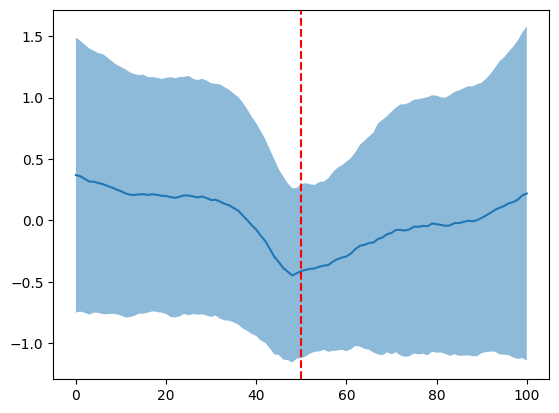

In [ ]:
lfp = lfp[:,5,0]
with open('/content/drive/MyDrive/spike_times_1119946360.pkl', 'rb') as f:
    spike_times = pickle.load(f)
# calculate spike-triggered LFP -> for the first 18000 bins
stLFP, stLFP_std = calculate_spike_triggered_lfp(spike_times, units.id.values, lfp, timestamps, timelimit = 720, window_half_size=50, normalize='min_max')

idx = 785
plt.plot(stLFP[:,idx])
plt.fill_between(np.arange(stLFP.shape[0]), stLFP[:,idx] - stLFP_std[:,idx], stLFP[:,idx] + stLFP_std[:,idx], alpha=0.5)
plt.axvline(50, color='r', linestyle='--')
peaks, args = find_peaks(stLFP[:,idx], prominence=0.05)
prominences = args['prominences']
print(f"Promonences from positive LFP: {prominences}")
# print(f"Largest peak prominence: {np.max(prominences)} idx: {peaks[np.argmax(prominences)]}")

peaks, args = find_peaks(-stLFP[:,idx], prominence=0.05)
prominences = args['prominences']
print(f"Promonences from negative LFP: {prominences}")
# print(f"Largest peak prominence: {np.max(prominences)} idx: {peaks[np.argmax(prominences)]}")


In [ ]:
# Given st-LFP, find the peak, prominence and latency for each unit
peaks = np.zeros(input_size)
prominences = np.zeros(input_size) # how high the peak/trough is
latencies = np.zeros(input_size)

for idx in range(input_size):
    # Check peaks
    peaks_pos, args_pos = find_peaks(stLFP[:,idx], prominence=0.05) # arbitrary prominence threshold, filter out small fluctuations
    prominences_pos = args_pos['prominences']
    if len(peaks_pos) == 0:
        prominences_pos_max = 0
    else:
        prominences_pos_max = np.max(prominences_pos)
    
    # Check troughs
    peaks_neg, args_neg = find_peaks(-stLFP[:,idx], prominence=0.05)
    prominences_neg = args_neg['prominences']
    if len(peaks_neg) == 0:
        prominences_neg_max = 0
    else:
        prominences_neg_max = np.max(prominences_neg)

    # If no peaks or troughs found, set NaN
    if prominences_pos_max == 0 and prominences_neg_max == 0:
        prominences[idx] = np.nan
        peaks[idx] = np.nan
        latencies[idx] = np.nan
    else:
        # If both peaks and troughs are found, choose the one with the highest prominence
        if prominences_pos_max > prominences_neg_max:
            prominences[idx] = prominences_pos_max
            peaks[idx] = peaks_pos[np.argmax(prominences_pos)]
            latencies[idx] = peaks[idx] - 50 # removing offset, 50 is the half window size, here is hardcoded
        else:
            prominences[idx] = prominences_neg_max
            peaks[idx] = peaks_neg[np.argmax(prominences_neg)]
            latencies[idx] = peaks[idx] - 50

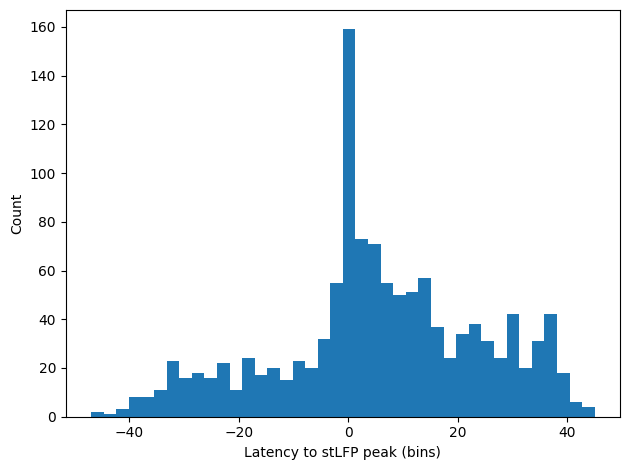

In [ ]:
plt.hist(latencies, bins=40)
plt.xlabel("Latency to stLFP peak (bins)")
plt.ylabel("Count")
plt.tight_layout()
plt.show();

-0.024596653294480127


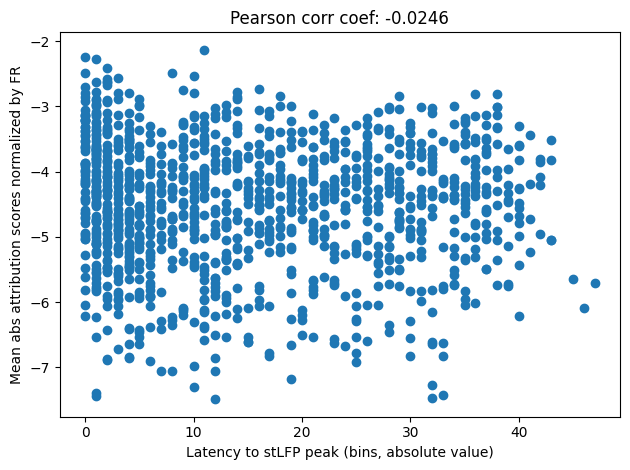

In [ ]:
attrs_direct_normalized_unit = np.array(features_df['avg_attrs_normalized'].values)
nanfilter = ~np.isnan(latencies)
valfilter = np.ones_like(nanfilter, dtype=bool)
nanfilter = nanfilter & valfilter & attr_filter
plt.scatter(np.abs(latencies)[nanfilter], np.log10(attrs_direct_normalized_unit[nanfilter]))
print(np.corrcoef(np.abs(latencies)[nanfilter], np.log10(attrs_direct_normalized_unit[nanfilter]))[0,1])
plt.xlabel("Latency to stLFP peak (bins, absolute value)")
plt.ylabel("Mean abs attribution scores normalized by FR")
plt.title(f"Pearson corr coef: {np.corrcoef(np.abs(latencies)[nanfilter], np.log10(attrs_direct_normalized_unit[nanfilter]))[0,1]:.4f}")
plt.tight_layout()
plt.show();

##### Phase modulation

In [ ]:
# This method keeps having problem with (0.5-4hz), but not other frequency bands
lfp_5_0_1250hz_src = "/content/drive/MyDrive/lfp_5_0_1250hz_1119946360.b2"
lfp_5_0_1250hz_dst = "/content/lfp_5_0_1250hz_1119946360.b2"
shutil.copy(lfp_5_0_1250hz_src, lfp_5_0_1250hz_dst)
lfp_5_0_1250hz = blosc2.load_tensor(lfp_5_0_1250hz_dst)

In [ ]:
#@title helper functions
# Down below are translated from buzzcode
import numpy as np
from scipy.signal import butter, filtfilt, hilbert
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
import os
from scipy.io import savemat

# For circular statistics
from astropy.stats import circmean, rayleightest
from scipy.stats import vonmises # Used for mode estimation via fitting

# --- Helper Function: fastrms (interpreted as sliding window RMS) ---
def _fastrms_sliding(data, window_length):
    """
    Calculates sliding window RMS.
    Output is same size as input data.
    """
    data = np.asarray(data)
    window_length = int(window_length)
    if window_length <= 0:
        raise ValueError("window_length must be positive.")
    if window_length % 2 == 0: # Make it odd for 'same' padding to be centered
        window_length +=1

    squared_signal = data**2
    # 'reflect' mode handles boundaries well for filtering
    mean_square = uniform_filter1d(squared_signal, size=window_length, mode='reflect', origin=0)
    print(window_length)
    return np.sqrt(mean_square)

# --- Helper Function: subtract_intervals ---
def _subtract_intervals(intervals_a, intervals_b):
    """
    Subtracts intervals_b from intervals_a.
    intervals_a, intervals_b: Nx2 numpy arrays of [start, end] pairs.
    Assumes intervals within a and b are sorted and non-overlapping.
    """
    if not isinstance(intervals_a, np.ndarray):
        intervals_a = np.array(intervals_a)
    if not isinstance(intervals_b, np.ndarray):
        intervals_b = np.array(intervals_b)

    if intervals_a.size == 0:
        return np.array([])
    if intervals_b.size == 0:
        return intervals_a.copy()

    # Ensure they are 2D arrays
    if intervals_a.ndim == 1 and intervals_a.shape[0] == 2:
        intervals_a = intervals_a.reshape(1, 2)
    if intervals_b.ndim == 1 and intervals_b.shape[0] == 2:
        intervals_b = intervals_b.reshape(1, 2)

    current_intervals_list = intervals_a.tolist()
    # print(f"Intervals a: {intervals_a}")
    # print(f"Intervals b: {intervals_b}")

    for b_start, b_end in intervals_b:
        next_intervals_list = []
        for a_start, a_end in current_intervals_list:
            # No overlap: B ends before A starts or B starts after A ends
            if b_end <= a_start or b_start >= a_end:
                next_intervals_list.append([a_start, a_end])
                continue

            # B completely covers A
            if b_start <= a_start and b_end >= a_end:
                continue

            # A has a segment before B starts
            if a_start < b_start:
                next_intervals_list.append([a_start, min(a_end, b_start)])

            # A has a segment after B ends
            if a_end > b_end:
                next_intervals_list.append([max(a_start, b_end), a_end])

        current_intervals_list = sorted(next_intervals_list) if next_intervals_list else []
        if not current_intervals_list:
            break

    return np.array(current_intervals_list) if current_intervals_list else np.array([])

# --- Helper Function: in_intervals ---
def _in_intervals(times, intervals):
    """
    Checks which times fall within any of the given intervals.
    times: 1D numpy array of timestamps.
    intervals: Nx2 numpy array of [start, end] pairs.
    """
    if not isinstance(times, np.ndarray):
        times = np.array(times)
    if not isinstance(intervals, np.ndarray):
        intervals = np.array(intervals)

    if intervals.size == 0:
        return np.zeros_like(times, dtype=bool)
    if intervals.ndim == 1 and intervals.shape[0] == 2:
        intervals = intervals.reshape(1, 2)

    bools = np.zeros_like(times, dtype=bool)
    for start, end in intervals:
        bools |= (times >= start) & (times <= end) # Inclusive start and end
    return bools

# --- Helper Function: circular_distribution_stats ---
def _circular_distribution_stats(phases_rad, num_bins):
    """
    Calculates circular statistics and binned distribution.
    phases_rad: 1D numpy array of phases (in radians, 0 to 2*pi).
    """
    phases_rad = phases_rad[~np.isnan(phases_rad)]

    stats = {'m': np.nan, 'r': np.nan, 'k': np.nan, 'p': np.nan, 'mode': np.nan}
    bins_centers = np.linspace(0, 2 * np.pi, num_bins + 1)[:-1] + (np.pi / num_bins)
    distro_percent = np.zeros(num_bins)

    if len(phases_rad) == 0:
        return distro_percent, bins_centers, stats

    counts, bins_edges = np.histogram(phases_rad, bins=num_bins, range=(0, 2 * np.pi))
    distro_percent = counts / np.sum(counts) if np.sum(counts) > 0 else np.zeros_like(counts, dtype=float)

    assert np.max(phases_rad) <= 2*np.pi
    angles = np.exp(1j*phases_rad);
    r = np.abs(np.nanmean(angles));
    # print(f"From translated code: {stats['r']}")
    # print(f"From euler's formula {r}")
    m = np.angle(np.nanmean(angles));

    # Mean angle (m)
    mean_angle = circmean(phases_rad) if len(phases_rad) > 0 else np.nan
    if not np.isnan(mean_angle) and mean_angle < 0:
         mean_angle += 2 * np.pi # Ensure 0 to 2*pi range
    # stats['m'] = mean_angle
    stats['m'] = m

    # Mean resultant length (r) and Rayleigh p-value (p)
    if len(phases_rad) > 0:
        S = np.sum(np.sin(phases_rad))
        C = np.sum(np.cos(phases_rad))
        R_val_unnormalized = np.sqrt(S**2 + C**2)
        # stats['r'] = R_val_unnormalized / len(phases_rad)
        stats['r'] = r
        stats['p'] = rayleightest(phases_rad)


    # Concentration parameter k (kappa)
    if len(phases_rad) > 1 and not np.isnan(stats['r']):
        r_val = stats['r']
        if r_val < 0.53:
            stats['k'] = 2 * r_val + r_val**3 + (5 * r_val**5) / 6
        elif r_val < 0.85:
            stats['k'] = -0.4 + 1.39 * r_val + 0.43 / (1 - r_val)
        else:
            stats['k'] = 1 / (r_val**3 - 4 * r_val**2 + 3 * r_val)
        if stats['k'] < 0 : stats['k'] = 0.0

    # Mode (angle with highest probability)
    if len(phases_rad) > 1:
        try: # Fit von Mises to estimate mode more robustly than max bin
            fit_kappa, fit_loc, _ = vonmises.fit(phases_rad, fscale=1)
            mode_angle = fit_loc
            if mode_angle < 0: mode_angle += 2 * np.pi
            stats['mode'] = mode_angle
            if not np.isnan(fit_kappa) and (np.isnan(stats['k']) or stats['k'] == 0.0):
                stats['k'] = fit_kappa # Update k if fit provides a better one
        except (RuntimeError, ValueError): # Fallback to max bin if fit fails
             stats['mode'] = bins_centers[np.argmax(counts)] if np.sum(counts)>0 else np.nan
    elif len(phases_rad) == 1: # single spike
        stats['mode'] = phases_rad[0]


    return distro_percent, bins_centers, stats

#@title --- Main Function ---
def bz_phase_modulation_python(spikes, lfp_signal_data, passband,
                               intervals=None, sampling_rate=1250.0,
                               method='hilbert', plotting=True,
                               num_bins=180, power_thresh_sd=2.0, save_mat=False,
                               lfp_metadata=None): # lfp_metadata for filename, channels
    if not isinstance(lfp_signal_data, np.ndarray) or lfp_signal_data.ndim != 1:
        raise TypeError("lfp_signal_data must be a 1D NumPy array.")
    if not isinstance(passband, (list, tuple)) or len(passband) != 2:
        raise ValueError("passband must be a list/tuple of [lowHz, highHz].")

    if intervals is None:
        total_duration = len(lfp_signal_data) / sampling_rate
        intervals = np.array([[0, total_duration]])
    else:
        intervals = np.asarray(intervals)
        if intervals.ndim == 1 and intervals.shape == (2,): # Single interval
            intervals = intervals.reshape(1, 2)
        elif intervals.ndim != 2 or intervals.shape[1] != 2:
            raise ValueError("intervals must be an Nx2 array of [starts, stops].")
    print(f"Calculating from range [{intervals[0,0]}, {intervals[0,1]}]")

    method = method.lower()
    if lfp_metadata is None:
        lfp_metadata = {'filename': 'lfp_file', 'channels': [0]}

    # --- LFP Phase and Power Calculation ---
    lfpphase = None
    power_envelope = None # Renamed from `power` to avoid conflict with built-in
    print("Filtering LFP using hilbert")
    b, a = butter(3, [passband[0]/(sampling_rate/2), passband[1]/(sampling_rate/2)], btype='bandpass')
    filt_lfp = filtfilt(b, a, lfp_signal_data.astype(float))

    rms_window_len = int(np.ceil(sampling_rate / passband[0]))
    print(f"RMS window length: {rms_window_len}")
    power_envelope = _fastrms_sliding(filt_lfp, rms_window_len)

    hilb_lfp = hilbert(filt_lfp)
    lfpphase = np.mod(np.angle(hilb_lfp), 2 * np.pi) # Phase 0 to 2*pi

    # --- Update Intervals Based on Power Threshold ---
    print('Finding intervals below power threshold...')
    power_mean = np.mean(power_envelope)
    power_std = np.std(power_envelope)
    power_threshold_val = power_mean + power_std * power_thresh_sd
    power_threshold_val = 0
    below_thresh_indices = np.where(power_envelope < power_threshold_val)[0]
    sub_threshold_intervals = []
    if len(below_thresh_indices) > 0:
        # Find contiguous blocks of indices below threshold
        diff_indices = np.diff(below_thresh_indices)
        block_starts = np.concatenate(([below_thresh_indices[0]], below_thresh_indices[np.where(diff_indices != 1)[0] + 1]))
        block_ends = np.concatenate((below_thresh_indices[np.where(diff_indices != 1)[0]], [below_thresh_indices[-1]]))
        for start_idx, end_idx in zip(block_starts, block_ends):
            # Convert sample indices to time in seconds
            sub_threshold_intervals.append([start_idx / sampling_rate, (end_idx + 1) / sampling_rate]) # +1 for exclusive end

    if sub_threshold_intervals: # If list is not empty
        intervals = _subtract_intervals(intervals, np.array(sub_threshold_intervals)) # subtracting subthreshold intervals from the total interval

    # Filter intervals by minimum width (two cycles of the *higher* passband frequency)
    min_width_seconds = (1.0 / passband[1]) * 2.0
    if intervals.size > 0:
        interval_durations = intervals[:, 1] - intervals[:, 0]
        intervals = intervals[interval_durations >= min_width_seconds, :]

    # --- Calculate Spike Phases and Statistics ---
    num_cells = len(spikes)
    phasedistros_out = np.zeros((num_bins, num_cells))
    phasestats_out = {
        'm': np.full(num_cells, np.nan), 'mode': np.full(num_cells, np.nan),
        'k': np.full(num_cells, np.nan), 'p': np.full(num_cells, np.nan),
        'r': np.full(num_cells, np.nan)
    }

    spkphases_per_cell = [np.array([np.nan])] * num_cells
    phasebins_out = None

    for i_cell in tqdm(range(num_cells)):
        cell_spike_times_sec = np.asarray(spikes[i_cell])
        if len(cell_spike_times_sec) == 0:
            # print(f"Skipping cell {i_cell}")
            continue

        spikes_in_valid_intervals_bool = _in_intervals(cell_spike_times_sec, intervals)
        valid_spike_times_sec = cell_spike_times_sec[spikes_in_valid_intervals_bool]

        if len(valid_spike_times_sec) == 0: continue

        # Convert spike times to LFP sample indices (0-based)
        # MATLAB's ceil(s*sr) is 1-based. Python uses 0-based.
        # np.floor(t*sr) or (t*sr).astype(int) is common for 0-based.
        # Let's use floor then clip to ensure indices are valid for lfpphase array.
        spike_sample_indices = np.floor(valid_spike_times_sec * sampling_rate).astype(int)
        spike_sample_indices = np.clip(spike_sample_indices, 0, len(lfpphase) - 1)
        current_cell_spkphases = lfpphase[spike_sample_indices]
        spkphases_per_cell[i_cell] = current_cell_spkphases

        distro, bins_returned, stats = _circular_distribution_stats(current_cell_spkphases, num_bins)

        phasedistros_out[:, i_cell] = distro
        if phasebins_out is None:
            phasebins_out = bins_returned # Bin centers from first processed cell

        for key in phasestats_out:
            phasestats_out[key][i_cell] = stats[key]

        # --- Plotting per Cell ---
        if plotting:
            fig_dir = f'/content/PhaseModulationFig_Python_{passband[0]}_{passband[1]}' # Changed dir name slightly
            if not os.path.exists(fig_dir):
                os.makedirs(fig_dir)

            fig, (ax_polar, ax_bar) = plt.subplots(1, 2, figsize=(12, 5.5))
            fig.suptitle(f"Unit idx: {i_cell} | Rayleigh p={stats['p']:.2e}, r={stats['r']:.2f}, N={len(valid_spike_times_sec)}")

            # Polar (Rose) Plot
            ax_polar = plt.subplot(121, projection='polar')
            clean_phases_for_plot = current_cell_spkphases[~np.isnan(current_cell_spkphases)]
            if len(clean_phases_for_plot) > 0:
                # Use the binned distribution for the rose plot for consistency with MATLAB output
                bar_width_polar = (2 * np.pi) / num_bins
                # `bins_returned` are centers, convert to edges for bar() theta
                theta_for_polar = bins_returned - bar_width_polar/2.0 # Use left edges or centers
                radii_for_polar = distro * len(clean_phases_for_plot) # Plot counts, not percentage
                ax_polar.bar(theta_for_polar, radii_for_polar, width=bar_width_polar, alpha=0.7, bottom=0.0)
            ax_polar.set_theta_zero_location("N") # 0 phase at top
            ax_polar.set_theta_direction(-1) # Clockwise
            ax_polar.set_title(f'Rose Plot (Cell {i_cell + 1})')

            # Bar Plot (Degrees)
            if phasebins_out is not None:
                ax_bar.bar(np.degrees(phasebins_out), phasedistros_out[:, i_cell], width=np.degrees(bar_width_polar)*0.9)
                ax_bar.set_xlim([0, 360])
                ax_bar.set_xticks(np.arange(0, 361, 90))
                ax_bar.set_xlabel('Phase (degrees)')
                ax_bar.set_ylabel('Proportion of Spikes')
                ax_bar.set_title(f'Histogram (Cell {i_cell + 1})')

                # Cosine overlay
                if np.max(phasedistros_out[:, i_cell]) > 0:
                    max_hist_val = np.max(phasedistros_out[:, i_cell])
                    y_cos_offset = 0.95 * max_hist_val
                    y_cos_amplitude = 0.05 * max_hist_val
                    x_cos_deg = np.linspace(0, 360, 361)
                    # Standard cosine: peak at 0. Hilbert phase peak is 0.
                    y_cos = np.cos(np.deg2rad(x_cos_deg)) * y_cos_amplitude + y_cos_offset
                    ax_bar.plot(x_cos_deg, y_cos, color=[0.7, 0.7, 0.7], linestyle='--')

            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
            plot_filename = os.path.join(fig_dir, f"PhaseModPlot_Cell_{i_cell}.png")
            plt.savefig(plot_filename)
            plt.close(fig)

    if phasebins_out is None: # If no spikes in any cell, create default bins
        bin_width_final = (2 * np.pi) / num_bins
        phasebins_out = np.linspace(bin_width_final/2, 2*np.pi - bin_width_final/2, num_bins)

    # --- Prepare Output Dictionary ---
    detector_params_dict = {
        'intervals_input': intervals, # The final intervals used after power thresholding
        'sampling_rate_used': sampling_rate,
        'method_used': method,
        'num_bins_used': num_bins,
        'passband_input': passband,
        'power_thresh_sd_input': power_thresh_sd,
        'lfp_channels_info': lfp_metadata.get('channels', 'N/A')
    }

    phase_locking_data_output = {
        'phasedistros': phasedistros_out,
        'phasebins': phasebins_out,
        'phasestats': phasestats_out, # This is already a dict of arrays
        'spkphases': spkphases_per_cell, # List of np.arrays
        'detectorName': 'bz_PhaseModulation_Python',
        'detectorParams': detector_params_dict,
    }

    if save_mat:
        # For spkphases (list of arrays) to save nicely as a MATLAB cell array of matrices:
        # Create an object array.
        spkphases_obj_array = np.empty((len(spkphases_per_cell),), dtype=object)
        for idx, arr in enumerate(spkphases_per_cell):
            spkphases_obj_array[idx] = arr
        data_to_save = phase_locking_data_output.copy()
        data_to_save['spkphases'] = spkphases_obj_array
        save_filename = f"/content/drive/MyDrive/spk_phases_data.npz"
        np.savez(save_filename, **data_to_save)
        print("")
        print(f"Results saved to {save_filename}")
    return phase_locking_data_output

In [ ]:
# Note here, (4-8hz) is used
bands = [[0.5,4],[4,8],[8,12],[12,25],[25,50],[50,100],[100,200],[200,400]]
lfp_broadband = lfp[:,5,0] # channel 5 broadband
spike_times_list = [spike_times[i]-timestamps[0] for i in units.id.values]
phase_locking = bz_phase_modulation_python(spike_times_list, np.array(lfp_5_0_1250hz), bands[1],
                               method='hilbert', intervals=None, sampling_rate=1250.0,
                               plotting=False, num_bins=180, power_thresh_sd=2.0, save_mat=False,
                               lfp_metadata=None)

Calculating from range [0.0, 3603.0]
Filtering LFP using hilbert
RMS window length: 313
313
Finding intervals below power threshold...


100%|██████████| 1363/1363 [00:14<00:00, 97.14it/s]


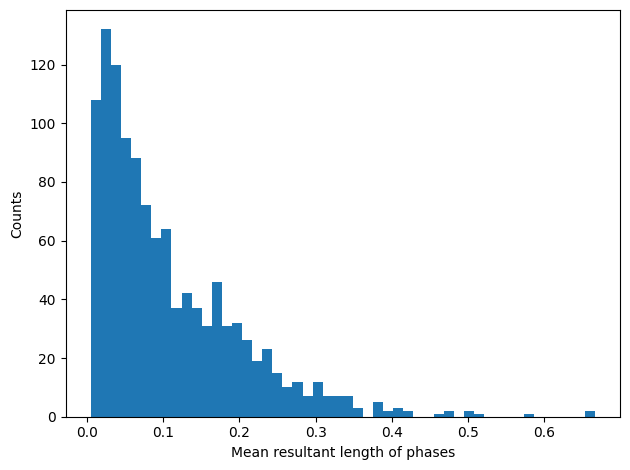

In [ ]:
# ['phasedistros', 'phasebins', 'phasestats', 'spkphases', 'detectorName', 'detectorParams']
phase_distribution = phase_locking['phasedistros']
phase_states = phase_locking['phasestats']
spike_phases = phase_locking['spkphases']

# phase_states.keys ['m', 'mode', 'k', 'p', 'r']
# plt.xlim([-0.02,1.02])
mask = phase_states['p'] < 0.05
plt.hist(phase_states['r'][mask], bins=50);
plt.ylabel("Counts")
plt.xlabel("Mean resultant length of phases")
plt.tight_layout()
plt.show();